In [160]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pathlib
import glob
import scipy.optimize as spt
import tqdm 

In [161]:
plt.style.use('default')
plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.serif"] = "Times New Roman"

# Parameter changes

## Constant amplitude forcing

In [1]:
# In our case, 1024 nn_o = 2
nu_o = 3.125e-8
kf = 36
f0 = 16
nu_1 = nu_o**(1/2) * (f0*kf)**(1/4)
print(nu_1)

0.0008660254037844386


In [3]:
f0 = 4
kf = 9
nu = 2.0e-6
nn = 2
print('knu_old',((f0 * kf)**(1/2) / nu)**(1/(2*nn)))

knu_old 41.61791450287817


In [4]:
print(4**(-2*nn)*nu)

7.8125e-09


In [348]:
# Constant amplitude, constant nn,mm
# Injection rate ~ 1 for 256
a = 72/24. # Factor from 256
n = 256
kf = 24
f01 = 5.3 # f0 at 256
nu1 = 2e-6 # nu at 256
nn = 2
hnu1 = 0.25 # hnu at 256
mm = 1

print('n = ',a*n,'kf= ',a*kf,'fp = ',a*f01,'nu = ', a**(1-2*nn)*nu1,'hnu = ',a**(1/3)*hnu1)

n =  768.0 kf=  72.0 fp =  15.899999999999999 nu =  7.407407407407407e-08 hnu =  0.3605623925768521


In [343]:
# Going from mm = 2 to mm = 1, but keeping k_l the same.
# (eps^(1/3)/hnu)^(2mm+2/3) = (eps^(1/3)/hnu)^(2mm+2/3)
# (eps^(1/3)/hnuo)^(14/3) = (eps^(1/3)/hnun)^(8/3)
# eps**(14/9) hnuo**(-14/3) = eps**(8/9) hnun**(-8/3)
# eps**(-14/9) hnuo**(14/3) = eps**(-8/9) hnun**(8/3)
# (eps**(-6/9) hnuo**(14/3))**(3/8)
f0o = 32
kf = 72
eps = np.sqrt(f0o/kf)**3*kf 
hnuo= 0.85
mmo = 2
mmn = 1
hnun = (eps**(-2/3.)*hnuo**(14./3))**(3./8.)
print(hnun)

0.3501212257106105


In [86]:
# Going from n = 1024 to n = 256 by changing nn
# We want to make ell_nu around 85
# nu*knu**(2n-1) = u(knu) = (kf^2 eps)^(1/3)/knu
# nu*knu**2n = (kf^2 eps)^(1/3)
# So, nuo*knuo**(2*nno) = nun*knun**(2*nnn)
knuo = 256//3#1024//3
knun = 256//3#256//3
nno = 2
nuo = 3.125e-8
nnn = 1

nun = nuo*knuo**(2*nno)/(knun**(2*nnn))

print(nun)

0.00022578125


In [349]:
## Lowering f0 but keeping same Re
f0o = 32
kf = 72
f0n = 9
nuo = 2.4414e-33
nn = 8
ufo = np.sqrt(f0o/kf)
# kf**(1/2-2*nn)* f0o**(1/2) / nuo
print(nuo * np.sqrt(f0n/f0o))

1.2947478716916277e-33


## Constant injection rate

In [64]:
# Going from mm=2 to mm=1, but keeping k_l the same
# (eps^(1/3)/hnu)^(14/3) = (eps_n^(1/3)/hnu_n)^(8/3)
# (eps^(1/3)/hnu)^(2) = eps_n^(1/3)/hnu_n
# In this case, we keep everything the same except mm. So: 
# hnu_n = eps^(-1/3) * hnu**(2)
print(0.5**(-1/3.)*0.5**2)

0.3149802624737183


In [26]:
# Constant injection rate
# Based on Z. Xiao, M. Wan, S. Chen and G. L. Eyink 2009;  Run 2
n = 512*3/2
a = 0.5 # Factor of change 
kf = 150
f01 = 0.006 # f0 = inj rate at 256
nu1 = 2.821e-36
nn = 8
hnu1 = 33.316
mm = 4

print('n = ',a*n,'kf= ',a*kf,'fp = ',a*f01,'nu = ', a**(1-2*nn)*nu1,'hnu = ',a**(1/3)*hnu1)

n =  384.0 kf=  75.0 fp =  0.003 nu =  9.2438528e-32 hnu =  26.44292672368627


In [27]:
# Constant injection rate
n = 256
a = 4 # Factor of change 
kf = 9
f01 = 1.0 # f0 = inj rate at 256
nu1 = 2.e-6
nn = 2
hnu1 = 0.5
mm = 2

print('n = ',a*n,'kf= ',a*kf,'fp = ',a*f01,'nu = ', a**(1-2*nn)*nu1,'hnu = ',a**(1/3)*hnu1)

n =  1024 kf=  36 fp =  4.0 nu =  3.125e-08 hnu =  0.7937005259840997


In [ ]:
# Going from mm=2 to mm=1, but keeping k_l the same
# (eps^(1/3)/hnu)^(14/3) = (eps_n^(1/3)/hnu_n)^(8/3)
# (eps^(1/3)/hnu)^(2) = eps_n^(1/3)/hnu_n

# One triad + neighbors (synchronization)
* Generate a small collection of triads: choose one triad that you know looks 'bad' in the vortex dominated one, and then choose like 25/50 neighbors at random? Sharing legs with k, p, and q?
* Output time series of theta for each (can be at thstep=200) and plot joint PDFs!

In [31]:
# Mother triad:
kx_m,ky_m = [1.0,5.0]
px_m,py_m = [9.0,2.0]
qx_m,qy_m = [-10.0,-7.0]

In [104]:
mult = 1
n = 256*mult
kf = 36*mult
kup = kf+1
kdn = kf-1

kmax = kdn
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []

# First add mother triad:
k_vecs.append([kx_m,ky_m])
p_vecs.append([px_m,py_m])
q_vecs.append([qx_m,qy_m])
Ks.append(np.sqrt(kx_m**2+ky_m**2))
Ps.append(np.sqrt(px_m**2+py_m**2)) 

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0

print('------------ Mother: k ------------')
######### K
kx = kx_m  # kx
ky = ky_m # ky
kmag = np.sqrt(kx**2 + ky**2)
# Let's do 10 triads for each 'leg'
ii = 0
while ii<10:
# for ii in range(10):
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if qmag>=kmax:
        count_wrong_2 += 1
        print('---- (qx,qy) is outside kmax! ----')
        pass

    if pmag>=kmax:
        count_wrong_3 += 1
        print('---- (px,py) is outside kmax! ----')
        pass
    
    if qmag<pmag:
        count_wrong_4+=1
        print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass
    
    if kmag>=pmag:
        count_wrong_5 += 1
        print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if ([kx,ky] in k_vecs)&([px,py] in p_vecs):
        print('Repeated triad.')
    else:  
        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ii+=1
        
print('------------ Mother: p ------------')
######### P
px = px_m  # px
py = py_m # py
pmag = np.sqrt(px**2 + py**2)
# Let's do 10 triads for each 'leg'
ii = 0
while ii<10:
# for ii in range(10):
    ##################
    ## Choose a random vector k, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    # want to be away from hypodiss range
    mag_k = np.random.uniform(low=5,high=pmag)
    # Intersection of P < Q line and pmag circle
    theta_PQ_pos = + (np.pi - np.arccos(mag_k/(2*pmag)))
    theta_PQ_neg = - (np.pi - np.arccos(mag_k/(2*pmag)))
    if (kmax**2-pmag**2-mag_k**2)/(2*pmag*mag_k)<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and pmag circle
        theta_kmax_pos = np.arccos((kmax**2-pmag**2-mag_k**2)/(2*pmag*mag_k))
        theta_kmax_neg = -np.arccos((kmax**2-pmag**2-mag_k**2)/(2*pmag*mag_k))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_k = np.angle(px+1j*py) - np.random.uniform(low=low,high=high) 
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    kmag = np.sqrt(kx**2+ky**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if qmag>=kmax:
        count_wrong_2 += 1
        print('---- (qx,qy) is outside kmax! ----')
        pass

    if pmag>=kmax:
        count_wrong_3 += 1
        print('---- (px,py) is outside kmax! ----')
        pass
    
    if qmag<pmag:
        count_wrong_4+=1
        print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass
    
    if kmag>=pmag:
        count_wrong_5 += 1
        print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if ([kx,ky] in k_vecs)&([px,py] in p_vecs):
        print('Repeated triad.')
    else:  
        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ii+=1

print('------------ Mother: q ------------')
######### Q
qx = qx_m  # qx
qy = qy_m # qy
qmag = np.sqrt(qx**2 + qy**2)
# Let's do 10 triads for each 'leg'
ii = 0
while ii<10:
# for ii in range(10):
    ##################
    ## Choose first vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi  # for now, don't choose half-plane.
    # Random magnitude
    mag_k = np.random.randint(5,qmag)
    kx_tmp = np.round(mag_k*np.cos(theta_k))  # kx
    ky_tmp = np.round(mag_k*np.sin(theta_k)) # ky
    kmag_tmp = np.sqrt(kx_tmp**2 + ky_tmp**2)

    # Define p
    px_tmp = -kx_tmp-qx
    py_tmp = -ky_tmp-qy
    pmag_tmp = np.sqrt(px_tmp**2 + py_tmp**2)

    # Now do the 'ordering'
    if pmag_tmp<kmag_tmp:
        kx = px_tmp
        ky = py_tmp
        kmag = pmag_tmp
        px = kx_tmp
        py = ky_tmp
        pmag = kmag_tmp
    else:
        kx = kx_tmp
        ky = ky_tmp
        kmag = kmag_tmp
        px = px_tmp
        py = py_tmp
        pmag = pmag_tmp
    

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if qmag>=kmax:
        count_wrong_2 += 1
        print('---- (qx,qy) is outside kmax! ----')
        pass

    if pmag>=kmax:
        count_wrong_3 += 1
        print('---- (px,py) is outside kmax! ----')
        pass
    
    if qmag<pmag:
        count_wrong_4+=1
        print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass
    
    if kmag>=pmag:
        count_wrong_5 += 1
        print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        pass

    if ([kx,ky] in k_vecs)&([px,py] in p_vecs):
        print('Repeated triad.')
    else:  
        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ii+=1

# # if 1:
#     kt = np.arange(-kmax_int,kmax_int)
#     kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
#     # kt = np.linspace(-kmax,kmax,200)
#     KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
#     KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
#     cond1 = ((KTX**2 + KTY**2) > kmag**2)
#     if kx==0:
#         if ky>0:
#             cond2 = (KTY > -ky/2)
#         else:
#             cond2 = (KTY < -ky/2)
#     else:
#         cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
#     cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
#     QX = -kx - KTX
#     QY = -ky - KTY
#     # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
#     cond4 = ((QX**2 + QY**2) < kmax**2)
#     plt.figure(figsize=(8,6))
#     plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
#     xplt = np.linspace(-kmax,kmax,1000)
#     if kx == 0:
#             plt.axhline(y = -ky/2)
#     else:
#         plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
#     plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
#     plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
#     plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
#     plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
#     # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
#     # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
#     # plt.axvline(x = -kmax-kx,ls='-',c='c')
#     # plt.axvline(x = kmax-kx,ls='-',c='c')
#     # plt.axhline(y = kmax-ky,ls='-',c='c')
#     # plt.axhline(y = -kmax-ky,ls='-',c='c')
#     a = 1
#     b = 2*kx
#     c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
#     solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
#     soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
#     plt.plot(solp,xplt,'-c')
#     plt.plot(soln,xplt,'-c')
#     # plt.axhline(y = minp+1,ls='--',c='y')
#     # plt.axhline(y = maxp-1,ls='--',c='y')
#     # plt.axvline(x = minp2+1,ls='--',c='orange')
#     # plt.axvline(x = maxp2,ls='--',c='orange')
#     # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
#     V = np.array([[kx,ky],[px,py],[qx,qy]])
#     origin = np.array([[0,0,0],[0,0,0]]) # origin point
#     plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
#     plt.grid()
#     plt.gca().set_aspect(1)
#     plt.xlim(-kmax-1,kmax+1)
#     plt.ylim(-kmax-1,kmax+1)
#     # plt.xlim(px-5,px+5)
#     # plt.ylim(py-5,py+5)
#     plt.show()    

------------ Mother: k ------------
---- (qx,qy) is outside kmax! ----
------------ Mother: p ------------
------------ Mother: q ------------
------qmag<pmag
------qmag<pmag
------qmag<pmag
------qmag<pmag
------qmag<pmag
------qmag<pmag
------qmag<pmag
------qmag<pmag
Repeated triad.
------qmag<pmag


In [105]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [106]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(31, 4)


In [107]:
triads_combined

array([[  1.,   5.,   9.,   2.],
       [  1.,   5.,  -2.,  30.],
       [  1.,   5.,  33.,  -9.],
       [  1.,   5.,  28.,  10.],
       [  1.,   5.,  -3.,   5.],
       [  1.,   5., -12.,   7.],
       [  1.,   5.,  25.,   6.],
       [  1.,   5., -18.,   5.],
       [  1.,   5.,   2.,   9.],
       [  1.,   5., -11.,  20.],
       [  1.,   5.,  -7.,   2.],
       [  6.,  -2.,   9.,   2.],
       [  6.,  -6.,   9.,   2.],
       [  2.,   7.,   9.,   2.],
       [  5.,  -2.,   9.,   2.],
       [ -0.,   6.,   9.,   2.],
       [  2.,  -6.,   9.,   2.],
       [ -4.,   8.,   9.,   2.],
       [  5.,   2.,   9.,   2.],
       [  5.,  -4.,   9.,   2.],
       [  6.,   5.,   9.,   2.],
       [ -4.,   7.,  14.,   0.],
       [ -4.,  10.,  14.,  -3.],
       [  2., -11.,   8.,  18.],
       [  7.,  -8.,   3.,  15.],
       [  3.,  -4.,   7.,  11.],
       [ -9.,  -1.,  19.,   8.],
       [ -8.,  -6.,  18.,  13.],
       [  2.,   2.,   8.,   5.],
       [ -9.,   2.,  19.,   5.],
       [  

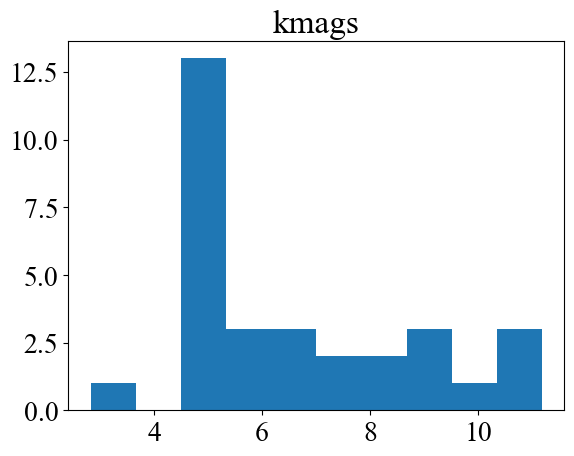

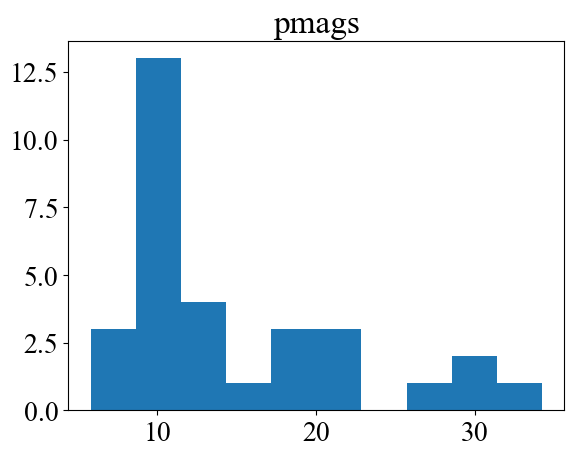

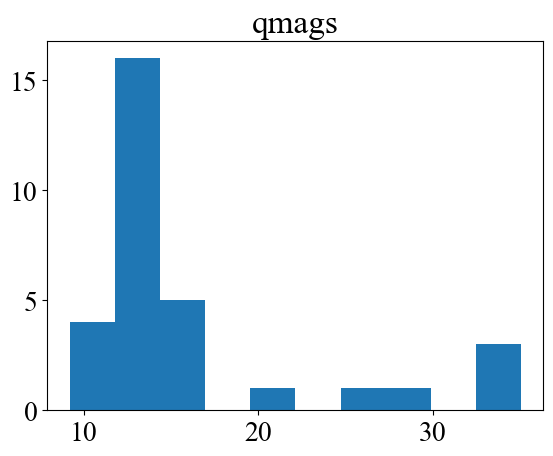

In [108]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

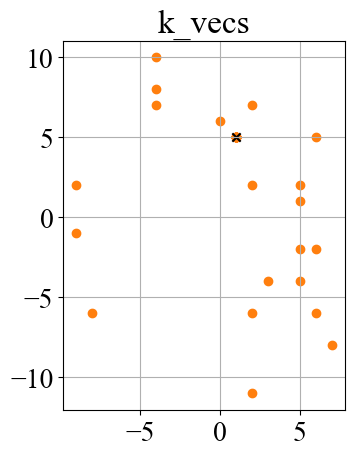

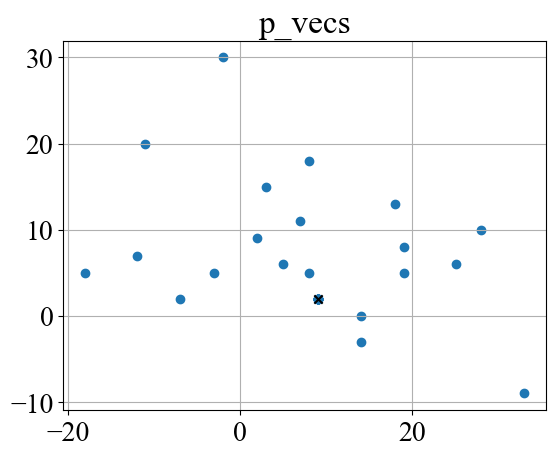

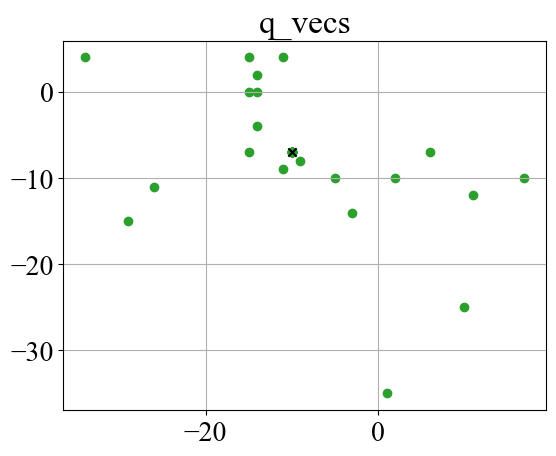

In [109]:
plt.figure()
plt.title('k_vecs')
for triad in triads_combined:
    plt.scatter(triad[0],triad[1],color='tab:orange')
plt.scatter(kx_m,ky_m,color='k',marker='x')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('p_vecs')
for triad in triads_combined:
    plt.scatter(triad[2],triad[3],color='tab:blue')
plt.scatter(px_m,py_m,color='k',marker='x')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('q_vecs')
for triad in triads_combined:
    plt.scatter(-triad[0]-triad[2],-triad[1]-triad[3],color='tab:green')
plt.scatter(qx_m,qy_m,color='k',marker='x')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [110]:
np.savetxt('./triad_lists/full/triads_ts_%i_legs.txt' % n, triads_combined, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

# Fixed triads, PRL (no scaling)
Generate two sets of triads, one for each inertial range.

In [15]:
phase_only=False

### Inverse cascade range

n = 512, kmax = 23


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 5732.47it/s]
/tmp/ipykernel_3451/3225371625.py:167: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_3451/3225371625.py:168: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


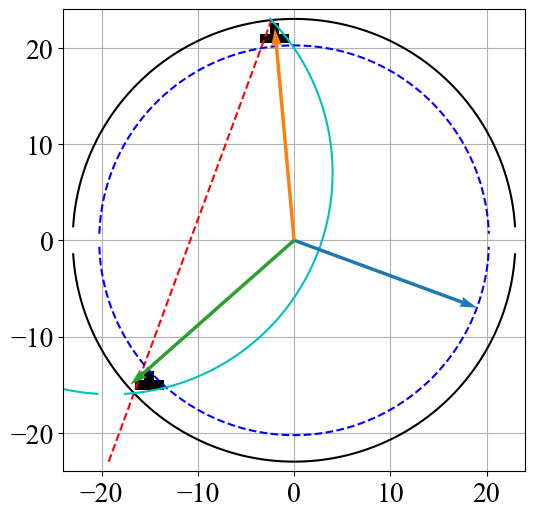

In [16]:
mult = 2
n = 256*mult
Ntriads = 5000 # We don't need _all_ triads. Want to end up with roughly 2000.
if phase_only:
    kmax = n//3
else:
    kmax = 12*mult-1
print('n = %i, kmax = %i' % (n,kmax))

#############################
kmax_int = np.int32(np.floor(kmax))
# Choose K_min. K_min = 1 if to be used for phase_only, and K_min = 3 for full models (avoiding hypodissipation range)
K_min = 3
# Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
K_lim = kmax_int #int(np.round(kmax/2)) # using /8 for phase only, /4 in full model?
P_lim = kmax_int #int(np.round(kmax/2))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    mag_k = np.random.randint(K_min,K_lim)
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=kmax:
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=kmax:
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    # term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    # term.append(term_tmp)
    Ks.append(kmag)
    Ps.append(pmag) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [317]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [318]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(4191, 4)


In [319]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(3964, 4)


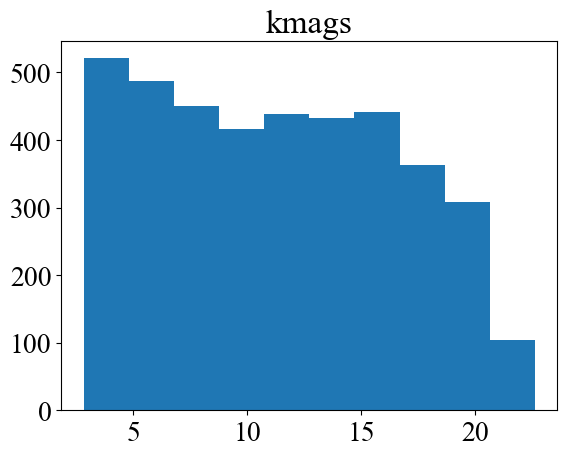

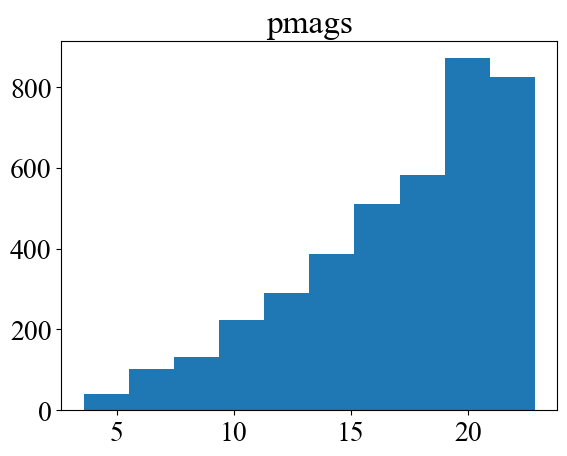

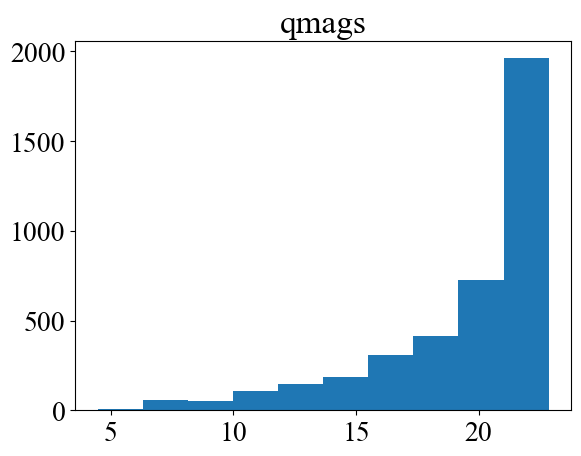

In [320]:
# Check sizes
Ks = []
Ps = []
Qs = []
for triad_tmp in triads_unique:
    kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
    pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
    qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
    Ks.append(kmag)
    Ps.append(pmag)
    Qs.append(qmag)


plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

plt.title('qmags')
plt.hist(Qs)
plt.show()


### Forward Enstrophy cascade range

n = 512, kmax = 90


100%|█████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 5946.90it/s]
/tmp/ipykernel_21889/271442832.py:164: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_21889/271442832.py:165: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


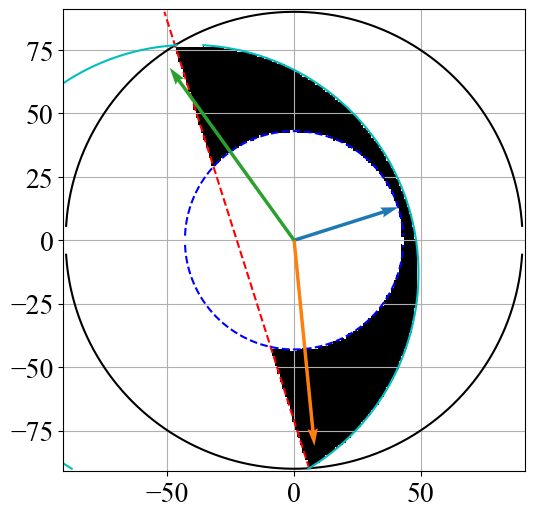

In [321]:
# mult = 1
# n = 256*mult
# Ntriads = 5000 # We don't need _all_ triads. Want to end up with roughly 2000.
kmax = 45*mult #60*mult
print('n = %i, kmax = %i' % (n,kmax))
# Choose K_min. K_min = 1 if to be used for phase_only, and K_min = 3 for full models (avoiding hypodissipation range)
K_min = 12*mult+1

#############################
kmax_int = np.int32(np.floor(kmax))
# Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
K_lim = kmax_int #int(np.round(kmax/2)) # using /8 for phase only, /4 in full model?
P_lim = kmax_int #int(np.round(kmax/2))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    mag_k = np.random.randint(K_min,K_lim)
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=kmax:
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=kmax:
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    # term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    # term.append(term_tmp)
    Ks.append(kmag)
    Ps.append(pmag) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [322]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [323]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(4624, 4)


In [324]:
# ADD TO PREVIOUS
triads_unique = np.vstack([triads_unique,np.unique(triads_combined,axis=0)])
print(triads_unique.shape)

(8585, 4)


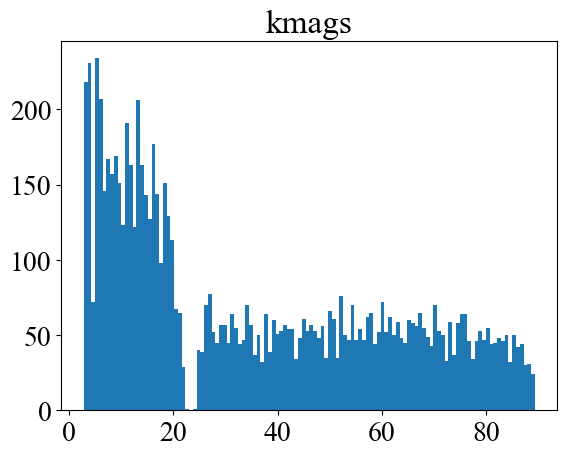

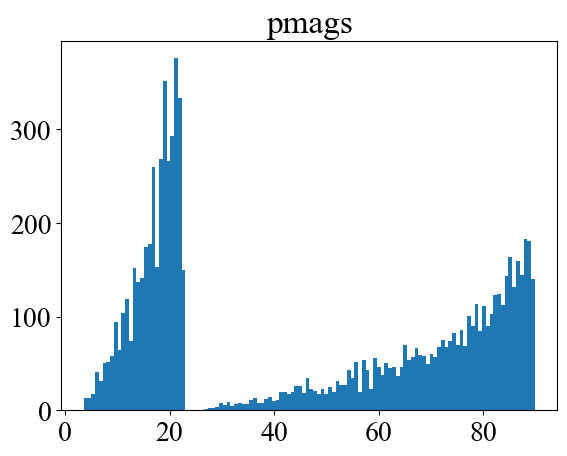

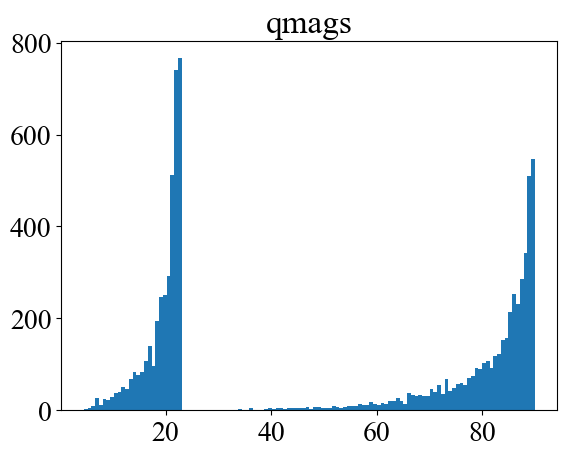

In [325]:
# Check sizes
Ks = []
Ps = []
Qs = []
for triad_tmp in triads_unique:
    kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
    pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
    qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
    Ks.append(kmag)
    Ps.append(pmag)
    Qs.append(qmag)


plt.title('kmags')
plt.hist(Ks,bins=120)
plt.show()

plt.title('pmags')
plt.hist(Ps,bins=120)
plt.show()

plt.title('qmags')
plt.hist(Qs,bins=120)
plt.show()


In [326]:
np.savetxt('./triad_lists/full/triads_%i_PRL_nn2mm1.txt' % n, triads_unique, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

### Picking for time-series sampling

In [17]:
phase_only = False

Inverse cascade

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 1278.04it/s]
/tmp/ipykernel_3451/3963676827.py:172: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_3451/3963676827.py:173: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


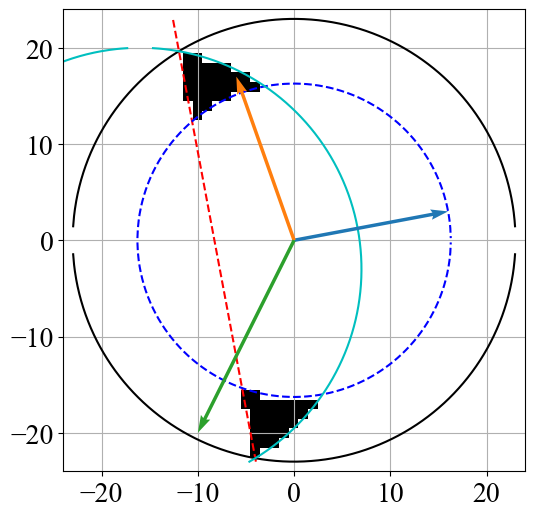

In [18]:
N_shells = 6 # Based on the number of shells we're interested in sampling (will look at 4 random triads per shell)
mult = 2
n = 256*mult
if not phase_only:
    kf = 12*mult
else:
    kf = n//3 # phase only
kup = kf+1
kdn = kf-1
kmax = kf-1
kmax_int = np.int32(np.floor(kmax))
K_min = 3

Kbins = np.logspace(np.log10(K_min),np.log10(kmax),N_shells)
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for shell in tqdm.tqdm(range(N_shells)):
    ntriad = 0
    while ntriad<4:
        count+=1
        ##################
        ## Choose k vector
        # Random theta
        theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
        # Random magnitude
        # Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
        K_lim = np.min([kmax,Kbins[shell]])
        if shell>0:
            # K_min = np.max([0.5,Kbins[shell-1]]) # for phase
            K_min = np.max([5,Kbins[shell-1]])
        else:
            K_min = 5
        # mag_k = np.random.randint(K_min,K_lim)
        mag_k = np.random.uniform(K_min,K_lim) # So at least one shell is represented for the last K
        kx = np.round(mag_k*np.cos(theta_k))  # kx
        ky = np.round(mag_k*np.sin(theta_k)) # ky
        kmag = np.sqrt(kx**2 + ky**2)
        
        ##################
        ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
        ########
        rad_lim = np.min([kmax,P_lim])
        # Choose a random radius between kmag and rad_lim
        mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
        # Intersection of P < Q line and mag_p circle
        theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
        theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
        if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
            # Intersection of Q < kmax curve and mag_p circle
            theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            pos = np.random.randint(0,high = 2) # Choose a branch
            if pos==0: # neg
                low = theta_PQ_neg
                high = theta_kmax_neg
            else: # pos
                low=theta_kmax_pos
                high=theta_PQ_pos
        else:
            low=theta_PQ_neg
            high=theta_PQ_pos
        # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
        theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
        px = np.round(mag_p*np.cos(theta_p))  # px
        py = np.round(mag_p*np.sin(theta_p)) # py
        
        ####### Check and correct for discreteness effects
        # count_e = 1
        # good = False
        # while not good:
        #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
        #     count_e += 1
        pmag = np.sqrt(px**2+py**2)
        # Finally, find qx,qy
        qx = -kx -px
        qy = -ky -py
        qmag = np.sqrt(qx**2 + qy**2)
    
        cross = (kx*py)-(ky*px)
        if cross==0:
            count_wrong_1 += 1
            # print('------cross = 0')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
    
        if qmag>=(n/3):
            count_wrong_2 += 1
            print('---- (qx,qy) is outside the dealiased grid! ----')
            continue
    
        if pmag>=(n/3):
            count_wrong_3 += 1
            # print('---- (px,py) is outside the dealiased grid! ----')
            continue
        
        if qmag<pmag:
            count_wrong_4+=1
            # print('------qmag<pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
        
        if kmag>=pmag:
            count_wrong_5 += 1
            # print('------ kmag = pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue

        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ntriad += 1
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [19]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [20]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(24, 4)


In [21]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(24, 4)


Forward cascade

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 957.24it/s]
/tmp/ipykernel_3451/754757168.py:172: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_3451/754757168.py:173: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


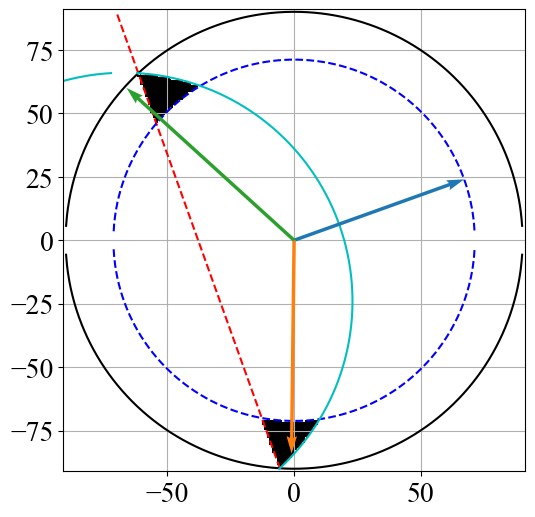

In [22]:
# # N_shells = 6 # Based on the number of shells we're interested in sampling (will look at 4 random triads per shell)
# # mult = 1
# # n = 256*mult
# if not phase_only:
#     kf = 12*mult
# else:
#     kf = n//3 # phase only
# kup = kf+1
# kdn = kf-1
K_min = kf+1
kmax = 45*mult #60*mult
kmax_int = np.int32(np.floor(kmax))

Kbins = np.logspace(np.log10(K_min),np.log10(kmax),N_shells)
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for shell in tqdm.tqdm(range(N_shells)):
    ntriad = 0
    while ntriad<4:
        count+=1
        ##################
        ## Choose k vector
        # Random theta
        theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
        # Random magnitude
        # Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
        K_lim = np.min([kmax,Kbins[shell]])
        if shell>0:
            # K_min = np.max([0.5,Kbins[shell-1]]) # for phase
            K_min = np.max([5,Kbins[shell-1]])
        else:
            K_min = 5
        # mag_k = np.random.randint(K_min,K_lim)
        mag_k = np.random.uniform(K_min,K_lim) # So at least one shell is represented for the last K
        kx = np.round(mag_k*np.cos(theta_k))  # kx
        ky = np.round(mag_k*np.sin(theta_k)) # ky
        kmag = np.sqrt(kx**2 + ky**2)
        
        ##################
        ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
        ########
        rad_lim = np.min([kmax,P_lim])
        # Choose a random radius between kmag and rad_lim
        mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
        # Intersection of P < Q line and mag_p circle
        theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
        theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
        if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
            # Intersection of Q < kmax curve and mag_p circle
            theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            pos = np.random.randint(0,high = 2) # Choose a branch
            if pos==0: # neg
                low = theta_PQ_neg
                high = theta_kmax_neg
            else: # pos
                low=theta_kmax_pos
                high=theta_PQ_pos
        else:
            low=theta_PQ_neg
            high=theta_PQ_pos
        # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
        theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
        px = np.round(mag_p*np.cos(theta_p))  # px
        py = np.round(mag_p*np.sin(theta_p)) # py
        
        ####### Check and correct for discreteness effects
        # count_e = 1
        # good = False
        # while not good:
        #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
        #     count_e += 1
        pmag = np.sqrt(px**2+py**2)
        # Finally, find qx,qy
        qx = -kx -px
        qy = -ky -py
        qmag = np.sqrt(qx**2 + qy**2)
    
        cross = (kx*py)-(ky*px)
        if cross==0:
            count_wrong_1 += 1
            # print('------cross = 0')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
    
        if qmag>=(n/3):
            count_wrong_2 += 1
            print('---- (qx,qy) is outside the dealiased grid! ----')
            continue
    
        if pmag>=(n/3):
            count_wrong_3 += 1
            # print('---- (px,py) is outside the dealiased grid! ----')
            continue
        
        if qmag<pmag:
            count_wrong_4+=1
            # print('------qmag<pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
        
        if kmag>=pmag:
            count_wrong_5 += 1
            # print('------ kmag = pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue

        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ntriad += 1
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [23]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [24]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(24, 4)


In [25]:
triads_unique = np.vstack([triads_unique,np.unique(triads_combined,axis=0)])
print(triads_unique.shape)

(48, 4)


In [26]:
triads_unique

array([[  0.,   3.,  -9.,   3.],
       [  0.,   3.,   7.,  12.],
       [  1.,  17., -19.,  -4.],
       [  2.,   4.,  14.,  -1.],
       [  2.,  20., -20.,  -7.],
       [  3.,   5., -18.,  12.],
       [  4.,   0.,   4.,   2.],
       [  4.,   1.,   6.,  18.],
       [  4.,   3.,  -5.,  13.],
       [  4.,   8., -13.,  12.],
       [  5.,   1.,   3., -12.],
       [  5.,   1.,   7.,  -2.],
       [  5.,   1.,  10.,   8.],
       [  5.,   2.,  -8.,  18.],
       [  5.,  11., -21.,   4.],
       [  6.,   1.,   7.,  -5.],
       [  6.,   4.,   9., -10.],
       [  6.,   5.,  16.,  -9.],
       [  6.,   7.,   6.,   8.],
       [ 11.,   7.,  -8.,  14.],
       [ 11.,   7.,  -8.,  15.],
       [ 12.,   7., -14.,  13.],
       [ 15.,  11., -17.,  10.],
       [ 16.,   3.,  -6.,  17.],
       [  1.,  10., -20.,   5.],
       [  4.,  13., -79.,  33.],
       [  7.,  25., -58.,   7.],
       [  7.,  56.,  58., -13.],
       [  8.,  18.,  33.,  22.],
       [ 14.,  43., -88.,   6.],
       [ 1

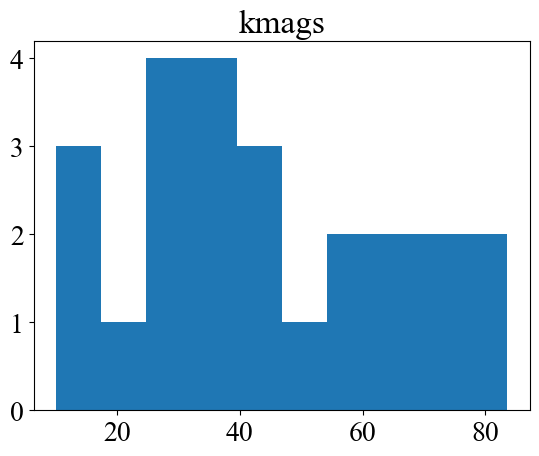

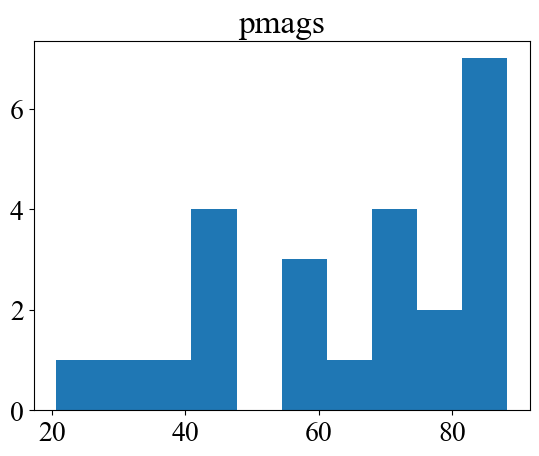

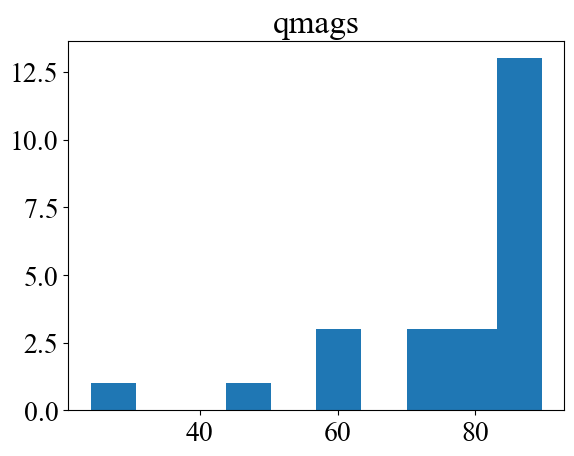

In [27]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

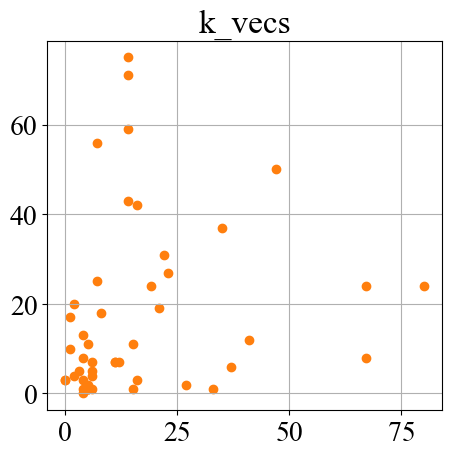

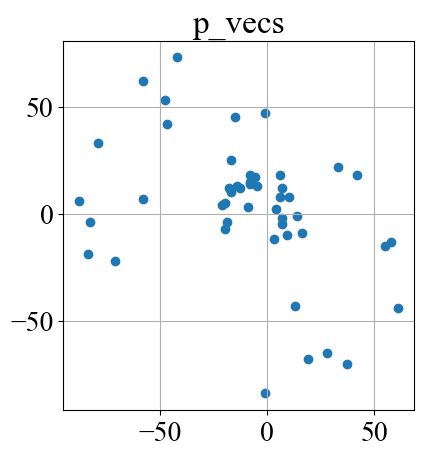

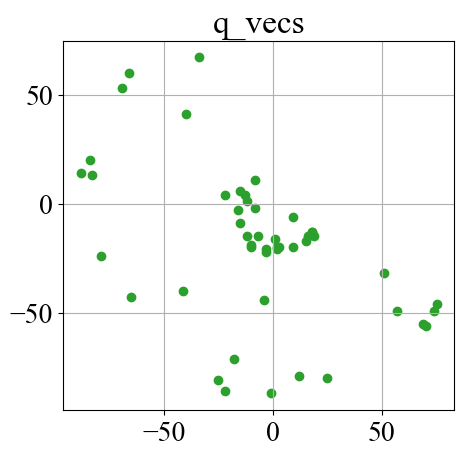

In [28]:
plt.figure()
plt.title('k_vecs')
for triad in triads_unique:
    plt.scatter(triad[0],triad[1],color='tab:orange')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('p_vecs')
for triad in triads_unique:
    plt.scatter(triad[2],triad[3],color='tab:blue')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('q_vecs')
for triad in triads_unique:
    plt.scatter(-triad[0]-triad[2],-triad[1]-triad[3],color='tab:green')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [30]:
# np.savetxt('./triad_lists/full/triads_ts_%i_PRL.txt' % n, triads_unique, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

# Fixed triads (for scaling)
First generate 'mother' list of triads within $5 < k_f < 10$, so that we choose large-scale triads, but are away from the dissipation range.

These will later be scaled for larger domain runs.

In [162]:
phase_only = False

n = 512, kmax = 124


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:17<00:00, 5800.20it/s]
/tmp/ipykernel_3451/1915971198.py:168: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_3451/1915971198.py:169: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


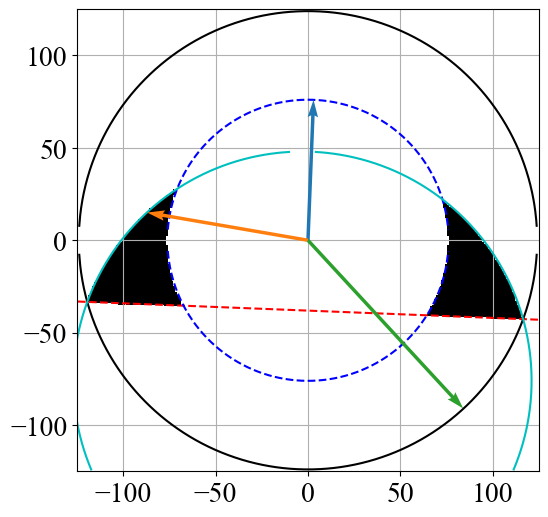

In [164]:
mult = 2
n = 256*mult
Ntriads = 100000
if phase_only:
    kmax = n//3
else:
    # kmax = 12*mult # mid-range
    kmax = 62*mult # small-scale (Mizuta)
print('n = %i, kmax = %i' % (n,kmax))

#############################
kmax_int = np.int32(np.floor(kmax))
# Choose K_min. K_min = 1 if to be used for phase_only, and K_min = 4 for full models (avoiding hypodissipation range)
K_min = 4
# Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
K_lim = kmax_int #int(np.round(kmax/2)) # using /8 for phase only, /4 in full model?
P_lim = kmax_int #int(np.round(kmax/2))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    mag_k = np.random.randint(K_min,K_lim)
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=kmax:
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=kmax:
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    # term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    # term.append(term_tmp)
    Ks.append(kmag)
    Ps.append(pmag) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [165]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

Create a unique list of triads 
Because many are likely duplicated

In [166]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(95403, 4)


In [167]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(94873, 4)


So there are 786 unique triads that satisfy these conditions. Let's see what their statistics are:

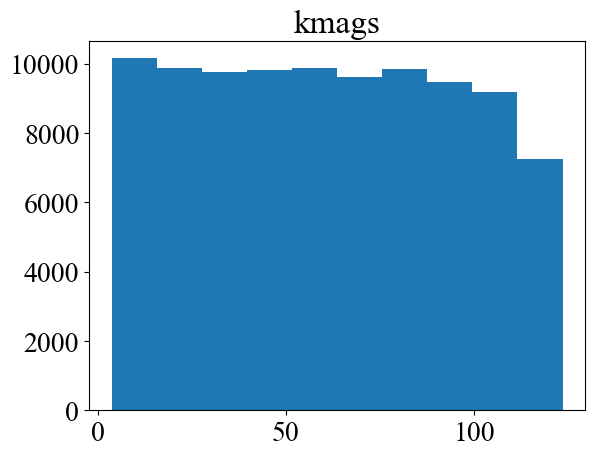

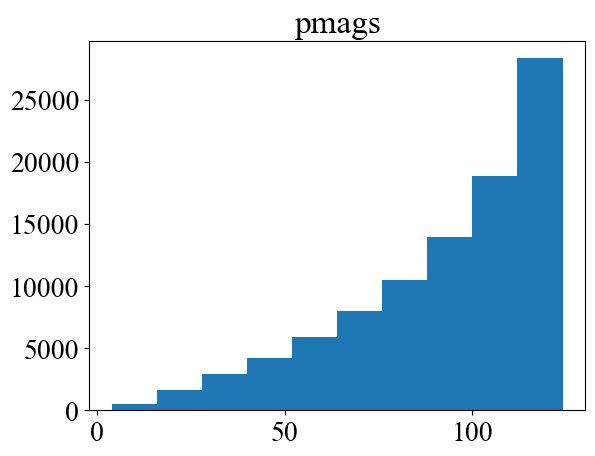

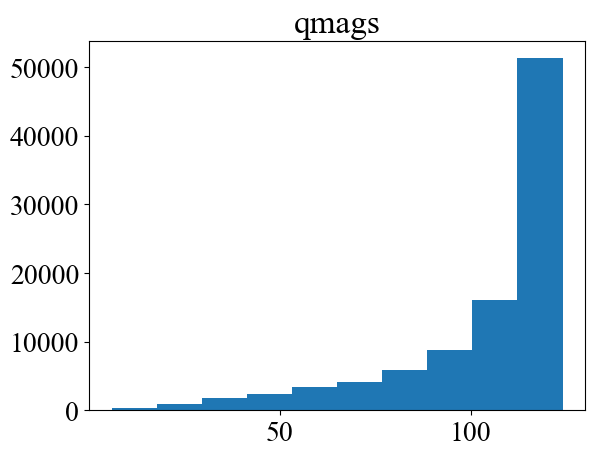

In [168]:
# Check sizes
Ks = []
Ps = []
Qs = []
for triad_tmp in triads_unique:
    kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
    pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
    qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
    Ks.append(kmag)
    Ps.append(pmag)
    Qs.append(qmag)


plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

plt.title('qmags')
plt.hist(Qs)
plt.show()


In [169]:
k_vecs_unique = np.unique(k_vecs,axis=0)
p_vecs_unique = np.unique(p_vecs,axis=0)
q_vecs_unique = np.unique(q_vecs,axis=0)

In [144]:
# plt.figure()
# plt.title('k_vecs')
# for triad in k_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:orange')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('p_vecs')
# for triad in p_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:blue')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('q_vecs')
# for triad in q_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:green')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

## Scaling
Now we apply scaling and creat a new list. This will depend on the size of the target domain.
First we will choose a random subset of triads, because we want to keep the total list at about 500...

In [170]:
inds_triads = np.arange(triads_unique.shape[0])
### OLD GPU NUMBERS
# inds_triads_subset = sorted(np.random.choice(inds_triads,replace=False,size=100)) # Full
# inds_triads_subset = sorted(np.random.choice(inds_triads,replace=False,size=30)) # Phase only
### CPU NUMBERS
inds_triads_subset = inds_triads # Full
# inds_triads_subset = sorted(np.random.choice(inds_triads,replace=False,size=30)) # Phase only

In [171]:
# mult = 1
# n = 256*mult
# if phase_only:
#     kmax = n//3 # Phase only model
# else:
#     kmax = 9*mult # Full model
print('n = %i, kmax = %i' % (n,kmax))

#############################
kmax_int = np.int32(np.floor(kmax))

triads_full = []
as_full = []
count = 1
for triad in triads_unique[inds_triads_subset,:]:
    # The limiting factor will be q, so we first define this
    [qx,qy]=[-triad[0]-triad[2],-triad[1]-triad[3]]
    qmax = np.max([np.abs(qx),np.abs(qy)])
    nums = np.min([8,int(np.floor(kmax/qmax))])
    # ONLY INCLUDE triads whose a>1:
    triad_tmp = triad*3
    kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
    pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
    qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
    if (kmag>kmax) or (pmag>kmax) or (qmag>kmax):
        continue
    else:
        for ii in range(1,nums+1):
            triad_tmp = triad*(ii)
            kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
            pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
            qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
            if (kmag>kmax) or (pmag>kmax) or (qmag>kmax):
                # print("TRIAD IS LARGER THAN KMAX. SKIPPING.")
                # print(triad_tmp, 2**(ii))
                continue
            else:
                triads_full.append(triad*(ii))
                as_full.append(ii)
    # print('-------------')
    # print(qmax)
    # print(nums)
    # print('kx',[kx*2**(ii) for ii in range(nums)])
    # print('ky',[ky*2**(ii) for ii in range(nums)])
    # print('px',[px*2**(ii) for ii in range(nums)])
    # print('py',[py*2**(ii) for ii in range(nums)])
    # print('qx',[qx*2**(ii) for ii in range(nums)])
    # print('qy',[qy*2**(ii) for ii in range(nums)])

triads_full = np.array(triads_full)
as_full = np.array(as_full)

print('Number of random set of "mother" triads: %i' % (triads_unique[inds_triads_subset,:].shape[0]))
print('Number of triads, including scaled: %i' % (triads_full.shape[0]))
print('Max scaling ("a") present in set: %i' % (np.max(as_full)))

n = 512, kmax = 124
Number of random set of "mother" triads: 94873
Number of triads, including scaled: 12098
Max scaling ("a") present in set: 8


[1. 2. 3. 4. 5. 6. 7. 8.] [2990 2990 2990 1422  787  461  286  172]


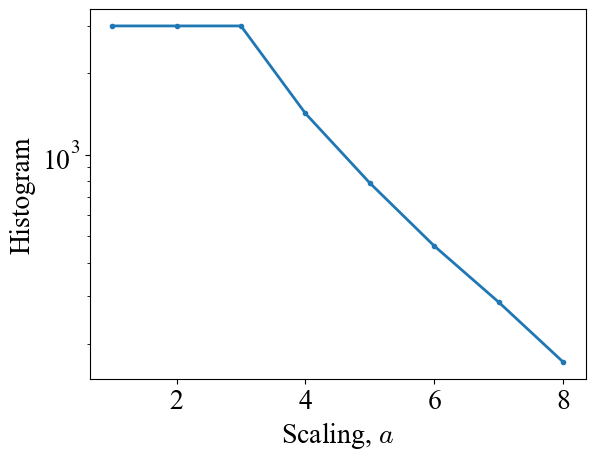

In [172]:
# Histogram
# q = k_vecs[:,0]
q = as_full
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
bins_c = (np.diff(bins)/2+bins[:-1])
# nn[nn==0]=np.nan
print(bins_c[nn!=0],nn[nn!=0])
plt.semilogy(bins_c[nn!=0],nn[nn!=0],'.-',lw=2,)
# plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,10)
plt.ylabel('Histogram')
plt.xlabel('Scaling, $a$')
plt.show()

In [148]:
if phase_only:
    name='phase_only'
else:
    name='full'

In [149]:
np.savetxt('./triad_lists/'+name+'/triads_%i_Mizuta.txt' % n, triads_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

In [150]:
np.savetxt('./triad_lists/'+name+'/as_%i_Mizuta.txt' % n, as_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

### Picking for time-series sampling

In [128]:
phase_only = False

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 1042.97it/s]
/tmp/ipykernel_3451/3946305939.py:174: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_3451/3946305939.py:175: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


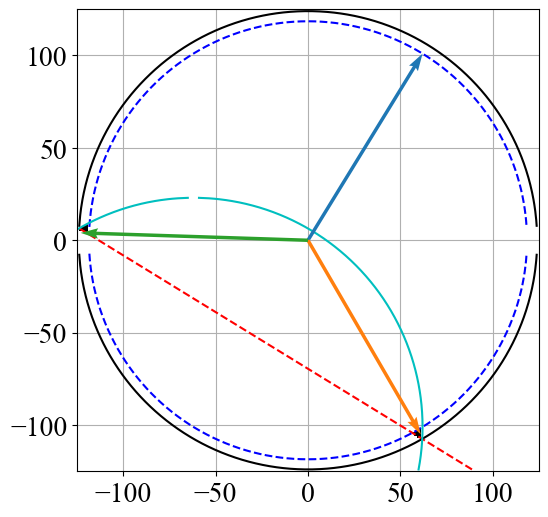

In [151]:
N_shells = 12 # Based on the number of shells we're interested in sampling (will look at 4 random triads per shell)
mult = 2
n = 256*mult
if not phase_only:
    # kf = 9*mult # full
    # kf = 36*mult # drag
    # kf = 75*mult # xiao2009
    kf = 62*mult # Mizuta PRE 2013
else:
    kf = n//3 # phase only
kup = kf+1
kdn = kf-1
kmax = kf #n/3
kmax_int = np.int32(np.floor(kmax))

Kbins = np.logspace(np.log10(6),np.log10(kmax),N_shells)
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for shell in tqdm.tqdm(range(N_shells)):
    ntriad = 0
    while ntriad<4:
        count+=1
        ##################
        ## Choose k vector
        # Random theta
        theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
        # Random magnitude
        # Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
        K_lim = np.min([kmax,Kbins[shell]])
        if shell>0:
            # K_min = np.max([0.5,Kbins[shell-1]]) # for phase
            K_min = np.max([5,Kbins[shell-1]])
        else:
            K_min = 5
        # mag_k = np.random.randint(K_min,K_lim)
        mag_k = np.random.uniform(K_min,K_lim) # So at least one shell is represented for the last K
        kx = np.round(mag_k*np.cos(theta_k))  # kx
        ky = np.round(mag_k*np.sin(theta_k)) # ky
        kmag = np.sqrt(kx**2 + ky**2)
        
        ##################
        ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
        ########
        rad_lim = np.min([kmax,P_lim])
        # Choose a random radius between kmag and rad_lim
        mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
        # Intersection of P < Q line and mag_p circle
        theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
        theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
        if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
            # Intersection of Q < kmax curve and mag_p circle
            theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            pos = np.random.randint(0,high = 2) # Choose a branch
            if pos==0: # neg
                low = theta_PQ_neg
                high = theta_kmax_neg
            else: # pos
                low=theta_kmax_pos
                high=theta_PQ_pos
        else:
            low=theta_PQ_neg
            high=theta_PQ_pos
        # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
        theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
        px = np.round(mag_p*np.cos(theta_p))  # px
        py = np.round(mag_p*np.sin(theta_p)) # py
        
        ####### Check and correct for discreteness effects
        # count_e = 1
        # good = False
        # while not good:
        #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
        #     count_e += 1
        pmag = np.sqrt(px**2+py**2)
        # Finally, find qx,qy
        qx = -kx -px
        qy = -ky -py
        qmag = np.sqrt(qx**2 + qy**2)
    
        cross = (kx*py)-(ky*px)
        if cross==0:
            count_wrong_1 += 1
            # print('------cross = 0')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
    
        if qmag>=(n/3):
            count_wrong_2 += 1
            print('---- (qx,qy) is outside the dealiased grid! ----')
            continue
    
        if pmag>=(n/3):
            count_wrong_3 += 1
            # print('---- (px,py) is outside the dealiased grid! ----')
            continue
        
        if qmag<pmag:
            count_wrong_4+=1
            # print('------qmag<pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
        
        if kmag>=pmag:
            count_wrong_5 += 1
            # print('------ kmag = pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue

        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ntriad += 1
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [152]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [153]:
k_vecs.shape

(48, 2)

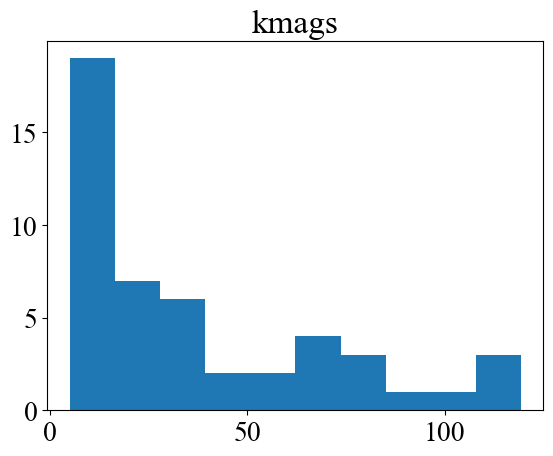

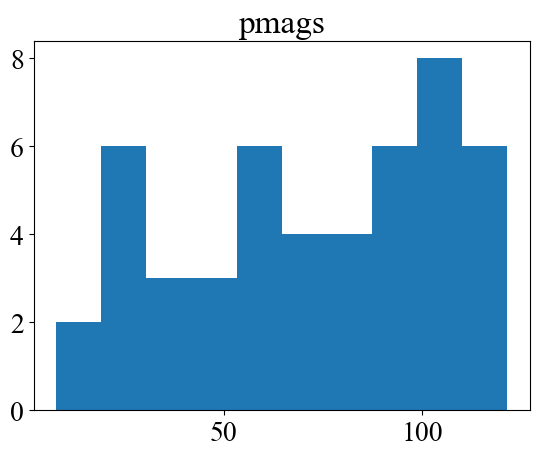

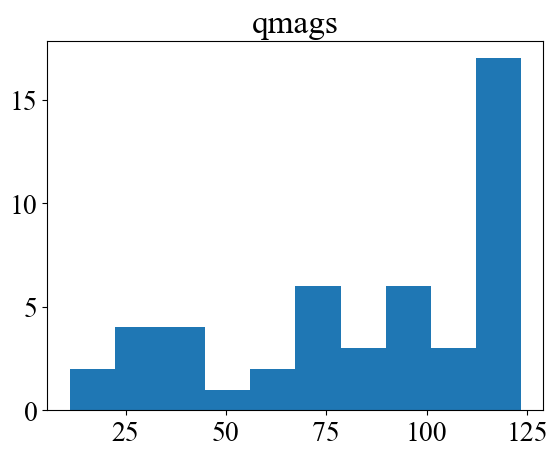

In [154]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

Create a unique list of triads 
Because many are likely duplicated

In [155]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(48, 4)


In [156]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(48, 4)


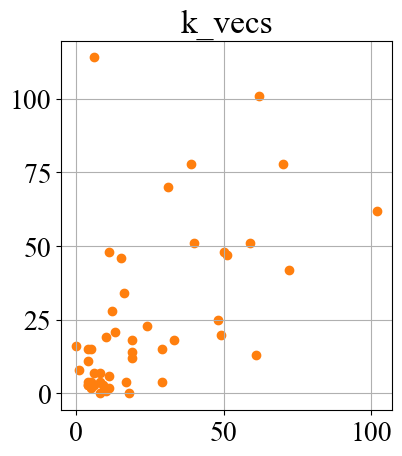

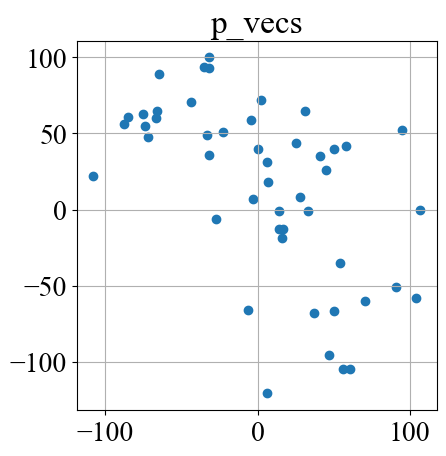

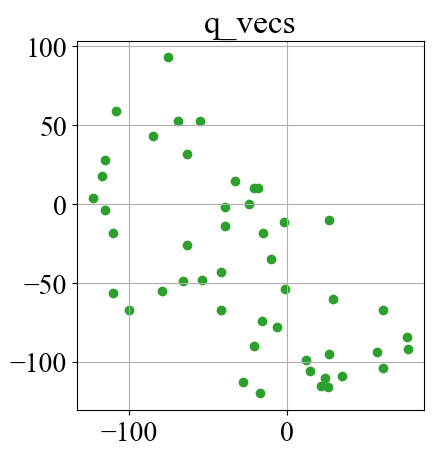

In [157]:
plt.figure()
plt.title('k_vecs')
for triad in triads_unique:
    plt.scatter(triad[0],triad[1],color='tab:orange')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('p_vecs')
for triad in triads_unique:
    plt.scatter(triad[2],triad[3],color='tab:blue')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('q_vecs')
for triad in triads_unique:
    plt.scatter(-triad[0]-triad[2],-triad[1]-triad[3],color='tab:green')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [158]:
if phase_only:
    name='phase_only'
else:
    name='full'

In [159]:
np.savetxt('./triad_lists/'+name+'/triads_ts_%i_Mizuta.txt' % n, triads_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

# Version 1

In [106]:
n = 64
P_max = 4
Ntriads = 1500
perc_wrong = []
unique = []
Ks = []
ks_dict = dict([])
count = 0
for K in range(1,n//2+1):
    print("------------ K = %s" % K)
    P_max_final = np.min([K+P_max,n//2+1])
    print("--- P_max_final = %s" % P_max_final)
    for P in range(K+1,P_max_final+1):
        ks = []
        ps = []
        # count = 0
        count_wrong = 0
        for Ntr in range(1,Ntriads+1):
            ## Choose k vector
            randtest = np.random.uniform(low=-1,high=1)
            theta_k = randtest*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
            kx = np.floor(K*np.cos(theta_k)+0.5)  # kx
            ky = np.floor(K*np.sin(theta_k)+0.5) # ky
            kmag = np.sqrt(kx**2 + ky**2)
            # # Check to see if it's in the right shell (after 'floor' operation)
            # if (K!=int(kmag+0.5)):
            #     print('K,shell',K,int(kmag+0.5))
            #     print('K',kx,ky,K,kmag)
            #     count_wrong +=1
            #     continue
                
            if np.abs(kx)>0:
                theta_k_true = np.arctan(ky/kx)
            else:
                theta_k_true = np.sign(ky)*np.pi/2
            
            #### Choose another random vector p, s.t. |p|~|K|+P and the resulting |q| > |p| > |k| ... 
            # Angle must be chosen so that |q| > |p|: |theta| > theta_c. Translates to |theta_p - theta_k| < Pi - theta_c
            # So that, -Pi + theta_k + theta_c < theta_p < Pi + theta_k - theta_c, where theta_c = acos(K/(2*P)).
            theta_c = np.arccos(kmag/(2*P))
            
            # Next, choose a random angle -Pi + theta_k + theta_c < theta_p < Pi + theta_k - theta_c. 
            lim = (np.pi - theta_c)
            lim = lim -2*np.pi*np.round(lim/np.pi/2) # From [-pi,pi]
            theta_p = np.random.uniform(low=-1,high=1)*lim + theta_k_true
            theta_p = theta_p -2*np.pi*np.round(theta_p/np.pi/2) # From [-pi,pi]
            px = np.floor(P*np.cos(theta_p)+0.5)  # px
            py = np.floor(P*np.sin(theta_p)+0.5) # py

            # If cross product is zero, slightly change vector
            cross = (kx*py)-(ky*px)
            if cross==0:
                if pmag > P:
                    if np.abs(px)>np.abs(py):
                        py -= 1
                    else:
                        px -= 1
                else:
                    if np.abs(px)>np.abs(py):
                        py += 1
                    else:
                        px += 1
                
            # Finally, find qx,qy
            qx = -kx -px
            qy = -ky -py
            qmag = np.sqrt(qx**2 + qy**2)
            pmag = np.sqrt(px**2 + py**2)
            count += 1
            if pmag>qmag:
                # print("!!!!!!!!!!!---------- QMAG  = 0! ----------!!!!!!!!!!!!")
                # theta_c_true = np.arccos((kx*px+ky*py)/(pmag*kmag))
                # if np.abs(px)>0:
                #     theta_p_true = np.arctan(py/px)
                # else:
                #     theta_p_true = np.sign(py)*np.pi/2
                # delta = theta_p_true - theta_k_true
                # delta = delta -2*np.pi*np.round(delta/np.pi/2) # From [-pi,pi]
                # delta_t = np.pi-theta_c_true
                # delta_t = delta_t -2*np.pi*np.round(delta_t/np.pi/2) # From [-pi,pi]
                # print('delta = %.2f, Pi - theta_c = %.2f' % (delta,delta_t))
                # print('K',kx,ky,K,kmag)
                # print('P',px,py,P,pmag)
                # print('Q',qx,qy,np.nan,qmag)
                count_wrong +=1
                # Skips this wavenumber
                continue
                
            # if (Ntr%(Ntriads//100))==0:
            #     theta_c_true = np.arccos((kx*px+ky*py)/(pmag*kmag))
            #     if np.abs(px)>0:
            #         theta_p_true = np.arctan(py/px)
            #     else:
            #         theta_p_true = np.sign(py)*np.pi/2
            #     delta = theta_p_true - theta_k_true
            #     delta = delta -2*np.pi*np.round(delta/np.pi/2) # From [-pi,pi]
            #     delta_t = np.pi-theta_c_true
            #     delta_t = delta_t -2*np.pi*np.round(delta_t/np.pi/2) # From [-pi,pi]
            #     print('ALL GOOD. delta = %.2f, Pi - theta_c = %.2f' % (delta,delta_t))
            # # if 1:
            #     print('thetas_c, theta_c_true',theta_c,theta_c_true)
            #     print('theta_k',theta_k)
            #     print('theta_p',theta_p)
            #     print('K',kx,ky,K,kmag)
            #     print('P',px,py,P,pmag)
            #     print('Q',qx,qy,np.nan,qmag)
            #     plt.figure(figsize=(8,6))
            #     plt.axhline(y=0,c='k',lw=1)
            #     plt.axvline(x=0,c='k',lw=1)
            #     V = np.array([[kx,ky], [px,py], [qx,qy]])
            #     origin = np.array([[0, kx, kx+px],[0, ky, ky+py]]) # origin point
                
            #     plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
            #     plt.grid()
            #     plt.xlim(-qmag,qmag)
            #     plt.ylim(-qmag,qmag)
            #     plt.show()

            ks.append([kx,ky])
            ps.append([px,py])
        print('count_wrong = %s, perc_wrong = %s' % (count_wrong,count_wrong/count*100))

        ks_dict[K] = np.array(ks)

        # print('count wrong = %s, percent wrong = %s' % (count_wrong,count_wrong/Ntriads*100))
        perc_wrong.append(count_wrong/Ntriads*100)
        ks = np.array(ks)
        ps = np.array(ps)
        unique.append(len(np.unique(np.hstack([ks,ps]),axis=0)))
        Ks.append(P)
        # plt.title('K = %s, P = %s' % (K,P))
        # plt.scatter(ks[:,0],ks[:,1],s=15)
        # plt.scatter(ps[:,0],ps[:,1],s=15)
        # xplt = np.linspace(-P,P,1000)
        # plt.plot(xplt, np.sqrt(P**2-xplt**2),'--',c='tab:orange')
        # plt.plot(xplt,-np.sqrt(P**2-xplt**2),'--',c='tab:orange')
        # xplt = np.linspace(-K,K,1000)
        # plt.plot(xplt, np.sqrt(K**2-xplt**2),'--',c='tab:blue')
        # plt.plot(xplt,-np.sqrt(K**2-xplt**2),'--',c='tab:blue')
        # plt.grid()
        # plt.gca().set_aspect(1)
        # plt.show()

------------ K = 1
--- P_max_final = 5
count_wrong = 0, perc_wrong = 0.0
count_wrong = 0, perc_wrong = 0.0
count_wrong = 0, perc_wrong = 0.0
count_wrong = 0, perc_wrong = 0.0
------------ K = 2
--- P_max_final = 6
count_wrong = 27, perc_wrong = 0.36
count_wrong = 19, perc_wrong = 0.21111111111111108
count_wrong = 17, perc_wrong = 0.1619047619047619
count_wrong = 6, perc_wrong = 0.05
------------ K = 3
--- P_max_final = 7
count_wrong = 5, perc_wrong = 0.037037037037037035
count_wrong = 3, perc_wrong = 0.02
count_wrong = 8, perc_wrong = 0.048484848484848485
count_wrong = 7, perc_wrong = 0.03888888888888889
------------ K = 4
--- P_max_final = 8
count_wrong = 13, perc_wrong = 0.06666666666666667
count_wrong = 6, perc_wrong = 0.028571428571428574
count_wrong = 2, perc_wrong = 0.008888888888888889
count_wrong = 7, perc_wrong = 0.02916666666666667
------------ K = 5
--- P_max_final = 9
count_wrong = 7, perc_wrong = 0.027450980392156862
count_wrong = 29, perc_wrong = 0.10740740740740741
count

In [107]:
count

183000

0
1
0
1
0
1
0


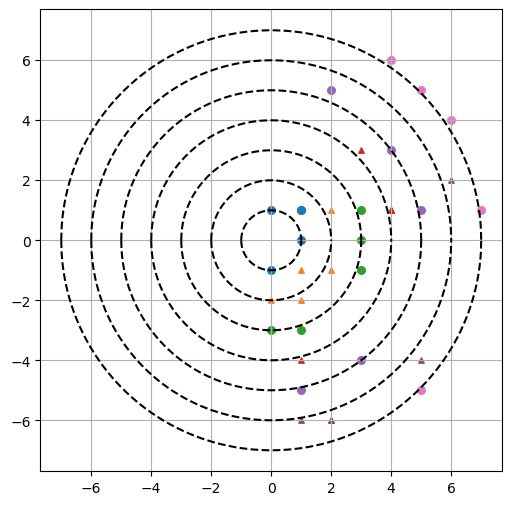

In [52]:
plt.figure(figsize=(8,6))
markers = ['o','^']
for ii,K in enumerate(ks_dict):
    print(ii%2)
    plt.scatter(ks_dict[K][:,0],ks_dict[K][:,1],s=15*((ii+1)%2+1),marker=markers[(ii%2)])
    xplt = np.linspace(-K,K,1000)
    plt.plot(xplt, np.sqrt(K**2-xplt**2),'--k')
    plt.plot(xplt,-np.sqrt(K**2-xplt**2),'--k')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [24]:
count_wrong/count*100

0.6666666666666667

In [25]:
len(ks)

1490

In [26]:
count_wrong

10

In [27]:
count

1500

In [28]:
unique

[44, 126, 235, 376, 481, 581, 712]

In [93]:
unique

[51, 131, 241, 381, 484, 583, 729]

In [95]:
unique

[36, 111, 214, 358, 489, 601, 716]

In [78]:
Ntest = np.array([np.min([int(100*K**(1.75)),1500]) for K in (np.array(Ks)-1)])

In [79]:
Ntest

array([ 100,  336,  683, 1131, 1500, 1500, 1500])

In [32]:
np.array(unique)/np.array(44*(np.array(Ks[:7])-1)**1.75,dtype=int)*100

array([100.        ,  85.71428571,  78.33333333,  75.65392354,
        65.44217687,  57.41106719,  53.73584906])

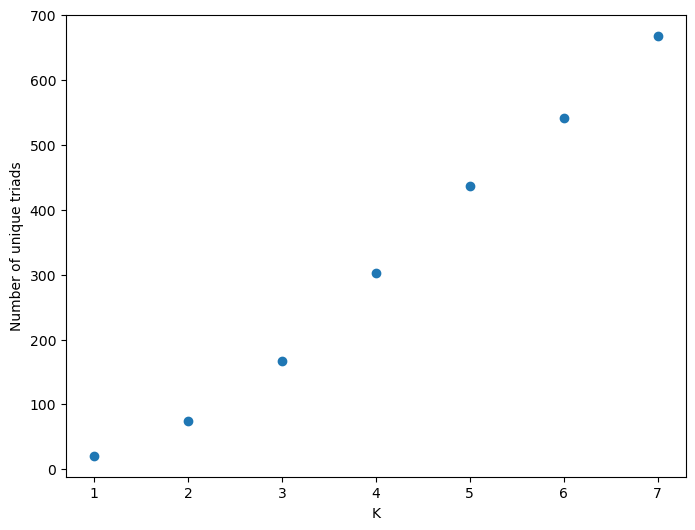

In [80]:
plt.figure(figsize=(8,6))
plt.plot(np.array(Ks)-1,np.array(unique),'o')
# plt.plot(np.array(Ks)-1,(Ntriads-np.array(unique7))/(Ntriads)*100,'o')
# plt.ylim(0,5000)
plt.xlabel('K')
plt.ylabel('Number of unique triads')
plt.show()

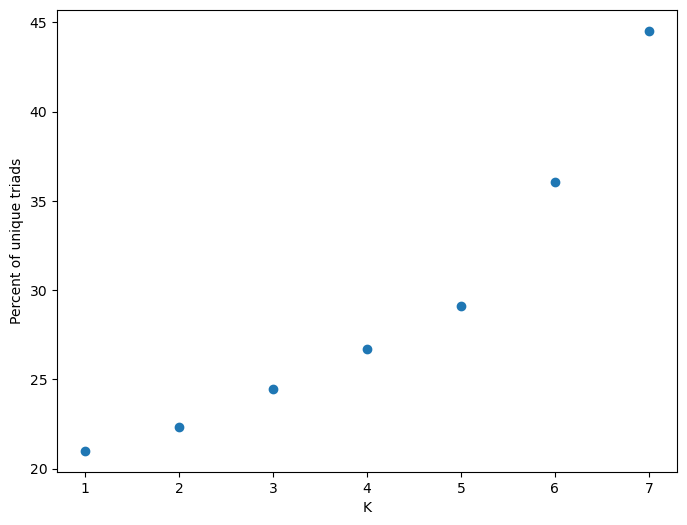

In [83]:
plt.figure(figsize=(8,6))
plt.plot(np.array(Ks)-1,(np.array(unique))/(Ntest)*100,'o')
# plt.plot(np.array(Ks)-1,(Ntriads-np.array(unique7))/(Ntriads)*100,'o')
# plt.ylim(0,5000)
plt.xlabel('K')
plt.ylabel('Percent of unique triads')
plt.show()

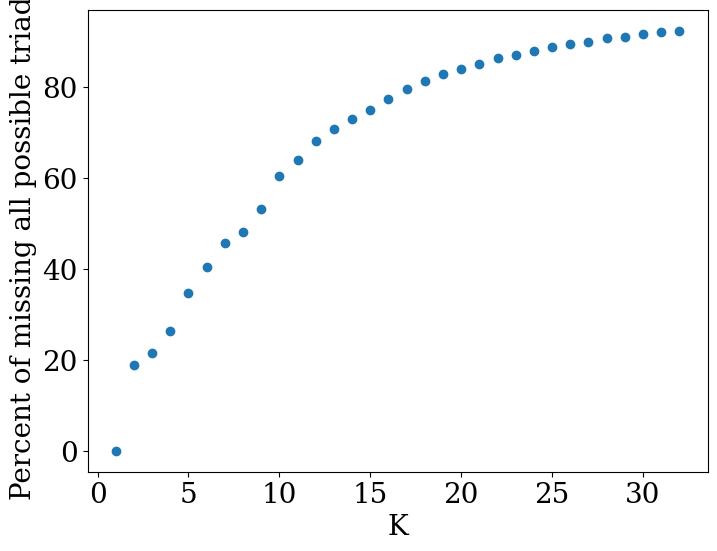

In [253]:
plt.figure(figsize=(8,6))
plt.plot(np.array(Ks)-1,(44*(np.array(Ks)-1)**1.75-np.array(unique7))/(44*(np.array(Ks)-1)**1.75)*100,'o')
# plt.plot(np.array(Ks)-1,(Ntriads-np.array(unique7))/(Ntriads)*100,'o')
# plt.ylim(0,5000)
plt.xlabel('K')
plt.ylabel('Percent of missing all possible triads')
plt.show()

In [254]:
print(unique7[:15],44*(np.array(Ks[:15])-1)**1.75)

[44, 120, 236, 367, 481, 603, 721, 870, 963, 980, 1051, 1088, 1147, 1208, 1256] [  44.          147.99776908  300.89493152  497.80317396  735.61433547
 1012.08587713 1325.48325776 1674.40361792 2057.67635939 2474.30183084
 2923.4109916  3404.23754402 3916.09792404 4458.37647973 5030.51420673]


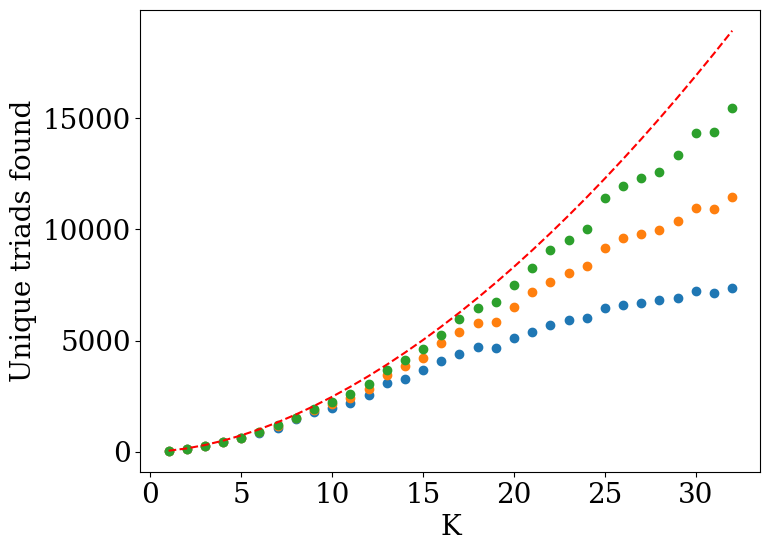

In [230]:
plt.figure(figsize=(8,6))
# plt.plot(Ks,np.array(unique2),'o')
# plt.plot(Ks,np.array(unique),'o')
# plt.plot(Ks,np.array(unique3),'o')
# plt.plot(Ks,np.array(unique4),'o')
plt.plot(np.array(Ks)-1,np.array(unique5),'o')
plt.plot(np.array(Ks)-1,np.array(unique6),'o')
plt.plot(np.array(Ks)-1,np.array(unique7),'o')
# plt.axhline(y=1000,c='tab:blue')
# plt.axhline(y=2000,c='tab:orange')
# plt.axhline(y=3000,c='tab:green')
# plt.axhline(y=4000,c='tab:red')
# plt.axhline(y=10000,c='tab:purple')
plt.plot(np.array(Ks)-1,44*(np.array(Ks)-1)**1.75,'--r')
# plt.ylim(0,5000)
plt.xlabel('K')
plt.ylabel('Unique triads found')
plt.show()

In [227]:
np.array(unique7[:15])

array([  44,  130,  254,  432,  634,  884, 1179, 1538, 1911, 2248, 2588,
       3055, 3654, 4142, 4636])

In [226]:
print(np.array(unique5[:15])-np.array(unique6[:15]),np.array(unique6[:15])-np.array(unique7[:15]))

[   0    0    0   -1  -16  -44  -65  -48  -89 -185 -225 -287 -391 -561
 -549] [   0    0    0    0   -5  -12  -30  -23  -46  -82 -179 -223 -194 -305
 -402]


In [228]:
test = np.array((44*(np.array(Ks)-1)**1.75),dtype=int)
test[:10]

array([  44,  147,  300,  497,  735, 1012, 1325, 1674, 2057, 2474])

In [218]:
m,b = np.polyfit(np.log10(np.array(Ks)[:22]-1),np.log10(np.array(unique7)[:22]),1)

In [219]:
m,10**b

(1.7556072634538789, 39.430968454592595)

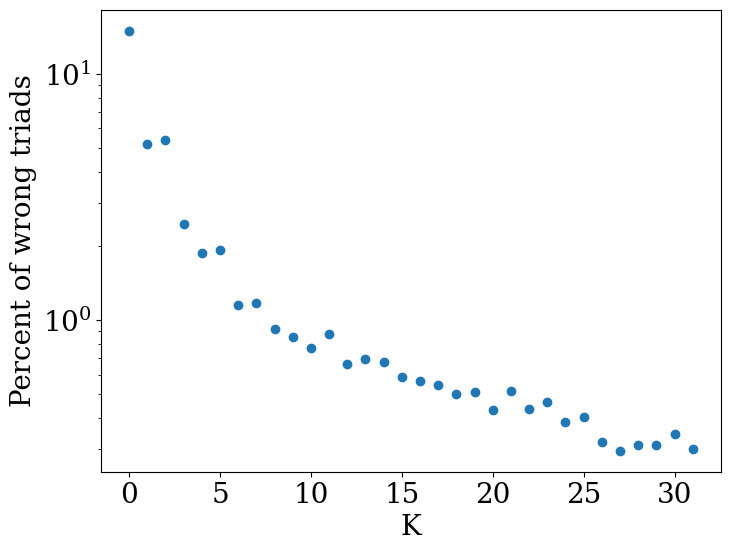

In [159]:
plt.figure(figsize=(8,6))
plt.semilogy(perc_wrong,'o')
plt.xlabel('K')
plt.ylabel('Percent of wrong triads')
plt.show()

# Version 2

100%|██████████████████████████████████████████████████████████████████████████████| 1500000/1500000 [05:04<00:00, 4929.15it/s]
/tmp/ipykernel_27370/2332614246.py:155: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_27370/2332614246.py:156: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


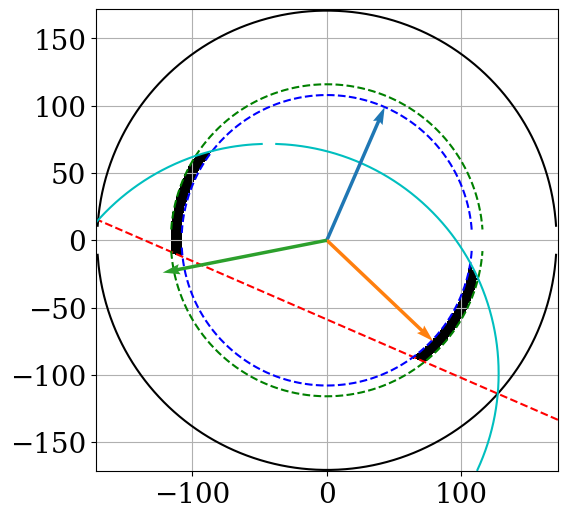

In [3]:
n = 512
P_max = 8
Ntriads =1500000
kmax = n/3
kmax_int = np.int32(np.floor(kmax))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
hist = np.zeros((int(kmax_int-P_max+1),P_max+2))

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    # mag_k = np.random.randint(1,kmax_int-P_max)
    mag_k = np.random.uniform(1,kmax-P_max)
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmag+P_max,kmax])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=(n/3):
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=(n/3):
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    # if pmag>32:
    #     print('pmag too large')
    #     count_wrong+=1
    #     break
    hist[int(np.round(kmag)-1),int(np.round(pmag)-np.round(kmag) - 1)]+=1 # So that first index is K = 1, P = 1

    Ks.append(np.round(kmag))
    Ps.append(np.round(pmag)-np.round(kmag)) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [4]:
print(count_wrong_1/count*100)
print(count_wrong_2/count*100)
print(count_wrong_3/count*100)
print(count_wrong_4/count*100)
print(count_wrong_5/count*100)
print((count_wrong_1+count_wrong_2+count_wrong_3+count_wrong_4+count_wrong_5)/count*100)

0.09659999999999999
0.2513333333333333
0.0005333333333333334
0.32186666666666663
0.03453333333333333
0.7048666666666666


In [477]:
theta = 6.1485
print(theta)
theta = theta - 2*np.pi*np.round(theta/np.pi/2) # From [-pi,pi]
print(theta)

6.1485
-0.13468530717958593


/tmp/ipykernel_14600/1370571422.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


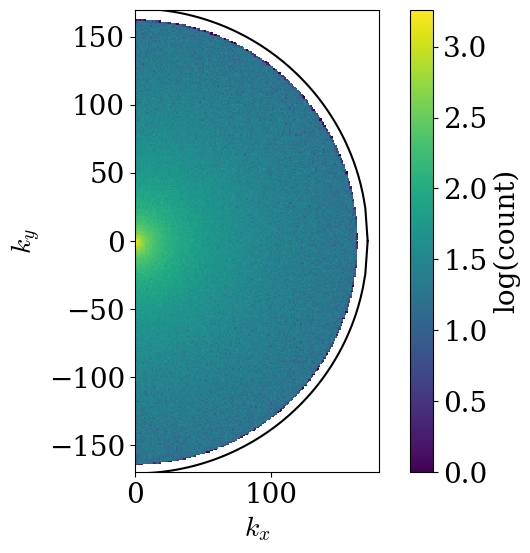

In [478]:
plt.figure(figsize=(8,6))
k_vecs = np.array(k_vecs)
h,xedges,yedges = np.histogram2d(k_vecs[:,0],k_vecs[:,1],bins=(np.arange(kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(0,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
# plt.xlim(0,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.show()

/tmp/ipykernel_27370/3527285363.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


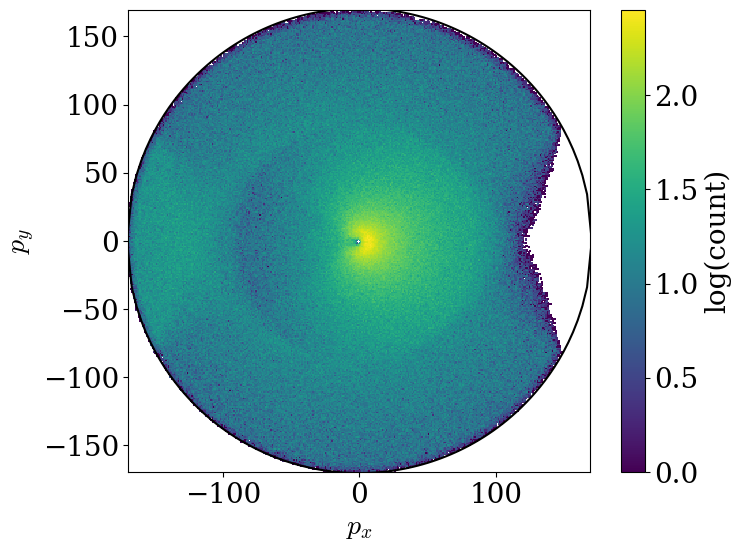

In [7]:
plt.figure(figsize=(8,6))
p_vecs = np.array(p_vecs)
h,xedges,yedges = np.histogram2d(p_vecs[:,0],p_vecs[:,1],bins=(np.arange(-kmax,kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(-kmax,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
plt.xlim(-kmax+1,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.show()

/tmp/ipykernel_27370/3764088242.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


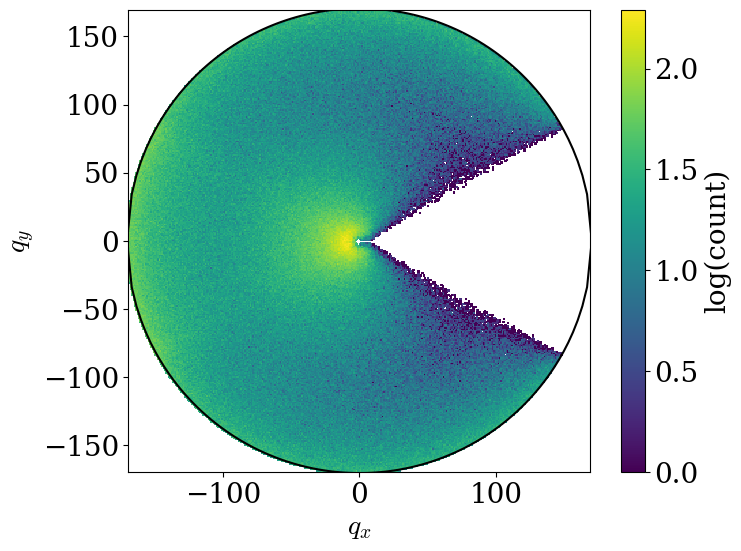

In [8]:
plt.figure(figsize=(8,6))
q_vecs = np.array(q_vecs)
h,xedges,yedges = np.histogram2d(q_vecs[:,0],q_vecs[:,1],bins=(np.arange(-kmax,kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(-kmax,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
plt.xlim(-kmax+1,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$q_x$')
plt.ylabel(r'$q_y$')
plt.show()

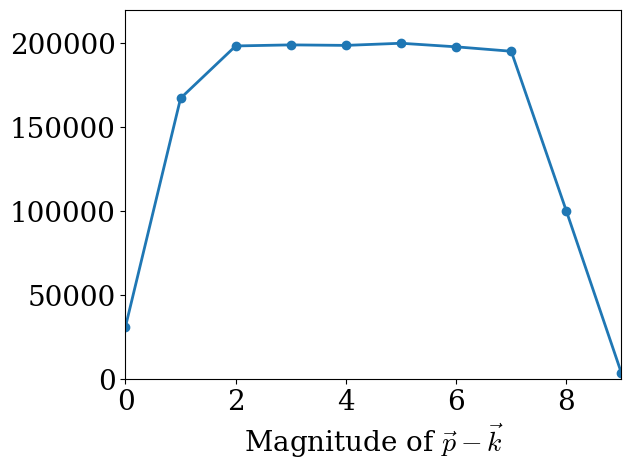

In [482]:
# Histogram
# q = k_vecs[:,0]
q = np.array(Ps)
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2,ls='-',marker='o')
plt.ylim(0,np.max(nn)*1.1)
plt.xlim(0,9)
plt.xlabel(r'Magnitude of $\vec{p}-\vec{k}$')
plt.show()

/tmp/ipykernel_14600/2223890246.py:10: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


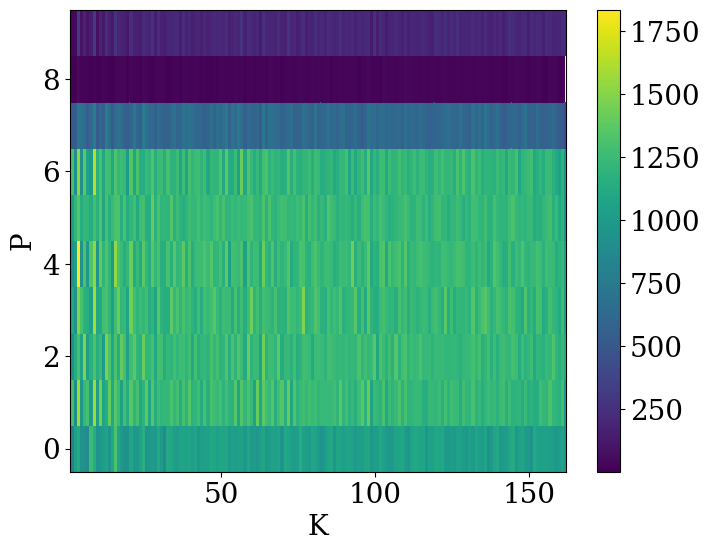

In [483]:
# (int(kmax_int-1),P_max+1)
plt.figure(figsize=(8,6))
Kplt = np.arange(1,kmax_int-P_max+2)
K_edges = np.concatenate([[Kplt[0]-0.5],Kplt+0.5])
Pplt = np.arange(P_max+2)
P_edges = np.concatenate([[Pplt[0]-0.5],Pplt+0.5])
K_edges,P_edges = np.meshgrid(K_edges,P_edges,indexing='ij')
hist[hist==0.0] = np.nan
plt.pcolor(K_edges,P_edges,hist)
plt.colorbar()
plt.xlim(1,kmax_int-P_max)
plt.xlabel('K')
plt.ylabel('P')
plt.show()

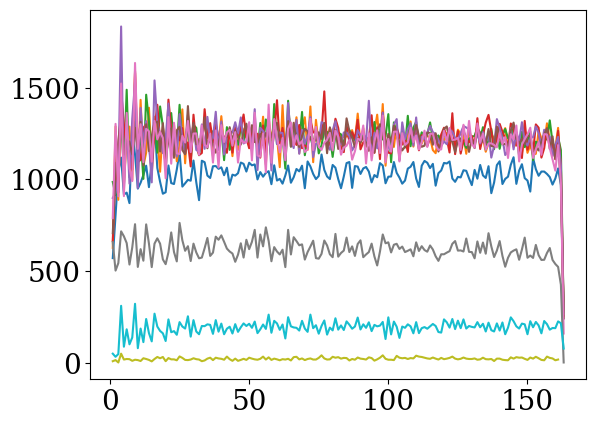

In [484]:
plt.plot(Kplt,hist)
xplt = np.linspace(1,n/2,1000)
# plt.plot(xplt,5*xplt,'--r')
# plt.plot(xplt,44*(xplt)**1.75,'-b')
# plt.ylim(0,200)#np.max(np.sum(hist,axis=1)))
# plt.xlim(1,30)
plt.show()

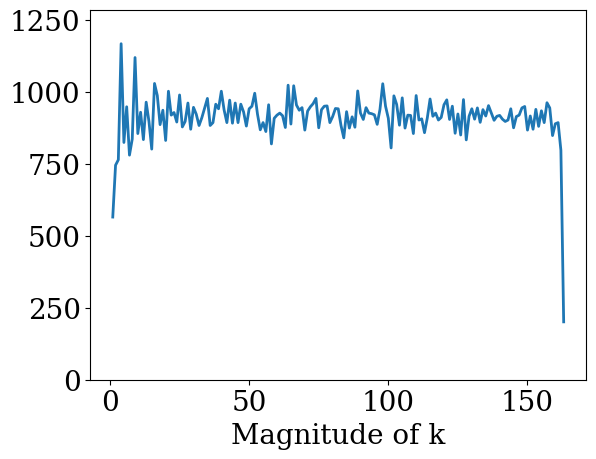

In [417]:
# Histogram
# q = k_vecs[:,0]
q = np.array(Ks)
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2)
plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,10)
plt.xlabel('Magnitude of k')
plt.show()

### Test stuff

In [319]:
np.arcsin(1/162)

0.0061728787084371845

In [320]:
pmag

159.8155186457185

In [321]:
px = 10.0
py = 100.0
pmag = np.sqrt(px**2+py**2)
pxtest = px + np.round(py/pmag)
pytest = py - np.round(px/pmag)

In [322]:
print(px/pmag,py/pmag)

0.09950371902099892 0.9950371902099892


In [323]:
print(pxtest,pytest)

11.0 100.0


In [364]:
px_old = np.round(mag_p*np.cos(theta_p))  # px
py_old = np.round(mag_p*np.sin(theta_p)) # py
pmag_old = np.sqrt(px_old**2+py_old**2)
ptheta_old = np.angle(px_old+1j*py_old)-np.angle(kx+1j*ky)
ptheta_old = ptheta_old -2*np.pi*np.round(ptheta_old/np.pi/2) # From [-pi,pi]
px = np.round(mag_p*np.cos(theta_p))  # px
py = np.round(mag_p*np.sin(theta_p)) # py

print(pmag_old,kmag)

# First attempt
print('Attempt 1')
px1,py1,good = fix_vec(px,py,kmag,rad_lim,low,high,count = 1,test=True)

# Second attempt
print('Attempt 2')
px2,py2,good = fix_vec(px1,py1,kmag,rad_lim,low,high,count = 2,test=True)

# Third attempt
print('Attempt 3')
px3,py3,good = fix_vec(px2,py2,kmag,rad_lim,low,high,count = 3,test=True)

# Fourth attempt
print('Attempt 4')
px4,py4,good = fix_vec(px3,py3,kmag,rad_lim,low,high,count = 4,test=True)

101.43470806385751 101.53324578678651
Attempt 1
pmag<=kmag
ptheta<low
Attempt 2
Attempt 3
Attempt 4


In [365]:
ptheta = np.angle(px+1j*py)-np.angle(kx+1j*ky)
ptheta = ptheta -2*np.pi*np.round(ptheta/np.pi/2) # From [-pi,pi]
print(low,high,ptheta_old,ptheta)

-2.094251206063133 -1.1457632781977882 -2.09714444584407 -2.09714444584407


In [366]:
test_old = np.sqrt(px_old**2+py_old**2)
test1 = np.sqrt(px**2+py**2)
test2 = np.sqrt((kx+px)**2+(ky+py)**2)
print(test_old,test1,test2)

101.43470806385751 101.43470806385751 101.24228365658294


/tmp/ipykernel_14600/4286394569.py:39: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_14600/4286394569.py:40: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


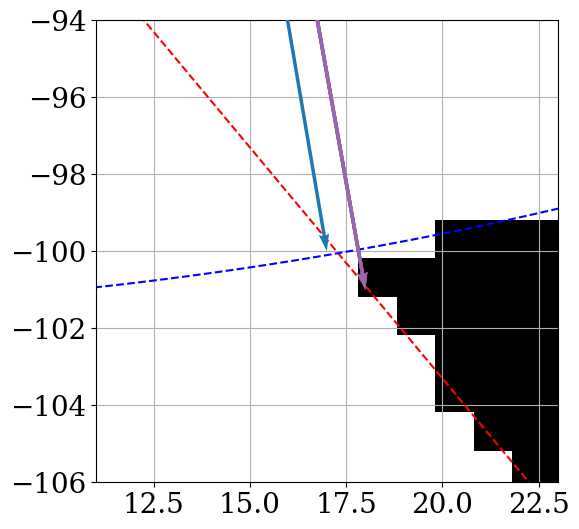

In [367]:
kt = np.arange(-kmax,kmax)
kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
# kt = np.linspace(-kmax,kmax,200)
KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
cond1 = ((KTX**2 + KTY**2) > kmag**2)
if kx==0:
    if ky>0:
        cond2 = (KTY > -ky/2)
    else:
        cond2 = (KTY < -ky/2)
else:
    cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
QX = -kx - KTX
QY = -ky - KTY
# cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
cond4 = ((QX**2 + QY**2) < kmax**2)
plt.figure(figsize=(8,6))
plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
xplt = np.linspace(-kmax,kmax,5000)
if kx == 0:
        plt.axhline(y = -ky/2)
else:
    plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
plt.plot(xplt[np.abs(xplt)<(kmax-0)], np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(kmax-0)], -np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
# plt.axvline(x = -kmax-kx,ls='-',c='c')
# plt.axvline(x = kmax-kx,ls='-',c='c')
# plt.axhline(y = kmax-ky,ls='-',c='c')
# plt.axhline(y = -kmax-ky,ls='-',c='c')
a = 1
b = 2*kx
c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
plt.plot(solp,xplt,'-c')
plt.plot(soln,xplt,'-c')
# plt.axhline(y = minp+1,ls='--',c='y')
# plt.axhline(y = maxp-1,ls='--',c='y')
# plt.axvline(x = minp2+1,ls='--',c='orange')
# plt.axvline(x = maxp2,ls='--',c='orange')
# plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
# V = np.array([[kx,ky],[px_old,py_old],[qx,qy],[px,py],[mag_p*np.cos(theta_p),mag_p*np.sin(theta_p)]])
V = np.array([[px,py],[px1,py1],[px2,py2],[px3,py3],[px4,py4]])
origin = np.array([[0,0,0,0,0],[0,0,0,0,0]]) # origin point
# V = np.array([[kx,ky],[px,py],[qx,qy]])
# origin = np.array([[0,0,0],[0,0,0]]) # origin point
plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green','tab:red','tab:purple'], angles='xy', scale_units='xy', scale=1,zorder=10)

plt.grid()
plt.gca().set_aspect(1)
plt.xlim(-kmax-1,kmax+1)
plt.ylim(-kmax-1,kmax+1)
plt.xlim(px-6,px+6)
plt.ylim(py-6,py+6)
# plt.xlim(px-5,55)
# plt.ylim(py-5,-155)
plt.show()

/tmp/ipykernel_14600/3219149552.py:34: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_14600/3219149552.py:35: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


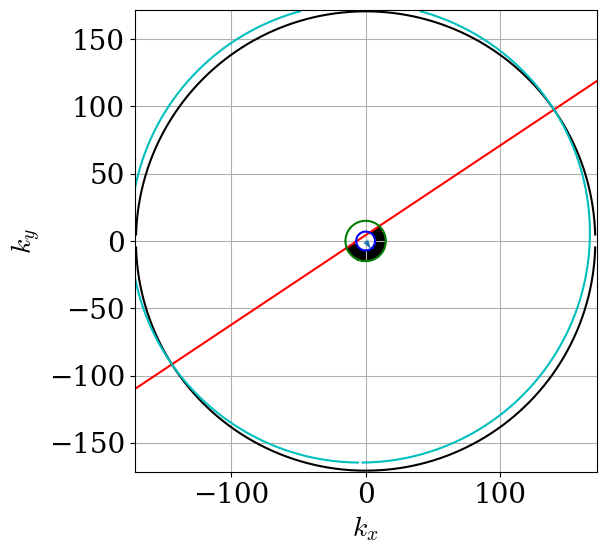

In [56]:
kt = np.arange(-kmax,kmax)
kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
# kt = np.linspace(-kmax,kmax,200)
KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
cond1 = ((KTX**2 + KTY**2) > K**2)
if kx==0:
    if ky>0:
        cond2 = (KTY > -ky/2)
    else:
        cond2 = (KTY < -ky/2)
else:
    cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
QX = -kx - KTX
QY = -ky - KTY
cond4 = ((QX**2 + QY**2) < kmax**2)
plt.figure(figsize=(8,6))
plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
xplt = np.linspace(-kmax,kmax,5000)
if kx == 0:
    plt.axhline(y = -ky/2,c='r')
else:
    plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'-r')
plt.plot(xplt[np.abs(xplt)<K], np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'-b')
plt.plot(xplt[np.abs(xplt)<K], -np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'-b')
plt.plot(xplt[np.abs(xplt)<(kmax-0)], np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(kmax-0)], -np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
a = 1
b = 2*kx
c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
plt.plot(solp,xplt,'-c')
plt.plot(soln,xplt,'-c')


# V = np.array([[kx,ky],[px,py],[qx,qy],[pxtest,pytest],[mag_p*np.cos(theta_p),mag_p*np.sin(theta_p)]])
# origin = np.array([[0,0,0,0,0],[0,0,0,0,0]]) # origin point
# V = np.array([[kx,ky],[px,py],[qx,qy]])
# origin = np.array([[0,0,0],[0,0,0]]) # origin point
V = np.array([[kx,ky]])
origin = np.array([[0],[0]]) # origin point
plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)

plt.grid()
plt.gca().set_aspect(1)
plt.xlim(-kmax-1,kmax+1)
plt.ylim(-kmax-1,kmax+1)
# plt.xlim(px-20,px+20)
# plt.ylim(py-20,py+20)
# plt.xlim(px-5,55)
# plt.ylim(py-5,-155)
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.show()

In [73]:
diffy

-1.0

In [298]:
((ptheta-np.angle(kx+1j*ky))<(low+angle_res)) or ((ptheta-np.angle(kx+1j*ky))>(high-angle_res)) or (pmag>rad_lim) or (pmag<K)

True

In [122]:
print(qx**2+qy**2,kmax**2)

29200.0 29241


In [66]:
print(mag_p*np.cos(theta_kmax_neg),mag_p*np.sin(theta_kmax_neg))

39.03497182379589 -163.3229003384993


In [243]:
print(kmax,n/3)
print(np.sqrt((kx + mag_p*np.cos(theta_kmax_neg))**2 + (ky + mag_p*np.sin(theta_kmax_neg))**2))
print(np.sqrt((qx)**2 + (qy)**2))

170.66666666666666 170.66666666666666
168.7779584660594
170.6985647274165


In [37]:
np.sort([K*np.sin(np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky)),K*np.sin(-np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky))])

array([11.24797384, 91.80936832])

/tmp/ipykernel_14600/766401759.py:40: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_14600/766401759.py:41: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


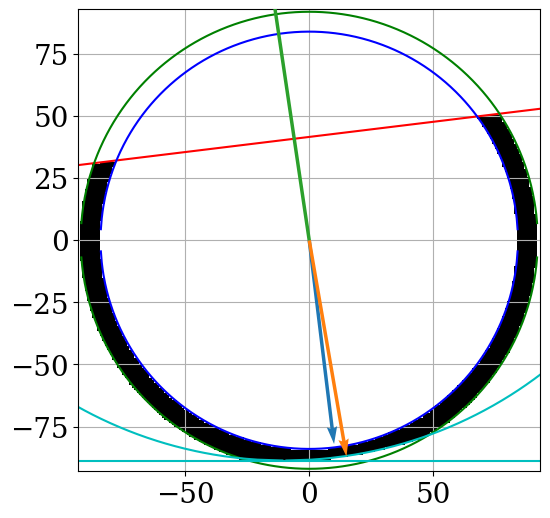

In [7]:
xplt = np.linspace(-kmax,kmax,500)
kt = np.arange(-kmax,kmax)
kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
# kt = np.linspace(-kmax,kmax,200)
KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
cond1 = ((KTX**2 + KTY**2) > K**2)
if kx==0:
    if ky>0:
        cond2 = (KTY > -ky/2)
    else:
        cond2 = (KTY < -ky/2)
else:
    cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
QX = -kx - KTX
QY = -ky - KTY
# cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
cond4 = ((QX**2 + QY**2) < kmax**2)
plt.figure(figsize=(8,6))
plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
xplt = np.linspace(-kmax,kmax,1000)
if kx == 0:
        plt.axhline(y = -ky/2)
else:
    plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'-r')
plt.plot(xplt[np.abs(xplt)<K], np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'-b')
plt.plot(xplt[np.abs(xplt)<K], -np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'-b')
plt.plot(xplt[np.abs(xplt)<(kmax-1)], np.sqrt((kmax-1)**2-xplt[np.abs(xplt)<(kmax-1)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(kmax-1)], -np.sqrt((kmax-1)**2-xplt[np.abs(xplt)<(kmax-1)]**2),'-k')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
plt.axvline(x = -kmax-kx,ls='-',c='c')
plt.axvline(x = kmax-kx,ls='-',c='c')
plt.axhline(y = kmax-ky,ls='-',c='c')
plt.axhline(y = -kmax-ky,ls='-',c='c')
a = 1
b = 2*kx
c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
plt.plot(solp,xplt,'-c')
plt.plot(soln,xplt,'-c')
# plt.axhline(y = minp+1,ls='--',c='y')
# plt.axhline(y = maxp-1,ls='--',c='y')
# plt.axvline(x = minp2+1,ls='--',c='orange')
# plt.axvline(x = maxp2,ls='--',c='orange')
# plt.axhline(y = py)
V = np.array([[kx,ky],[px,py],[qx,qy]])
origin = np.array([[0,0,0],[0,0,0]]) # origin point
plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
plt.grid()
plt.gca().set_aspect(1)
plt.xlim(-rad_lim-1,rad_lim+1)
plt.ylim(-rad_lim-1,rad_lim+1)
# plt.axhline(y=K*np.sin(np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky)),c='r')
# plt.axhline(y=K*np.sin(-np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky)),c='r')
#
# plt.xlim(minp2-4,maxp2+4)
# plt.ylim(minp-4,maxp+4)
# plt.xlim(kmax-kx-5,kmax-kx+5)
# plt.xlim(-75,-60)
# plt.ylim(-160,-145)
plt.show()    

In [14]:
yloc_K_max

-62.58877757956305

In [450]:
K*np.cos(np.arcsin(kmax**2/(2*K**2) -1) - np.angle(kx+1j*ky))

108.09944644209183

In [433]:
print(py)

108


In [432]:
np.sqrt((2*kx)**2 + (2*ky)**2)

216.1203368496357

In [413]:
n/3/2

85.33333333333333

In [411]:
(90**2+10**2)**(1/2)

90.55385138137417

In [391]:
py

46

In [ ]:
minp = np.min([int_N_pos,int_P_pos])
if upsol_x < 0:
    maxp = np.min([int_NP,rad_lim,kmax])
else:
    maxp = np.min([int_NP,upsol,rad_lim,kmax])

In [392]:
print(minp+1,maxp-1)
print(minp2+1,maxp2)

24.0 98.0
80.0 67.0


In [359]:
np.min([int_N_pos,int_P_pos])

150.0

In [360]:
np.min([int_NP,upsol,rad_lim,kmax])

151.0

In [342]:
a = (1+ky**2/kx**2)
b = 2*(kx/2+ky**2/(kx*2))*(ky/kx)
c = (kx/2+ky**2/(2*kx))**2 - (rad_lim)**2
upsol = np.round((-b+np.sqrt(b**2-4*a*c))/(2*a)) # ky location
upsol_x = -(ky/kx)*upsol - kx/2 - ky**2/(2*kx) # kx location
lwsol = np.round((-b-np.sqrt(b**2-4*a*c))/(2*a)) # ky location
lwsol_x = -(ky/kx)*lwsol - kx/2 - ky**2/(2*kx) # kx location
# 'Negative' branch
minp = np.max([-rad_lim,-kmax,-kmax-ky])
maxp = np.max([int_N_neg,int_P_neg])
print(minp+1,maxp-1)
# 'Positive' branch'
if upsol_x < 0:
    minp = np.min([int_N_pos,int_P_pos])
    maxp = np.min([int_NP,rad_lim,kmax])
else:
    minp = np.min([int_N_pos,int_P_pos])
    maxp = np.min([int_NP,upsol,rad_lim,kmax])
    print(minp+1,maxp-1)

-109.0 -106.0


In [329]:
[int_NP,upsol,rad_lim,kmax]

[268.0, 168.0, 170.0, 171]

In [289]:
print(np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1]),np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))]))

102.0 103.0


In [308]:
np.where((cond1&cond2&cond3&cond4))

(array([ 40,  40,  40,  41,  41,  41,  42,  42,  43, 148, 148, 149, 149,
        150, 150, 151, 151, 152, 152, 153, 153, 154, 154, 155, 155, 156,
        156, 157, 157, 158, 158, 159, 159, 160, 160, 161, 161, 162, 162,
        163, 163, 164, 164, 165, 165, 166, 166, 167, 167, 168, 168, 169,
        169, 170, 170, 171, 172, 172, 173, 173, 174, 174, 175, 175, 176,
        176, 177, 177, 178, 178, 179, 179, 180, 180, 181, 181, 182, 182,
        183, 183, 184, 184, 185, 185, 186, 186]),
 array([ 63,  64,  65,  62,  63,  64,  62,  63,  62, 338, 339, 338, 339,
        338, 339, 338, 339, 338, 339, 339, 340, 339, 340, 339, 340, 339,
        340, 339, 340, 339, 340, 339, 340, 339, 340, 339, 340, 339, 340,
        339, 340, 339, 340, 339, 340, 339, 340, 339, 340, 339, 340, 339,
        340, 339, 340, 340, 339, 340, 339, 340, 339, 340, 339, 340, 339,
        340, 339, 340, 339, 340, 339, 340, 339, 340, 339, 340, 339, 340,
        339, 340, 339, 340, 339, 340, 339, 340]))

In [219]:
kmax-3

168

In [271]:
print(kx,ky,pos,np.round(kmax-kx)<=K)

92.0 -140.0 1 True


In [270]:
if pos==0: # Negative
    minp = np.max([-rad_lim,-kmax,-kmax-ky])
    maxp = np.max([int_N_neg,int_P_neg])
else: # Positive
    minp = np.min([int_N_pos,int_P_pos])
    maxp = np.min([int_NP,upsol,rad_lim,kmax])
print(minp,maxp)

150.0 151.0


In [192]:
[-K-P_max,-kmax,-kmax-ky]

[-178.0, -171, -255.0]

In [193]:
[int_N_neg,int_P_neg]

[-168.0, -170.0]

In [5]:
294/150000

0.00196

In [229]:
count_wrong/count

0.19076666666666667

In [4]:
print(count, count_wrong)

10000 17


In [5]:
k_vecs = np.array(k_vecs)

In [6]:
k_vecs.shape

(149718, 2)

In [118]:
n/2/np.sqrt(2)

181.01933598375615

In [99]:
print(hist[:,0])

[ 15.  24.  52.  63.  77.  56.  82. 152. 123. 134. 110. 143. 208. 184.
 192. 309. 418. 353. 297. 541. 689. 588. 414. 406. 358. 296. 166. 241.
 120. 124.]


In [100]:
np.where(hist[hist>0] == np.min(hist[hist>0]))

(array([0]),)

In [102]:
np.nanmax(hist)

1073.0

In [313]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [318]:
kmags = np.round(k_vecs[:,0]**2+k_vecs[:,1]**2)
pmags = np.round(p_vecs[:,0]**2+p_vecs[:,1]**2)

In [322]:
np.where(kmags==K)

(array([ 921, 1048, 1259, 1430, 1615, 2092, 3063, 3845, 3890, 4043, 4643,
        5171, 5462, 5489, 5719, 5765, 5834, 5928, 6095, 6893, 7645, 7730,
        8306, 8695, 8729, 8781, 8887, 9366, 9733]),)

In [320]:
k_vecs[kmags==K]

array([[ 0,  1],
       [ 1,  0],
       [ 0, -1],
       [ 0,  1],
       [ 0, -1],
       [ 0, -1],
       [ 0,  1],
       [ 0,  1],
       [ 0,  1],
       [ 1,  0],
       [ 1,  0],
       [ 0,  1],
       [ 1,  0],
       [ 1,  0],
       [ 1,  0],
       [ 0,  1],
       [ 1,  0],
       [ 1,  0],
       [ 0, -1],
       [ 0, -1],
       [ 0,  1],
       [ 0, -1],
       [ 0,  1],
       [ 0,  1],
       [ 0,  1],
       [ 0,  1],
       [ 1,  0],
       [ 0, -1],
       [ 0,  1]])

In [319]:
for K in np.arange(1,kmax+1):
    print(len(np.unique(np.hstack([k_vecs[kmags==K],p_vecs[pmags==(K+1)]]),axis=0)))

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 29 and the array at index 1 has size 0

In [300]:
print(count_wrong/count*100)

0.33999999999999997


(array([  0.,  50.,  68.,  75., 170., 159., 211., 234., 254., 350., 289.,
        357., 342., 443., 459., 431., 572., 529., 567., 604., 562., 720.,
        678., 492., 351., 319., 260., 129., 181.,  53.,  57.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31.]),
 <BarContainer object of 31 artists>)

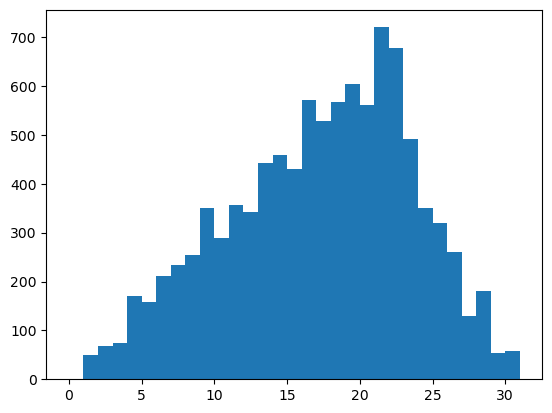

In [308]:
plt.hist(Ks,bins=np.arange(kmax))

In [258]:
np.round(kmax-kx)<=K

False

In [224]:
print(minp2,maxp2)

-5.0 -5.0


In [26]:
print(kx,ky,px,py,minp+1,maxp-1,minp2+1,maxp2)

21 -22 11 31 29.0 31.0 11.0 11.0


In [285]:
print(np.max([np.round(-np.sqrt((K+P_max)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax]))
print(np.round(-np.sqrt(K**2 - py**2)))

-27.0
-27.0


In [210]:
print(np.min([int_N_pos,int_P_pos]))
print( np.min([int_NP,upsol,K+P_max,kmax]))

6.0
24.0


In [197]:
print(np.max([np.round(-np.sqrt((K+P_max)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax]))
print(np.round(-np.sqrt(K**2 - py**2)))

-29.0
-21.0


In [284]:
print(py**2>K**2)
print(np.round(n/2-kx)<=np.round(np.sqrt(K**2 - py**2)))
print(np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>=np.round(-np.sqrt(K**2 - py**2)))

False
True
True


In [193]:
print(np.min([np.round(np.sqrt((K+P_max)**2 - py**2)),kmax-1]))
print(np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))]))

29.0
21.0


In [194]:
kmax-kx

21

In [161]:
np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>=np.round(-np.sqrt(K**2 - py**2))

True

In [163]:
print(np.min([np.round(np.sqrt((K+P_max)**2 - py**2)),kmax-1]))
print(np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))]))

25.0
15.0


In [164]:
kmax-kx

16

In [157]:
np.round(-np.sqrt(K**2-(n/2-kx)**2))

-15.0

In [153]:
np.max([-K-P_max,-kmax,int_NP,lwsol])

-28.0

In [155]:
print([int_N_neg,int_P_neg])

[-15.0, -21.0]


In [156]:
kmax-kx

16

In [148]:
maxp

-15.0

In [149]:
py

-16

In [146]:
minp2+1

16.0

In [147]:
maxp2-1

15.0

In [137]:
np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>=np.round(-np.sqrt(K**2 - py**2))

True

In [132]:
print(([np.round(np.sqrt((K+P_max)**2 - py**2)),kmax-1]))

[27.0, 31]


In [138]:
[np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))]

[7.0, 17.0]

In [129]:
print(np.min([np.round(np.sqrt((K+P_max)**2 - py**2)),kmax-1,kmax-kx]))
print(np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))]))

18.0
17.0


In [133]:
np.round(n/2-kx)<=np.round(np.sqrt(K**2 - py**2))

False

In [ ]:

elif np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>=np.round(-np.sqrt(K**2 - py**2)): # px >0 
    maxp2 =  np.min([np.round(np.sqrt((K+P_max)**2 - py**2)),kmax-1])
    minp2 = np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))])
elif np.round(n/2-kx)<=np.round(np.sqrt(K**2 - py**2)): # px < 0
    minp2 = np.max([np.round(-np.sqrt((K+P_max)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax])
    maxp2 = np.round(-np.sqrt(K**2 - py**2))

In [115]:
maxp2

19.0

In [108]:
np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))

-11.0

In [107]:
np.round(-np.sqrt(K**2 - py**2))

-11.0

In [56]:
px**2+py**2

1061

In [57]:
qx**2+qy**2

1044

In [48]:
maxp

13.0

In [46]:
print(px**2+py**2,qx**2+qy**2)

829 829


In [43]:
(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>(-np.sqrt(K**2 - py**2))

False

In [41]:
print(-(ky/kx)*py - kx/2 - ky**2/(2*kx))
print(-np.sqrt(K**2 - py**2))

-23.325000000000003
-20.71231517720798


In [33]:
kx = 14
ky = 22
py = -27
print(-(ky/kx)*py - kx/2 - ky**2/(2*kx))
print(-(ky//kx)*py - kx//2 - ky**2//(2*kx))
print(np.round(-np.sqrt((K+P_max)**2 - py**2)))

18.142857142857146
3
nan


/tmp/ipykernel_27238/3830118747.py:6: RuntimeWarning: invalid value encountered in sqrt
  print(np.round(-np.sqrt((K+P_max)**2 - py**2)))


In [16]:
print(kx,ky)

21 16


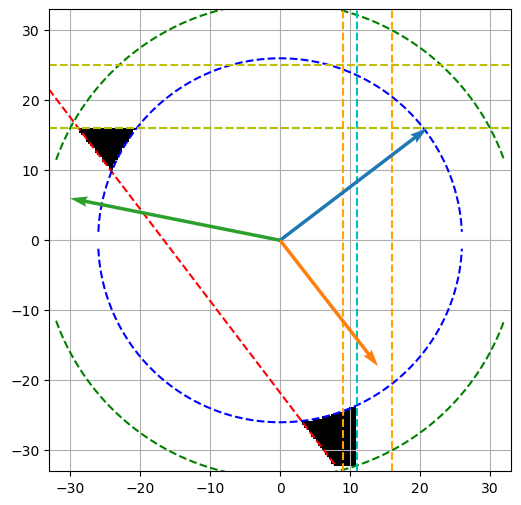

In [17]:
# kt = np.arange(-kmax,kmax)
kt = np.linspace(-n/2,n/2,200)
KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
cond1 = ((KTX**2 + KTY**2) > K**2)
if kx==0:
    if ky>0:
        cond2 = (KTY > -ky/2)
    else:
        cond2 = (KTY < -ky/2)
else:
    cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
cond3 = ((KTX**2 + KTY**2) < (K+P_max)**2)
QX = -kx - KTX
QY = -ky - KTY
cond4 = (np.abs(QX)<n/2)&(np.abs(QY)<n/2)
plt.figure(figsize=(8,6))
plt.pcolor(KTX,KTY,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
if kx == 0:
        plt.axhline(y = -ky/2)
else:
    plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
xplt = np.linspace(-n/2,n/2,500)
plt.plot(xplt[np.abs(xplt)<K], np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'--b')
plt.plot(xplt[np.abs(xplt)<K], -np.sqrt(K**2-xplt[np.abs(xplt)<K]**2),'--b')
plt.plot(xplt[np.abs(xplt)<(K+P_max)], np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(K+P_max)]**2),'--g')
plt.plot(xplt[np.abs(xplt)<(K+P_max)], -np.sqrt((K+P_max)**2-xplt[np.abs(xplt)<(K+P_max)]**2),'--g')
plt.axvline(x = -n/2-kx,ls='--',c='c')
plt.axvline(x = n/2-kx,ls='--',c='c')
plt.axhline(y = n/2-ky,ls='--',c='c')
plt.axhline(y = -n/2-ky,ls='--',c='c')
plt.axhline(y = minp,ls='--',c='y')
plt.axhline(y = maxp,ls='--',c='y')
plt.axvline(x = minp2,ls='--',c='orange')
plt.axvline(x = maxp2,ls='--',c='orange')
V = np.array([[kx,ky],[px,py],[qx,qy]])
origin = np.array([[0,0,0],[0,0,0]]) # origin point
plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
plt.grid()
plt.gca().set_aspect(1)
plt.xlim(-n/2-1,n/2+1)
plt.ylim(-n/2-1,n/2+1)
plt.show()    

In [88]:
l = 1
h = 512/3
pwr = -0.5
y = np.random.uniform(size= 5000)
x = np.floor(((h**(pwr+1)-l**(pwr+1))*y + l**(pwr+1))**(1/(pwr+1)))

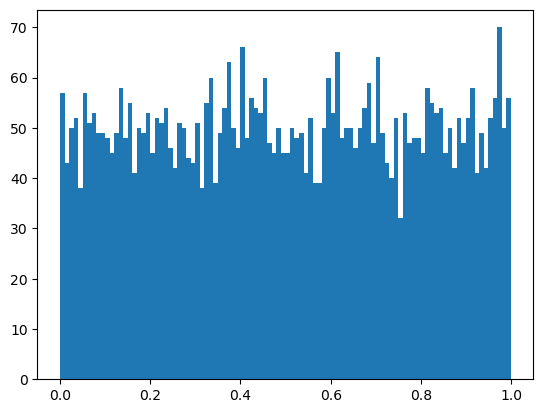

In [89]:
plt.hist(y,bins=100)
plt.show()

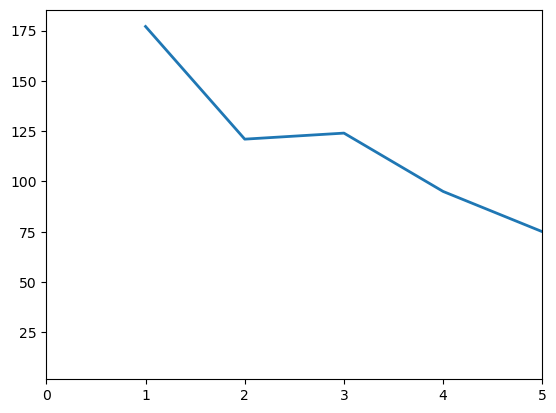

In [90]:
# Histogram
q = x
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2)
# plt.ylim(0,np.max(nn)*1.1)
plt.xlim(0,5)
plt.show()

/tmp/ipykernel_21282/1764395003.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,np.max(nn)*1.1)


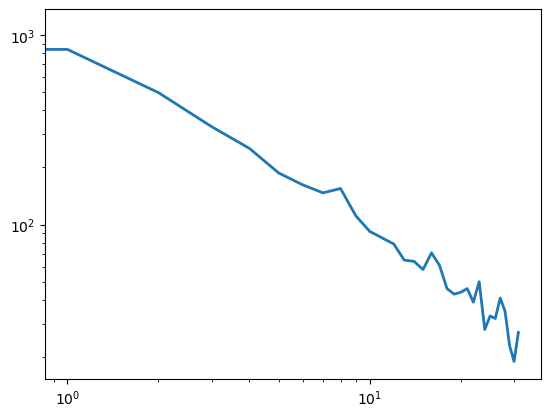

In [307]:
# Histogram
q = x
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.loglog((np.diff(bins)/2+bins[:-1]),nn,lw=2)
plt.ylim(0,np.max(nn)*1.1)
plt.show()

In [ ]:

# # Intersection of Q < kmax circle with K circle
# yloc_K_min,yloc_K_max = np.sort([K*np.sin(np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky)),K*np.sin(-np.arccos(kmax**2/(2*K**2) -1) + np.angle(kx+1j*ky))])
# # Intersection of Q < kmax circle with min(K + P_max,kmax)circle
# yloc_P_min,yloc_P_max = np.sort([(rad_lim)*np.sin(np.arccos(kmax**2/(2*(rad_lim)**2) -1) + np.angle(kx+1j*ky)),(rad_lim)*np.sin(-np.arccos(kmax**2/(2*(rad_lim)**2) -1) + np.angle(kx+1j*ky))])
# ## First, we choose py:
# if kx==0:
#     if ky<0:
#         upsol = np.round(np.abs(ky)/2) # P < Q
#         minp = np.max([-rad_lim,-kmax,yloc_K_max])
#         maxp = np.min([upsol,kmax-1])
#     elif ky>0:
#         lwsol = np.round(-np.abs(ky)/2) # P < Q
#         minp = np.max([lwsol,-kmax])
#         maxp = np.min([rad_lim,yloc_K_min])
# else:
#     # Intersection between P<Q line and min(K + P_max,kmax) circle
#     a = (1+ky**2/kx**2)
#     b = 2*(kx/2+ky**2/(kx*2))*(ky/kx)
#     c = (kx/2+ky**2/(2*kx))**2 - (rad_lim)**2
#     upsol = np.round((-b+np.sqrt(b**2-4*a*c))/(2*a)) # ky location
#     upsol_x = -(ky/kx)*upsol - kx/2 - ky**2/(2*kx) # kx location
#     lwsol = np.round((-b-np.sqrt(b**2-4*a*c))/(2*a)) # ky location
#     lwsol_x = -(ky/kx)*lwsol - kx/2 - ky**2/(2*kx) # kx location
#     if np.sqrt((2*kx)**2 + (2*ky)**2)>kmax: # Possible pys becomes disconnected
#         # Intersection of P < Q line and K circle
#         a = (1+ky**2/kx**2)
#         b = 2*(kx/2+ky**2/(kx*2))*(ky/kx)
#         c = (kx/2+ky**2/(2*kx))**2 - (K)**2
#         int_P_pos = np.round((-b+np.sqrt(b**2-4*a*c))/(2*a))
#         int_P_neg = np.round((-b-np.sqrt(b**2-4*a*c))/(2*a))
#         # Intersection of kmax-kx line and K circle
#         int_N_pos = np.round(np.sqrt(K**2-(kmax-kx-1)**2))
#         int_N_neg = np.round(-np.sqrt(K**2-(kmax-kx-1)**2))
#         pos = np.random.randint(0,high = 2) # Is px positive or negative?
#         # print('pos py',pos)
#         if ky<0:
#             if pos==0: # Negative
#                 minp = np.max([-rad_lim,-kmax,np.min([yloc_P_min,yloc_K_min])])
#                 maxp = np.max([yloc_K_min,int_P_neg])
#             else: # Positive
#                 minp = np.min([yloc_K_max,int_P_pos])
#                 if upsol_x < 0:
#                     maxp = np.min([rad_lim,kmax,yloc_P_max])
#                 else:
#                     maxp = np.min([upsol,rad_lim,kmax])
#         elif ky>0:
#             if pos==0: # Negative
#                 maxp = np.max([yloc_K_min,int_P_neg])
#                 if lwsol_x < 0:
#                     minp = np.max([-rad_lim,-kmax])
#                 else:
#                     minp = np.max([-rad_lim,-kmax,lwsol])
#             else: # Positive
#                 minp = np.min([upsol,int_P_pos])
#                 maxp = np.min([rad_lim,kmax,yloc_K_max])
#         else: # ky = 0
#             if pos==0: # Negative
#                 minp = np.max([-rad_lim,-kmax])
#                 maxp = np.max([int_P_neg,yloc_K_min])
#             else: # Positive
#                 maxp = np.min([rad_lim,kmax])
#                 minp = np.min([int_P_pos,yloc_K_max])
#     else:
#         if ky<0:
#             minp = np.max([-rad_lim,-kmax,-kmax-ky])
#             if upsol_x < 0:
#                 maxp = np.min([rad_lim,kmax-1,kmax-ky])
#             else:
#                 maxp = np.min([upsol,kmax-1,kmax-ky])
#         elif ky>0:
#             maxp = np.min([rad_lim,kmax-1,kmax-ky])
#             if lwsol_x < 0:
#                 minp = np.max([-rad_lim,-kmax,-kmax-ky])
#             else:
#                 minp = np.max([lwsol,-kmax,-kmax-ky])
#         else:
#             minp = np.max([-rad_lim,-kmax])
#             maxp = np.min([rad_lim,kmax-1])

# if (minp+1)==(maxp-1):
#     py = minp+1
# elif minp ==(maxp-1):
#     py = maxp
# else:
#     py = np.random.randint(minp+1, high = maxp)   # [low,high). Removing = minp and maxp because we want to avoid cases where no possible px exists

# py = 16

# ## Next, we choose px based on the constraints
# if kx == 0:
#     if py**2>K**2:
#         minp2 = np.max([np.round(-np.sqrt((rad_lim)**2 - py**2)),-kmax])
#         maxp2 = np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1])
#     else:
#         pos = np.random.randint(0,high = 2) # Is px positive or negative?
#         # print('pos px',pos)
#         if pos==0: # Negative
#             minp2 = np.max([np.round(-np.sqrt((rad_lim)**2 - py**2)),-kmax])
#             maxp2 = np.round(-np.sqrt(K**2 - py**2))
#         else: # Positive
#             maxp2 =  np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1])
#             minp2 = np.round(np.sqrt(K**2 - py**2))
# else:
#     if py**2>K**2:
#         minp2 = np.max([np.round(-np.sqrt((rad_lim)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax])
#         maxp2 = np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1])
#     elif np.round(kmax-kx)<=np.round(np.sqrt(K**2 - py**2)): # px < 0
#         minp2 = np.max([np.round(-np.sqrt((rad_lim)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax])
#         maxp2 = np.round(-np.sqrt(K**2 - py**2))
#     elif np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx))>=np.round(-np.sqrt(K**2 - py**2)): # px >0 
#         maxp2 =  np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1])
#         minp2 = np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))])
#     else:
#         pos = np.random.randint(0,high = 2) # Is px positive or negative?
#         # print('pos px',pos)
#         if pos==0: # Negative
#             minp2 = np.max([np.round(-np.sqrt((rad_lim)**2 - py**2)),np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),-kmax])
#             maxp2 = np.round(-np.sqrt(K**2 - py**2))
#         else: # Positive
#             maxp2 =  np.min([np.round(np.sqrt((rad_lim)**2 - py**2)),kmax-1])
#             minp2 = np.max([np.round(-(ky/kx)*py - kx/2 - ky**2/(2*kx)),np.round(np.sqrt(K**2 - py**2))])

# # Final constraint so that vector q is inside the dealiased grid
# qmax = np.round(np.sqrt(kmax**2 - (ky+py)**2) - kx)
# maxp2 = np.min([maxp2, qmax])
# qmin = np.round(-np.sqrt(kmax**2 - (ky+py)**2) - kx)
# minp2 = np.max([minp2, qmin])
# if (minp2<maxp2):
#     px = np.random.randint(minp2+1,high=maxp2+1)
#     # print('px',px)
#     pmag = np.round(np.sqrt(px**2 + py**2))
#     # Finally, find qx,qy
#     qx = -kx -px
#     qy = -ky -py
#     qmag = np.round(np.sqrt(qx**2 + qy**2))
# elif minp2==maxp2:
#     px = minp2
#     # print('px',px)
#     pmag = np.round(np.sqrt(px**2 + py**2))
#     # Finally, find qx,qy
#     qx = -kx -px
#     qy = -ky -py
#     qmag = np.round(np.sqrt(qx**2 + qy**2))
# else:
#     print('kx',kx,'ky',ky,'py',py)
#     print('------ max/min wrong')
#     px = np.nan
#     break

# Version 3

In [5]:
spec_avg= np.array([1.34468066e+00, 3.74542969e+00, 2.81523042e+00, 2.56587370e+00,
       1.08851511e+00, 9.30716650e-01, 5.95736834e-01, 4.71823639e-01,
       4.18419909e-01, 2.79902990e-01, 1.84899574e-01, 1.10254495e-01,
       9.03358414e-02, 5.51368092e-02, 3.47400325e-02, 3.07075368e-02,
       2.00313506e-02, 1.38229806e-02, 1.04778018e-02, 7.68479261e-03,
       7.25517081e-03, 5.29058582e-03, 4.36521240e-03, 3.48450762e-03,
       3.17916232e-03, 2.48624254e-03, 1.95305856e-03, 1.84809552e-03,
       1.38219011e-03, 1.36381478e-03, 1.06837077e-03, 8.49631451e-04,
       7.85973680e-04, 7.05348132e-04, 5.81795767e-04, 4.87666487e-04,
       4.05876665e-04, 3.72838839e-04, 2.99049743e-04, 2.78220347e-04,
       2.17884110e-04, 1.98072938e-04, 1.71386613e-04, 1.38519572e-04,
       1.28359903e-04, 1.03454453e-04, 9.58125651e-05, 8.00052846e-05,
       7.00249900e-05, 5.88427907e-05, 5.01352418e-05, 4.50362835e-05,
       3.46895374e-05, 3.10451328e-05, 2.69223184e-05, 2.15165483e-05,
       1.99901354e-05, 1.49216768e-05, 1.44534562e-05, 1.14660880e-05,
       9.18197093e-06, 8.40947742e-06, 6.25903119e-06, 6.26428299e-06,
       4.58661809e-06, 3.99931639e-06, 3.25960544e-06, 2.63585047e-06,
       2.32285653e-06, 1.79496880e-06, 1.49380562e-06, 1.32799527e-06,
       9.77742759e-07, 8.55467452e-07, 6.68897907e-07, 5.81707364e-07,
       4.84417587e-07, 3.61428205e-07, 3.05409264e-07, 2.44031001e-07,
       2.23449296e-07, 1.90866297e-07, 2.00503872e-07, 2.30649389e-07,
       2.34987822e-07])
kk = np.arange(1,len(spec_avg)+1)
spec_avg *= 1/kk/2/np.pi # Because KE spec is 2*Pi*k*rho^2
spec_avg_v2 = np.zeros(spec_avg.shape)
spec_avg_v2[kk<=9] = kk[kk<=9]**(-5/3-1)
spec_avg_v2[kk<=9] *= spec_avg[kk==9]/kk[kk==9]**(-5/3-1)
spec_avg_v2[kk>9] = kk[kk>9]**(-5./3.-1)
spec_avg_v2[kk>9] *= spec_avg[kk==9]/kk[kk==9]**(-5./3.-1)
rho = np.sqrt(spec_avg)

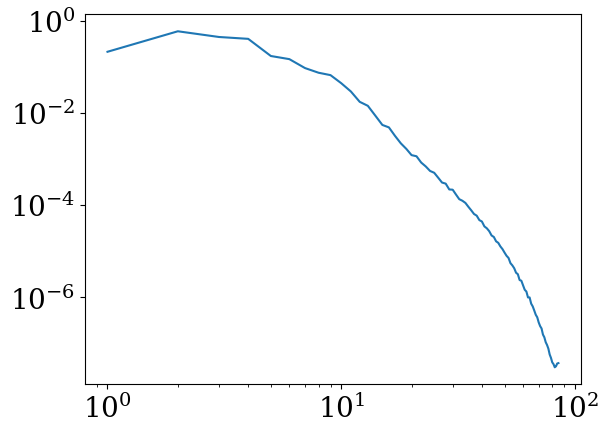

In [6]:
plt.loglog(kk,kk*rho**2)
plt.show()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4500000/4500000 [16:57<00:00, 4423.20it/s]
/tmp/ipykernel_30180/386315644.py:165: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_30180/386315644.py:166: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


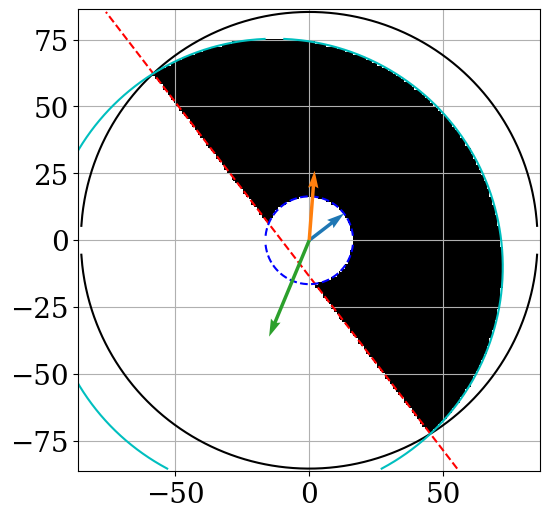

In [6]:
n = 256
N_shells = 10.0
M_max = np.int32(np.round(n/3.0/N_shells))
Ntriads = 3*1500000
kmax = n/3
kmax_int = np.int32(np.floor(kmax))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []
hist = np.zeros((int(kmax_int-N_shells+1),M_max))

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    # mag_k = np.random.randint(1,kmax_int-P_max)
    mag_k = np.random.uniform(1,kmax-N_shells) # So at least one shell is represented for the last K
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = kmax 
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=(n/3):
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=(n/3):
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    # Group into shells of 10 wavenumbers
    # print(kx,ky,px,py,kmag,pmag)
    # print(pmag-kmag,np.round(pmag-kmag),np.round(pmag-kmag) % 10)
    M_loc = np.floor((pmag-kmag)/N_shells)
    hist[int(np.round(kmag)-1),int(M_loc)]+=1 # kmag-1 so that first index is K = 1

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    term.append(term_tmp)
    Ks.append(np.round(kmag))
    Ps.append(np.round(pmag-kmag)) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [21]:
# n = 256
# N_shells = 10.0
# M_max = np.int32(np.round(n/3.0/N_shells))
# Ntriads = 1#3*1500000
# kmax = n/3
# kmax_int = np.int32(np.floor(kmax))

# k_vecs = []
# p_vecs = []
# q_vecs = []
# Ks = []
# Ps = []
# ratio1 = []
# ratio2 = []
# term = []
# hist = np.zeros((int(kmax_int-N_shells+1),M_max))

# count = 0
# count_wrong_1 = 0
# count_wrong_2 = 0
# count_wrong_3 = 0
# count_wrong_4 = 0
# count_wrong_5 = 0
# for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
#     count+=1
#     ##################
#     ## Choose k vector
#     # Random theta
#     # theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
#     theta_k = np.pi/4
#     # Random magnitude
#     # mag_k = np.random.randint(1,kmax_int-P_max)
#     mag_k = 40 #np.random.uniform(1,kmax-N_shells) # So at least one shell is represented for the last K
#     kx = np.round(mag_k*np.cos(theta_k))  # kx
#     ky = np.round(mag_k*np.sin(theta_k)) # ky
#     kmag = np.sqrt(kx**2 + ky**2)
    
#     ##################
#     ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
#     ########
#     rad_lim = kmax 
#     # Choose a random radius between kmag and rad_lim
#     mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
#     # Intersection of P < Q line and mag_p circle
#     theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
#     theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
#     if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
#         # Intersection of Q < kmax curve and mag_p circle
#         theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
#         theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
#         pos = np.random.randint(0,high = 2) # Choose a branch
#         if pos==0: # neg
#             low = theta_PQ_neg
#             high = theta_kmax_neg
#         else: # pos
#             low=theta_kmax_pos
#             high=theta_PQ_pos
#     else:
#         low=theta_PQ_neg
#         high=theta_PQ_pos
#     # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
#     theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
#     px = np.round(mag_p*np.cos(theta_p))  # px
#     py = np.round(mag_p*np.sin(theta_p)) # py
    
#     ####### Check and correct for discreteness effects
#     # count_e = 1
#     # good = False
#     # while not good:
#     #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
#     #     count_e += 1
#     pmag = np.sqrt(px**2+py**2)
#     # Finally, find qx,qy
#     qx = -kx -px
#     qy = -ky -py
#     qmag = np.sqrt(qx**2 + qy**2)

#     cross = (kx*py)-(ky*px)
#     if cross==0:
#         count_wrong_1 += 1
#         # print('------cross = 0')
#         # print('kx',kx,'ky',ky,'px',px,'py',py)
#         continue

#     if qmag>=(n/3):
#         count_wrong_2 += 1
#         # print('---- (qx,qy) is outside the dealiased grid! ----')
#         continue

#     if pmag>=(n/3):
#         count_wrong_3 += 1
#         # print('---- (px,py) is outside the dealiased grid! ----')
#         continue
    
#     if qmag<pmag:
#         count_wrong_4+=1
#         # print('------qmag<pmag')
#         # print('kx',kx,'ky',ky,'px',px,'py',py)
#         continue
    
#     if kmag>=pmag:
#         count_wrong_5 += 1
#         # print('------ kmag = pmag')
#         # print('kx',kx,'ky',ky,'px',px,'py',py)
#         continue

#     # Group into shells of 10 wavenumbers
#     # print(kx,ky,px,py,kmag,pmag)
#     # print(pmag-kmag,np.round(pmag-kmag),np.round(pmag-kmag) % 10)
#     M_loc = np.floor((pmag-kmag)/N_shells)
#     hist[int(np.round(kmag)-1),int(M_loc)]+=1 # kmag-1 so that first index is K = 1

#     if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
#         ratio1.append(qmag/pmag)
#     else:
#         ratio2.append(qmag/pmag)
#     term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
#     term.append(term_tmp)
#     Ks.append(np.round(kmag))
#     Ps.append(np.round(pmag-kmag)) 
#     k_vecs.append([kx,ky])
#     p_vecs.append([px,py])
#     q_vecs.append([qx,qy])
    
# # if count_wrong>0:
# # if (Ntr%(Ntriads/25)==0) or (Ntr<4):
# if 1:
#     kt = np.arange(-kmax_int,kmax_int)
#     kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
#     # kt = np.linspace(-kmax,kmax,200)
#     KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
#     KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
#     cond1 = ((KTX**2 + KTY**2) > kmag**2)
#     if kx==0:
#         if ky>0:
#             cond2 = (KTY > -ky/2)
#         else:
#             cond2 = (KTY < -ky/2)
#     else:
#         cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
#     cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
#     QX = -kx - KTX
#     QY = -ky - KTY
#     # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
#     cond4 = ((QX**2 + QY**2) < kmax**2)
#     plt.figure(figsize=(8,6))
#     plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
#     xplt = np.linspace(-kmax,kmax,10000)
#     if kx == 0:
#             plt.axhline(y = -ky/2)
#     else:
#         plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'-r')
#     plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'-b')
#     plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'-b')
#     plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
#     plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
#     # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
#     # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'-g')
#     # plt.axvline(x = -kmax-kx,ls='-',c='c')
#     # plt.axvline(x = kmax-kx,ls='-',c='c')
#     # plt.axhline(y = kmax-ky,ls='-',c='c')
#     # plt.axhline(y = -kmax-ky,ls='-',c='c')
#     a = 1
#     b = 2*kx
#     c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
#     solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
#     soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
#     plt.plot(solp,xplt,'-c')
#     plt.plot(soln,xplt,'-c')
#     # plt.axhline(y = minp+1,ls='--',c='y')
#     # plt.axhline(y = maxp-1,ls='--',c='y')
#     # plt.axvline(x = minp2+1,ls='--',c='orange')
#     # plt.axvline(x = maxp2,ls='--',c='orange')
#     # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
#     V = np.array([[kx,ky]])
#     origin = np.array([[0],[0]]) # origin point
#     plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
#     plt.grid()
#     plt.gca().set_aspect(1)
#     plt.xlim(-kmax-1,kmax+1)
#     plt.ylim(-kmax-1,kmax+1)
#     plt.xlabel(r'$k_x$')
#     plt.ylabel(r'$k_y$')
#     # plt.xlim(px-5,px+5)
#     # plt.ylim(py-5,py+5)
#     plt.savefig('./figs/triad_stat_6.png',dpi=150,bbox_inches='tight')
#     plt.show()    

In [4]:
print(count_wrong_1/count*100)
print(count_wrong_2/count*100)
print(count_wrong_3/count*100)
print(count_wrong_4/count*100)
print(count_wrong_5/count*100)
print((count_wrong_1+count_wrong_2+count_wrong_3+count_wrong_4+count_wrong_5)/count*100)

0.07153333333333334
1.8925999999999998
0.05
1.0497333333333332
0.008133333333333334
3.072


In [136]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)
unique = len(np.unique(np.hstack([k_vecs,p_vecs]),axis=0))

In [137]:
Ntriads_good = Ntriads-(count_wrong_1+count_wrong_2+count_wrong_3+count_wrong_4+count_wrong_5)
print(unique/Ntriads_good*100)

92.73645464240255


In [138]:
Ntriads_good-unique

105572

/tmp/ipykernel_30180/1370571422.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


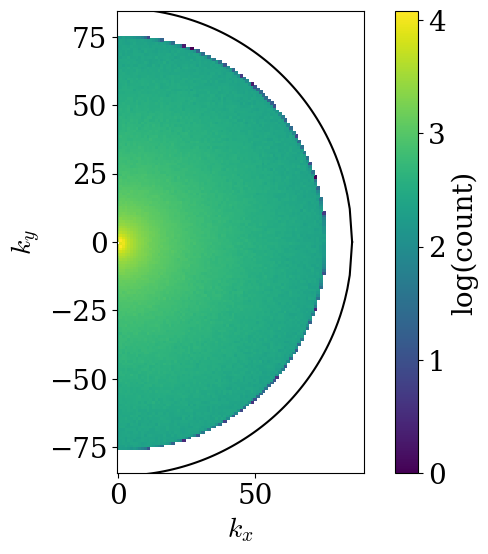

In [7]:
plt.figure(figsize=(8,6))
k_vecs = np.array(k_vecs)
h,xedges,yedges = np.histogram2d(k_vecs[:,0],k_vecs[:,1],bins=(np.arange(kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(0,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
# plt.xlim(0,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.show()

/tmp/ipykernel_30180/3527285363.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


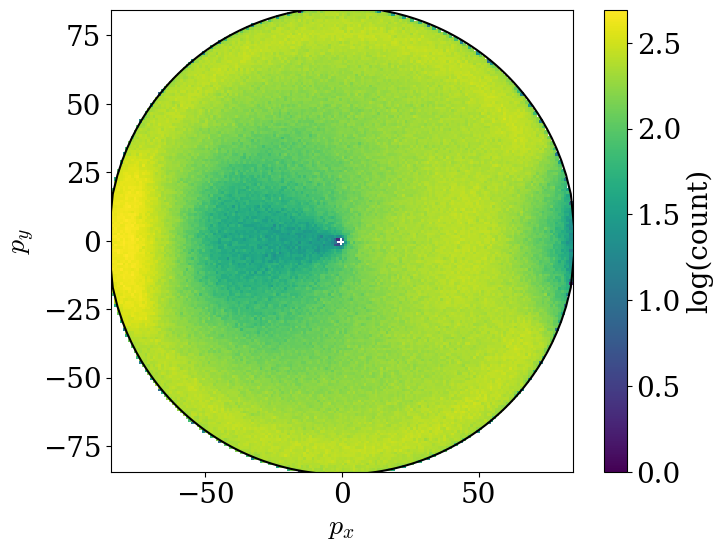

In [8]:
plt.figure(figsize=(8,6))
p_vecs = np.array(p_vecs)
h,xedges,yedges = np.histogram2d(p_vecs[:,0],p_vecs[:,1],bins=(np.arange(-kmax,kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(-kmax,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
plt.xlim(-kmax+1,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.show()

/tmp/ipykernel_30180/3764088242.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


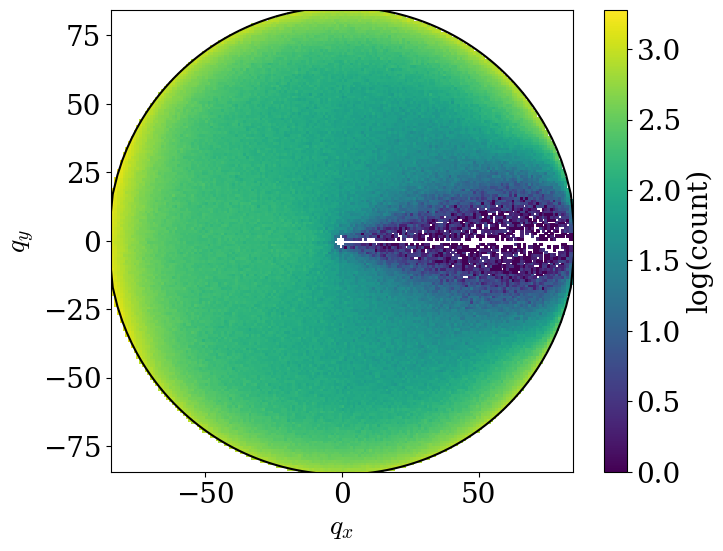

In [9]:
plt.figure(figsize=(8,6))
q_vecs = np.array(q_vecs)
h,xedges,yedges = np.histogram2d(q_vecs[:,0],q_vecs[:,1],bins=(np.arange(-kmax,kmax),np.arange(-kmax,kmax)))
h[h==0]=np.nan
xdiff = np.unique(np.diff(xedges))[0]/2
ydiff = np.unique(np.diff(yedges))[0]/2
xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log10(h.T),vmin=0)
xplt = np.linspace(-kmax,kmax,100)
plt.colorbar(label='log(count)')
plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
plt.gca().set_aspect(1)
plt.xlim(-kmax+1,kmax-1)
plt.ylim(-kmax+1,kmax-1)
plt.xlabel(r'$q_x$')
plt.ylabel(r'$q_y$')
plt.show()

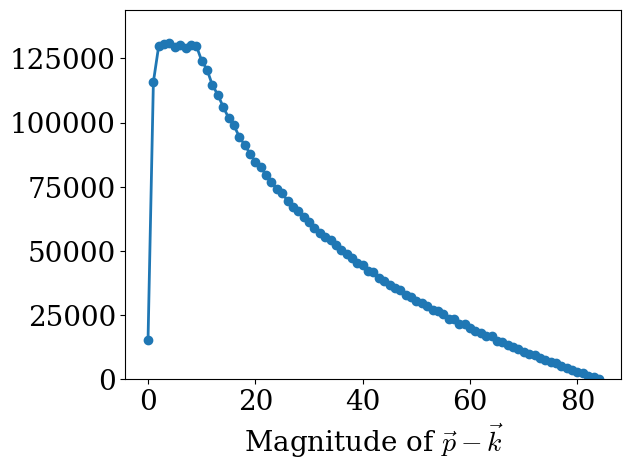

In [10]:
# Histogram
# q = k_vecs[:,0]
q = np.array(Ps)
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2,ls='-',marker='o')
plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,9)
plt.xlabel(r'Magnitude of $\vec{p}-\vec{k}$')
plt.show()

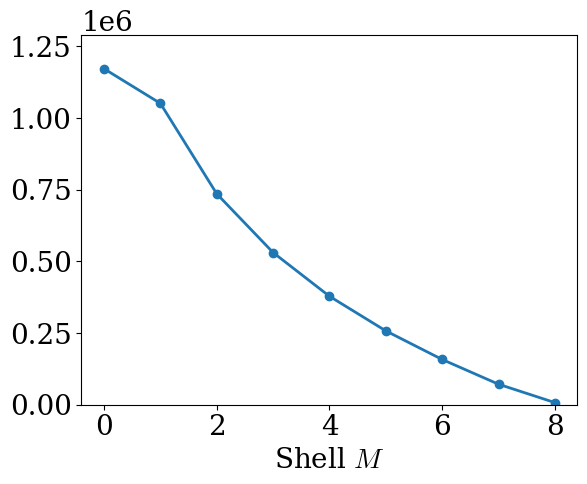

In [11]:
# Histogram
# q = k_vecs[:,0]
q = np.floor(np.array(Ps)/10)
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2,ls='-',marker='o')
plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,9)
plt.xlabel(r'Shell $M$')
plt.show()

In [11]:
print(np.mean(ratio1),np.mean(ratio2))

1.117351613581274 1.2803911498605356


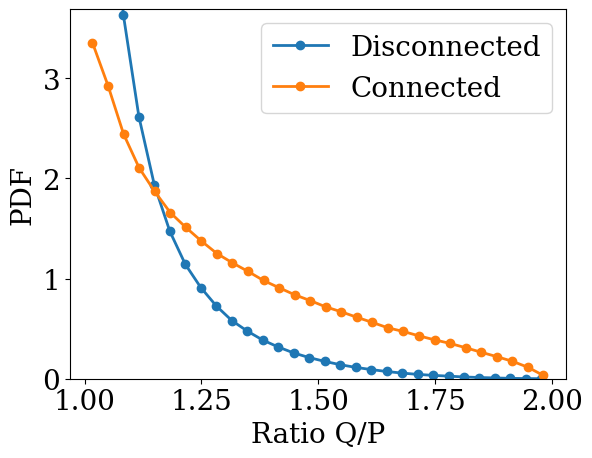

In [12]:
# Histogram
q = np.array(ratio1)
nn, bins = np.histogram(q, bins=30,density=True)
maxnn = np.max(nn)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2,ls='-',marker='o',label='Disconnected')
q = np.array(ratio2)
nn, bins = np.histogram(q, bins=30,density=True)
maxnn = np.max([maxnn,np.max(nn)])
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2,ls='-',marker='o',label='Connected')
plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,9)
plt.legend()
plt.xlabel(r'Ratio Q/P')
plt.ylabel('PDF')
plt.show()

In [125]:
M_max

17

/tmp/ipykernel_30180/3265118542.py:10: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log10(hist)')


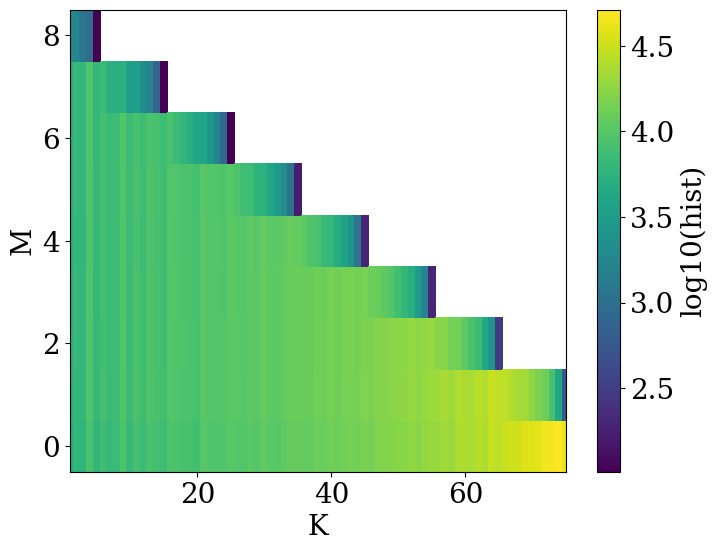

In [13]:
# (int(kmax_int-1),P_max+1)
plt.figure(figsize=(8,6))
Kplt = np.arange(1,kmax_int-10+2)
K_edges = np.concatenate([[Kplt[0]-0.5],Kplt+0.5])
Pplt = np.arange(M_max)
P_edges = np.concatenate([[Pplt[0]-0.5],Pplt+0.5])
K_edges,P_edges = np.meshgrid(K_edges,P_edges,indexing='ij')
hist[hist==0.0] = np.nan
plt.pcolor(K_edges,P_edges,np.log10(hist))
plt.colorbar(label='log10(hist)')
plt.xlim(1,kmax_int-10)
plt.xlabel('K')
plt.ylabel('M')
plt.show()

/tmp/ipykernel_30180/2846321577.py:20: RuntimeWarning: divide by zero encountered in log
  plt.pcolor(xedges,yedges,np.log(h.T),vmin=0)
/tmp/ipykernel_30180/2846321577.py:23: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='log(count)')


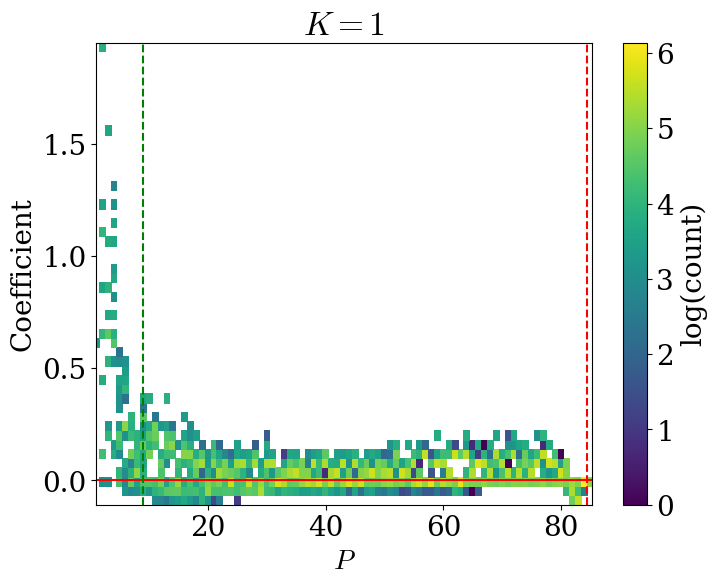

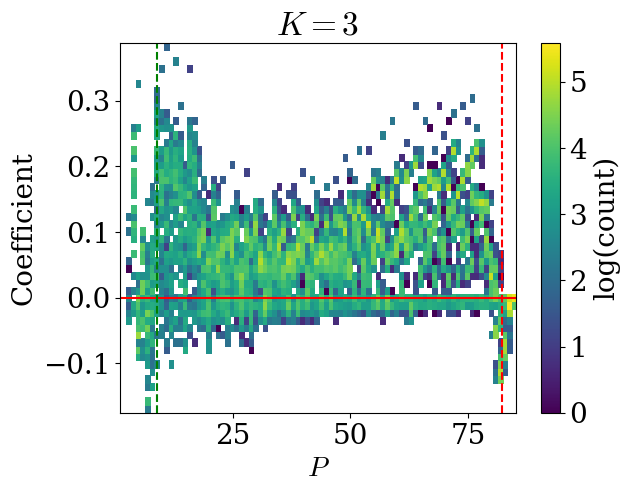

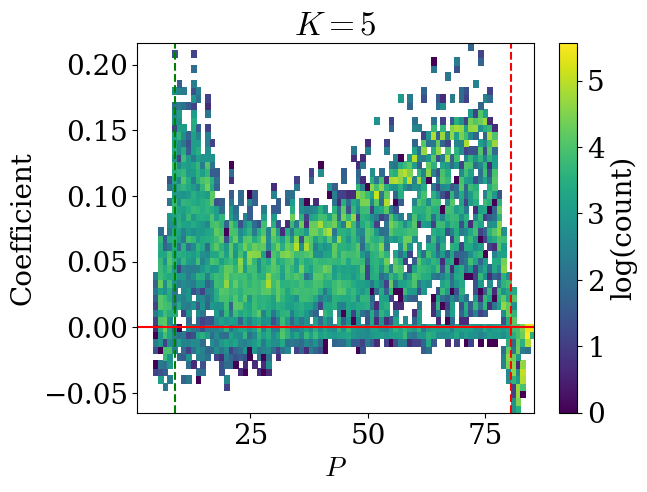

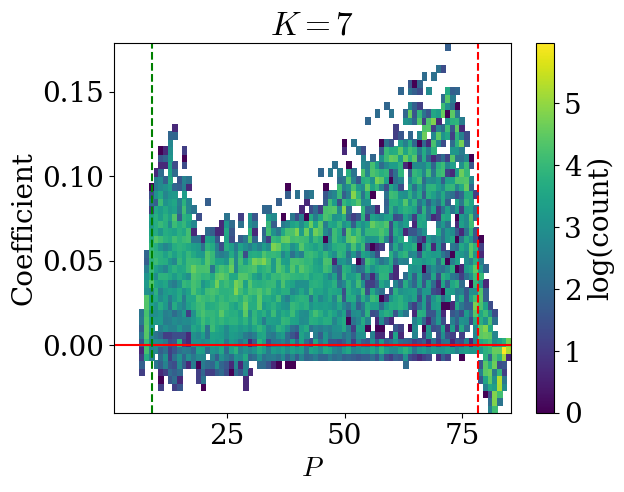

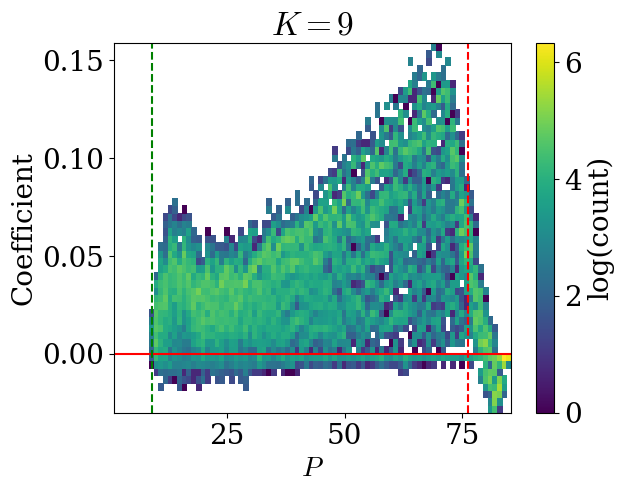

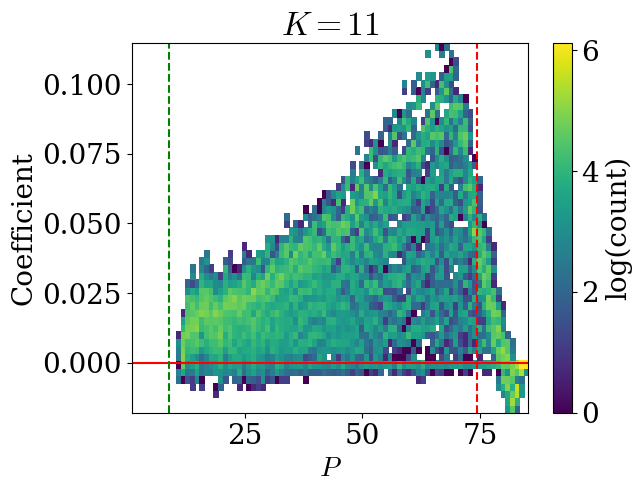

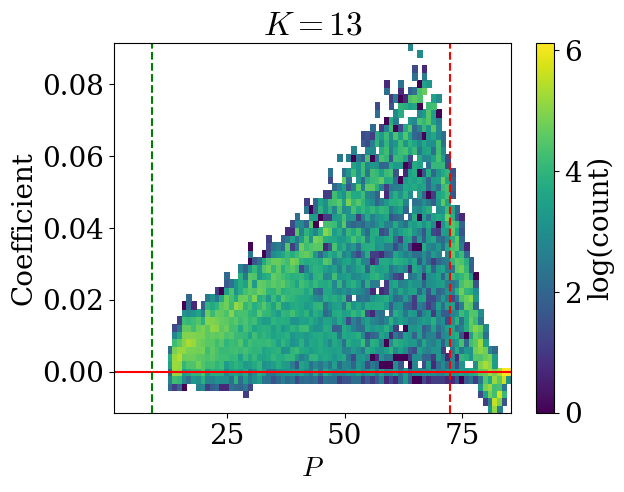

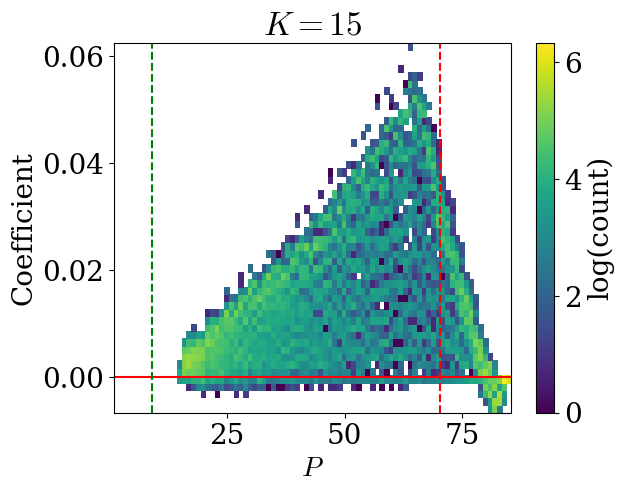

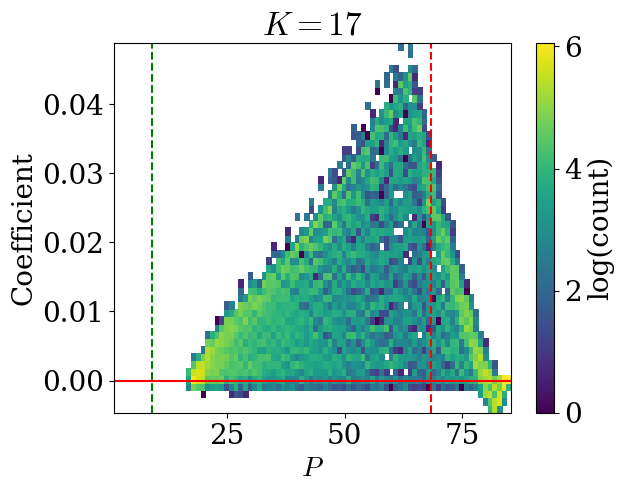

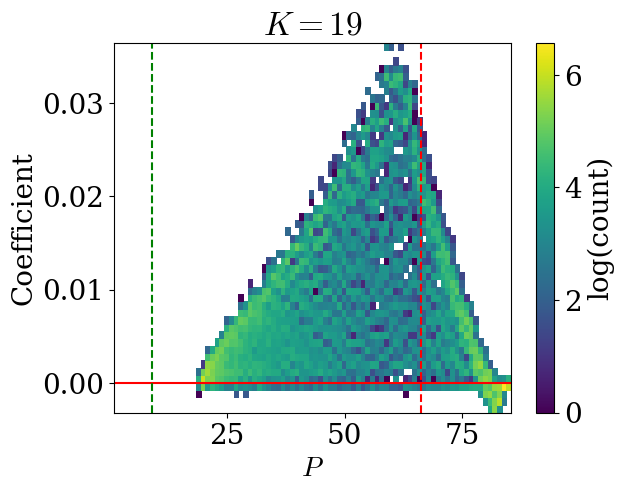

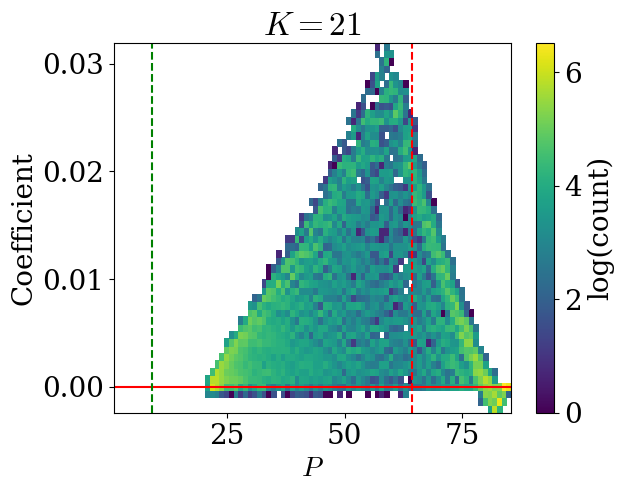

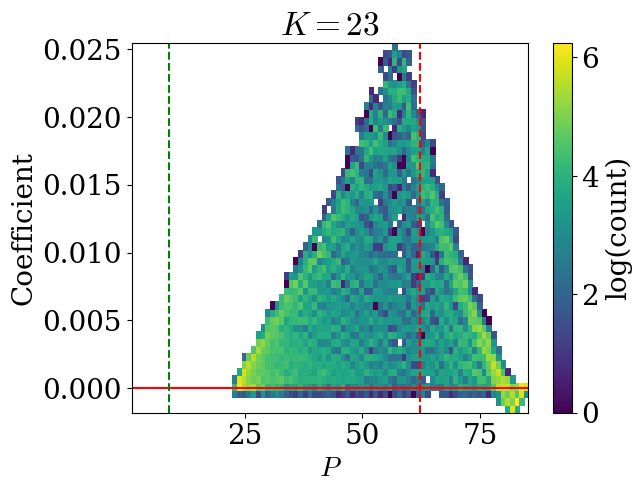

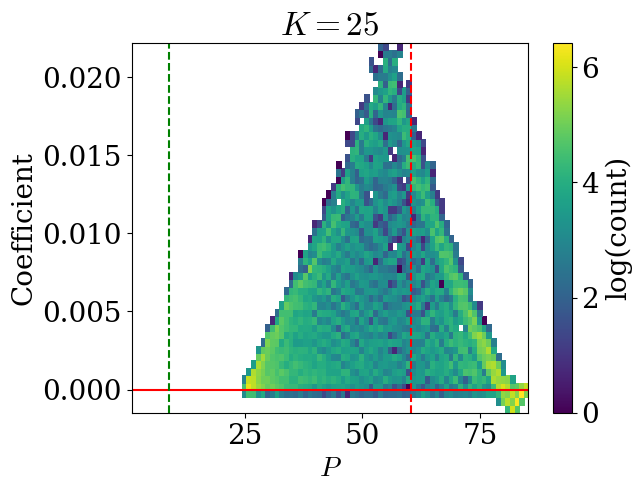

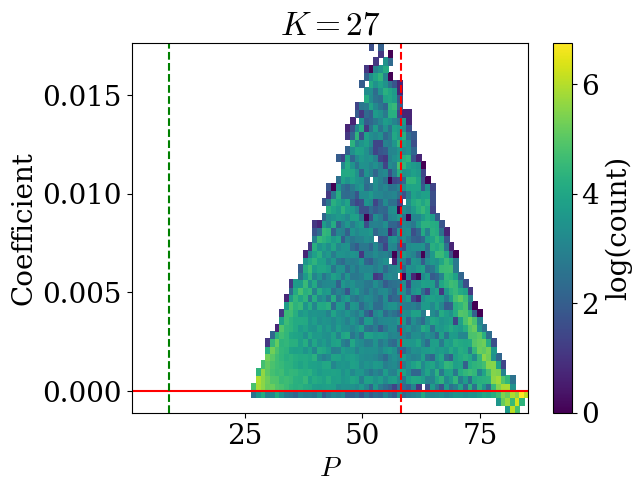

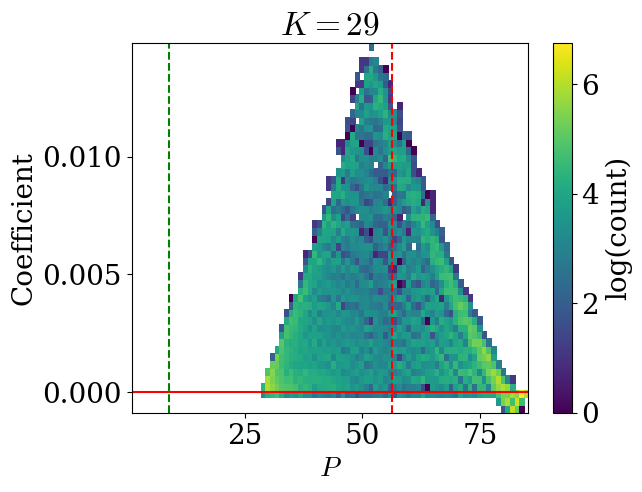

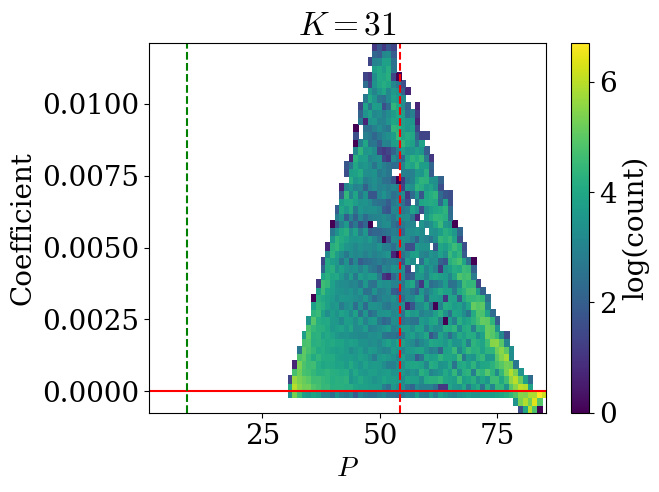

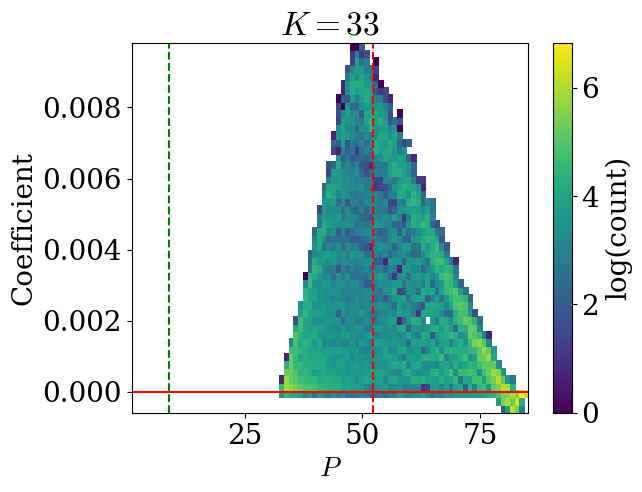

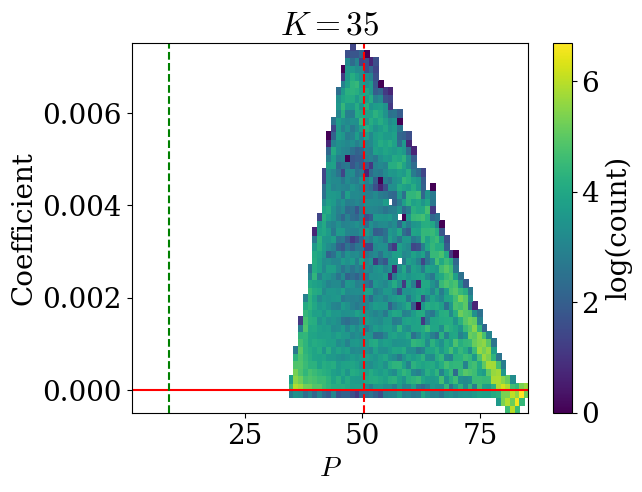

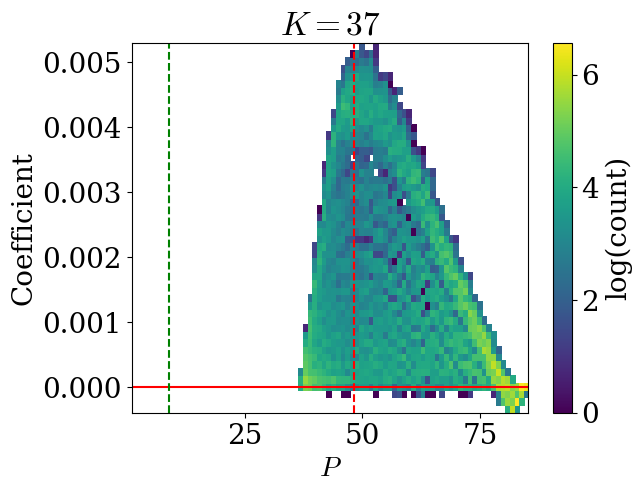

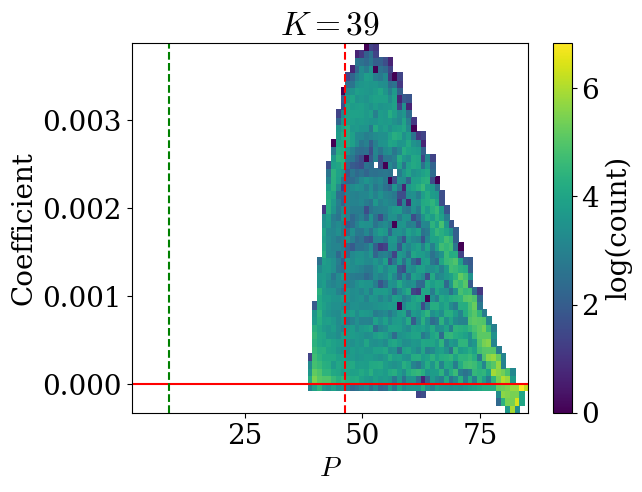

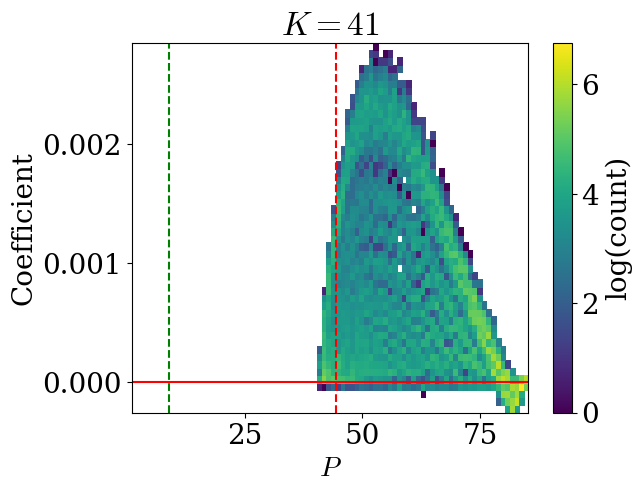

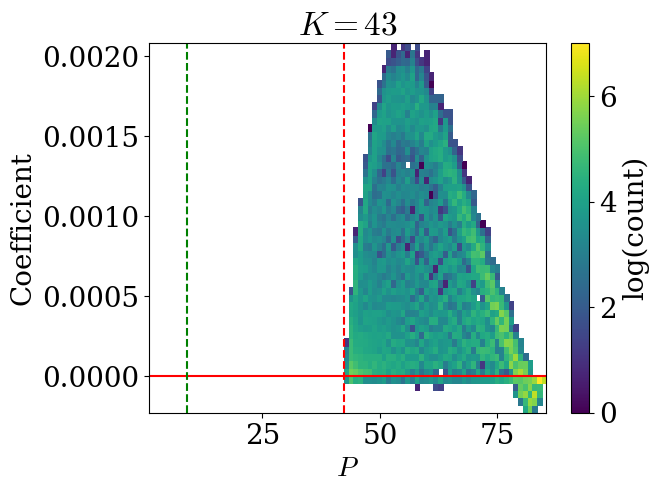

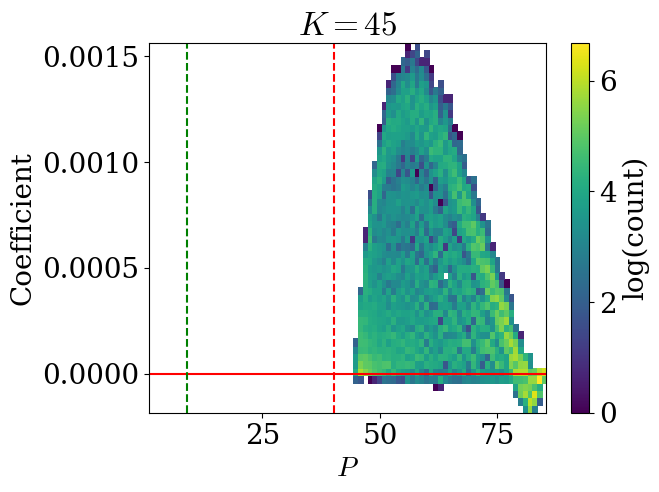

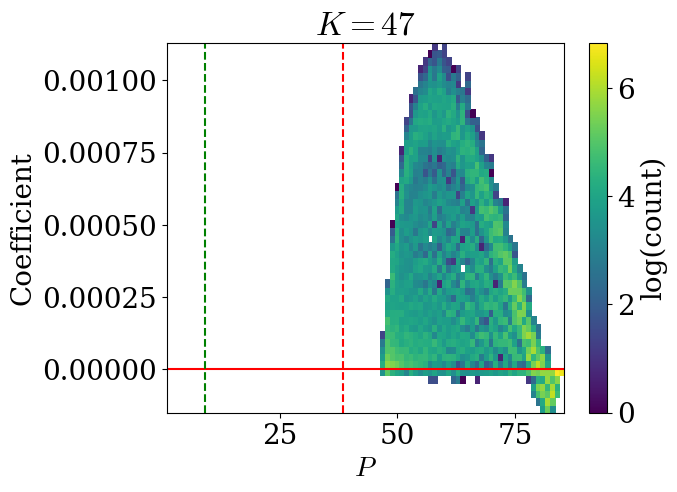

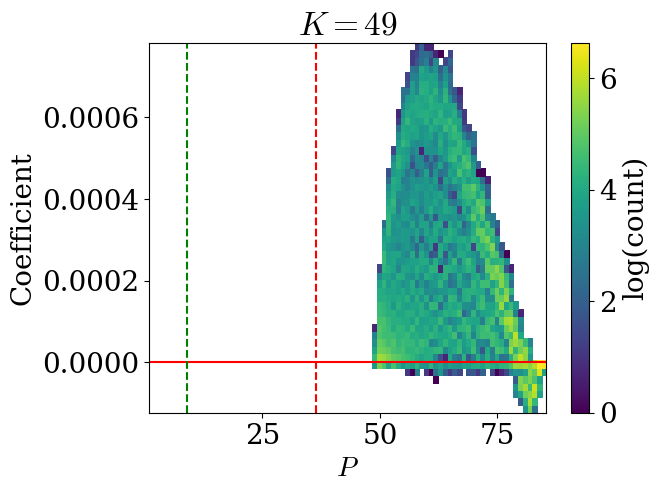

In [14]:
plt.figure(figsize=(8,6))
Ks = np.array(Ks)
Ps = np.array(Ps)
q = Ps+Ks
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
pbins = np.arange(left_of_first_bin, right_of_last_bin + d, d)
term = np.array(term)
# term_bins = np.linspace(-0.3,1.5,50)
term_bins = 50
# Kcheck = 10.0
for Kcheck in np.arange(1,50,2):
    h,xedges,yedges = np.histogram2d(q[Ks==Kcheck],term[Ks==Kcheck],bins=(pbins,term_bins))
    xdiff = np.unique(np.diff(xedges))[0]/2
    ydiff = np.unique(np.diff(yedges))[0]/2
    xedges_c = np.concatenate([[xedges[0]-xdiff],xedges+xdiff])
    yedges_c = np.concatenate([[yedges[0]-ydiff],yedges+ydiff])
    # plt.pcolor(xedges_c[:-1],yedges_c[:-1],np.log(h.T),vmin=0)
    plt.pcolor(xedges,yedges,np.log(h.T),vmin=0)
    plt.axhline(y=0,c='r',ls='-')
    # xplt = np.linspace(-kmax,kmax,100)
    plt.colorbar(label='log(count)')
    # plt.plot(xplt,np.sqrt((kmax)**2-xplt**2),'-k')
    # plt.plot(xplt,-np.sqrt((kmax)**2-xplt**2),'-k')
    # plt.gca().set_aspect(1)
    # plt.xlim(-kmax+1,kmax-1)
    # plt.ylim(-kmax+1,kmax-1) 
    # plt.axvline(x=n/3-Kcheck,c='r',ls='--') # P = P_diff + K = K_max
    # plt.axvline(x=np.max([0.0,n/3-2*Kcheck]),c='r',ls='--')  # Q = P+K = P_diff + 2*K = K_max
    plt.xlim(1,n/3)
    plt.axvline(x=np.max([0.0,n/3-Kcheck]),c='r',ls='--')  # Q = P+K = P_diff + 2*K = K_max
    plt.axvline(x=9,c='g',ls='--')  # Q = P+K = P_diff + 2*K = K_max
    # plt.axvline(x=65,c='r',ls='--')  # Q = P+K = P_diff + 2*K = K_max
    plt.xlabel(r'$P$')
    plt.ylabel(r'Coefficient')
    plt.title(r'$K = %s$' % Kcheck)
    plt.show()

In [148]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

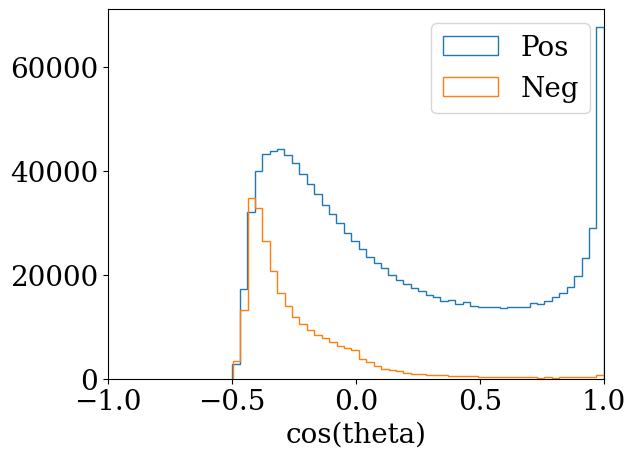

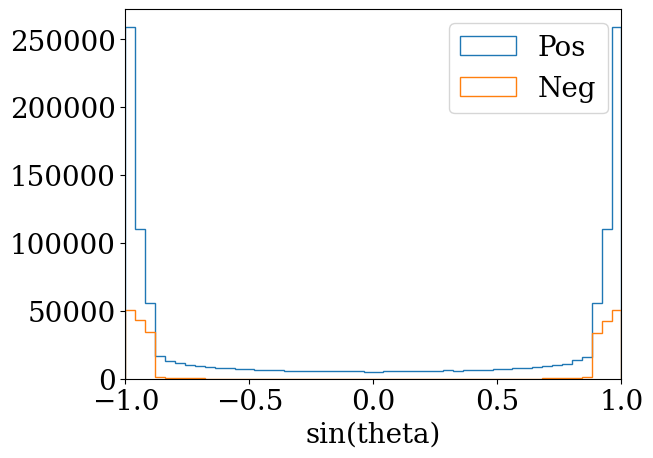

In [149]:
labels = ['Pos','Neg']
for ii,cond in enumerate([term>0,term<0]):
    dot = k_vecs[cond,0]*p_vecs[cond,0] + k_vecs[cond,1]*p_vecs[cond,1]
    cross = k_vecs[cond,0]*p_vecs[cond,1] - k_vecs[cond,1]*p_vecs[cond,0]
    if np.any(cross==0.0):
        print('hey')
    kkmag = k_vecs[cond,0]*k_vecs[cond,0] + k_vecs[cond,1]*k_vecs[cond,1]
    ppmag = p_vecs[cond,0]*p_vecs[cond,0] + p_vecs[cond,1]*p_vecs[cond,1]
    plt.figure(1)
    plt.hist(dot/np.sqrt(ppmag*kkmag),histtype='step',bins=50,label = labels[ii])
    plt.figure(2)
    plt.hist(cross/np.sqrt(ppmag*kkmag),histtype='step',bins=50,label = labels[ii])
plt.figure(1)
plt.xlabel("cos(theta)")
plt.xlim(-1,1)
plt.legend()
plt.figure(2)
plt.xlabel("sin(theta)")
plt.xlim(-1,1)
plt.legend()

plt.show()

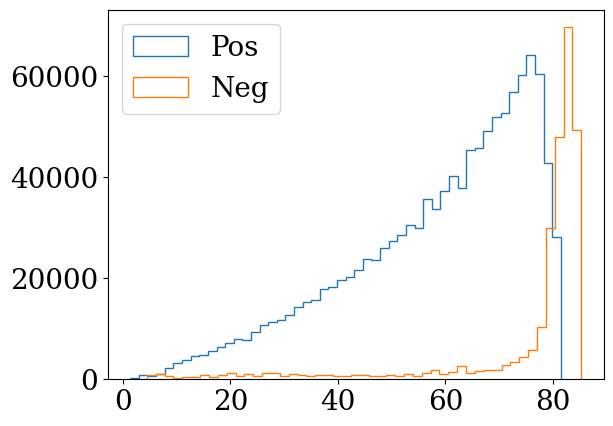

In [152]:
labels = ['Pos','Neg']
for ii,cond in enumerate([term>0,term<0]):
    dot = k_vecs[cond,0]*p_vecs[cond,0] + k_vecs[cond,1]*p_vecs[cond,1]
    cross = k_vecs[cond,0]*p_vecs[cond,1] - k_vecs[cond,1]*p_vecs[cond,0]
    if np.any(cross==0.0):
        print('hey')
    kkmag = np.sqrt(k_vecs[cond,0]**2 + k_vecs[cond,1]**2)
    ppmag = np.sqrt(p_vecs[cond,0]**2 + p_vecs[cond,1]**2)
    qqmag = np.sqrt((-p_vecs[cond,0]-k_vecs[cond,0])**2 + (-p_vecs[cond,1]-k_vecs[cond,1])**2)
    plt.figure(1)
    plt.hist(ppmag,histtype='step',bins=50,label = labels[ii])
    # plt.figure(2)
    # plt.hist(cross/np.sqrt(ppmag*kkmag),histtype='step',bins=50,label = labels[ii])
plt.figure(1)
# plt.xlabel("cos(theta)")
# plt.xlim(-1,1)
plt.legend()
# plt.figure(2)
# plt.xlabel("sin(theta)")
# plt.xlim(-1,1)
# plt.legend()

plt.show()

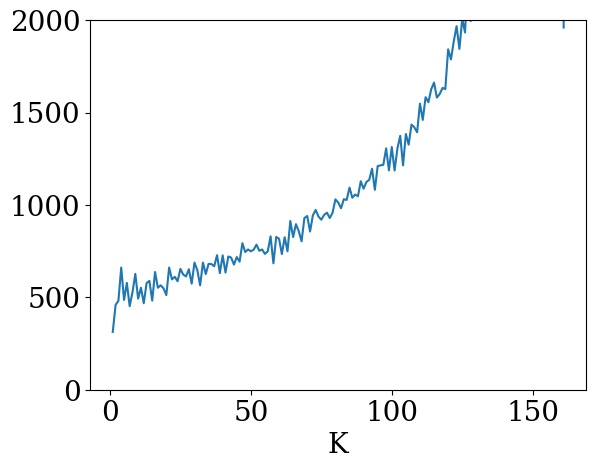

In [113]:
plt.plot(Kplt,hist[:,0])
plt.xlabel('K')
plt.ylim(0,2000)
# xplt = np.linspace(1,n/2,1000)
# plt.plot(xplt,5*xplt,'--r')
# plt.plot(xplt,44*(xplt)**1.75,'-b')
# plt.ylim(0,200)#np.max(np.sum(hist,axis=1)))
# plt.xlim(1,30)
plt.show()

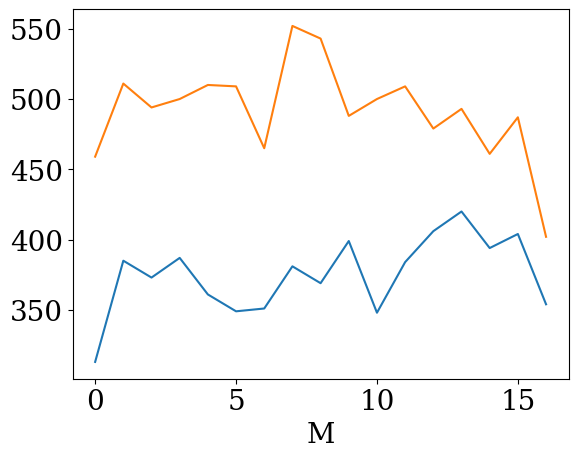

In [114]:
plt.plot(Pplt,hist.T[:,:2])
plt.xlabel('M')
# xplt = np.linspace(1,n/2,1000)
# plt.plot(xplt,5*xplt,'--r')
# plt.plot(xplt,44*(xplt)**1.75,'-b')
# plt.ylim(0,200)#np.max(np.sum(hist,axis=1)))
# plt.xlim(1,30)
plt.show()

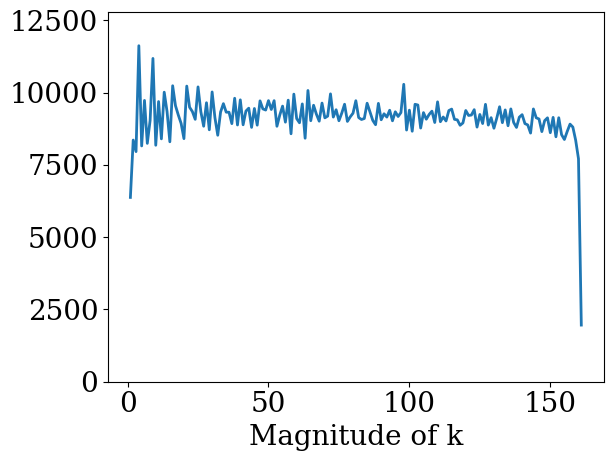

In [115]:
# Histogram
# q = k_vecs[:,0]
q = np.array(Ks)
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
plt.plot((np.diff(bins)/2+bins[:-1]),nn,lw=2)
plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,10)
plt.xlabel('Magnitude of k')
plt.show()

## For tests

/tmp/ipykernel_32353/4125595093.py:39: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_32353/4125595093.py:40: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


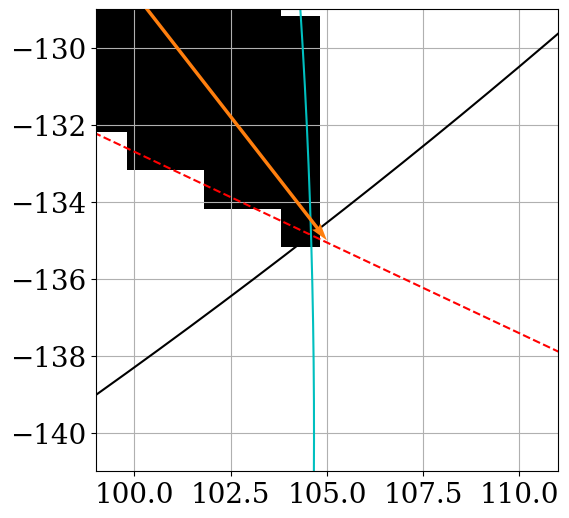

In [15]:
# kt = np.arange(-kmax,kmax)
# kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
# # kt = np.linspace(-kmax,kmax,200)
# KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
# KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
# cond1 = ((KTX**2 + KTY**2) > kmag**2)
# if kx==0:
#     if ky>0:
#         cond2 = (KTY > -ky/2)
#     else:
#         cond2 = (KTY < -ky/2)
# else:
#     cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
# cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
# QX = -kx - KTX
# QY = -ky - KTY
# # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
# cond4 = ((QX**2 + QY**2) < kmax**2)
# plt.figure(figsize=(8,6))
# plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
# xplt = np.linspace(-kmax,kmax,5000)
# if kx == 0:
#         plt.axhline(y = -ky/2)
# else:
#     plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
# plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
# plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
# plt.plot(xplt[np.abs(xplt)<(kmax-0)], np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
# plt.plot(xplt[np.abs(xplt)<(kmax-0)], -np.sqrt((kmax-0)**2-xplt[np.abs(xplt)<(kmax-0)]**2),'-k')
# # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
# # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
# # plt.axvline(x = -kmax-kx,ls='-',c='c')
# # plt.axvline(x = kmax-kx,ls='-',c='c')
# # plt.axhline(y = kmax-ky,ls='-',c='c')
# # plt.axhline(y = -kmax-ky,ls='-',c='c')
# a = 1
# b = 2*kx
# c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
# solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
# soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
# plt.plot(solp,xplt,'-c')
# plt.plot(soln,xplt,'-c')
# # plt.axhline(y = minp+1,ls='--',c='y')
# # plt.axhline(y = maxp-1,ls='--',c='y')
# # plt.axvline(x = minp2+1,ls='--',c='orange')
# # plt.axvline(x = maxp2,ls='--',c='orange')
# # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
# # V = np.array([[kx,ky],[px_old,py_old],[qx,qy],[px,py],[mag_p*np.cos(theta_p),mag_p*np.sin(theta_p)]])
# # V = np.array([[px,py],[px1,py1],[px2,py2],[px3,py3],[px4,py4]])
# # origin = np.array([[0,0,0,0,0],[0,0,0,0,0]]) # origin point
# V = np.array([[kx,ky],[px,py],[qx,qy]])
# origin = np.array([[0,0,0],[0,0,0]]) # origin point
# plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green','tab:red','tab:purple'], angles='xy', scale_units='xy', scale=1,zorder=10)

# plt.grid()
# plt.gca().set_aspect(1)
# plt.xlim(-kmax-1,kmax+1)
# plt.ylim(-kmax-1,kmax+1)
# plt.xlim(px-6,px+6)
# plt.ylim(py-6,py+6)
# # plt.xlim(px-5,55)
# # plt.ylim(py-5,-155)
# plt.show()

# Fixed triads (phase only) OLD
Generation of triad list

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 13095.24it/s]
/tmp/ipykernel_1207748/3257997077.py:170: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_1207748/3257997077.py:171: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


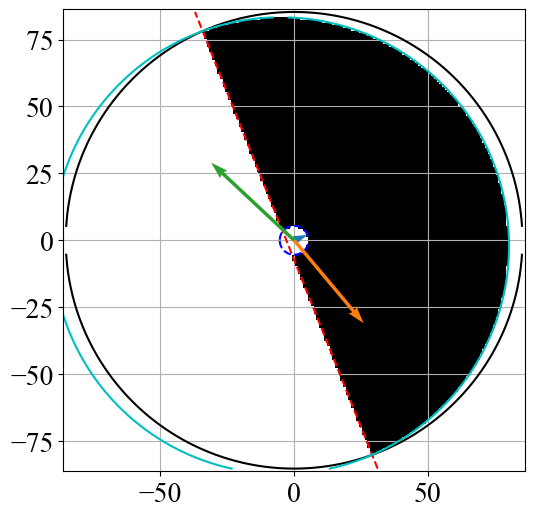

In [17]:
n = 256
N_shells = 10.0
M_max = np.int32(np.round(n/3.0/N_shells))
Ntriads = 100000
kmax = n/3
kmax_int = np.int32(np.floor(kmax))
# Choose K_min. K_min = 1 if to be used for phase_only, and K_min = 5 for full models (avoiding hypodissipation range)
K_min = 1
# Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
K_lim = int(np.round(kmax/2)) # using /8 for phase only, /4 in full model?
P_lim = kmax_int #int(np.round(kmax/2))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []
hist = np.zeros((int(kmax_int-N_shells+1),M_max))

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    mag_k = np.random.randint(K_min,K_lim)
    # mag_k = np.random.uniform(1,kmax-N_shells) # So at least one shell is represented for the last K
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=(n/3):
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=(n/3):
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    # Group into shells of 10 wavenumbers
    # print(kx,ky,px,py,kmag,pmag)
    # print(pmag-kmag,np.round(pmag-kmag),np.round(pmag-kmag) % 10)
    M_loc = np.floor((pmag-kmag)/N_shells)
    hist[int(np.round(kmag)-1),int(M_loc)]+=1 # kmag-1 so that first index is K = 1

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    # term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    # term.append(term_tmp)
    Ks.append(kmag)
    Ps.append(pmag) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [18]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [19]:
k_vecs.shape

(98599, 2)

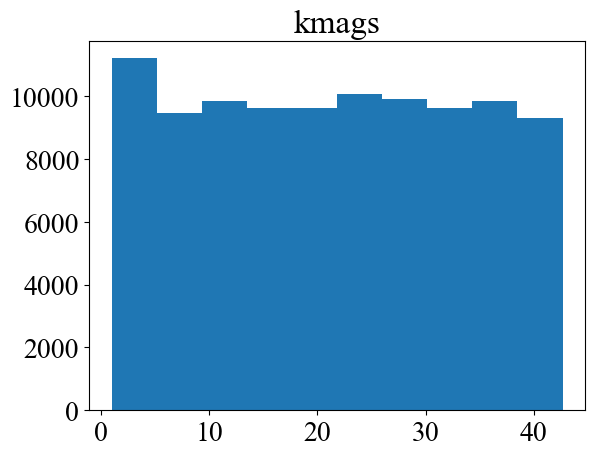

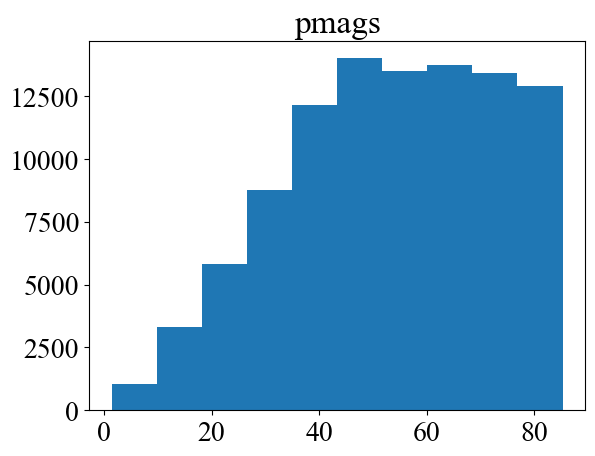

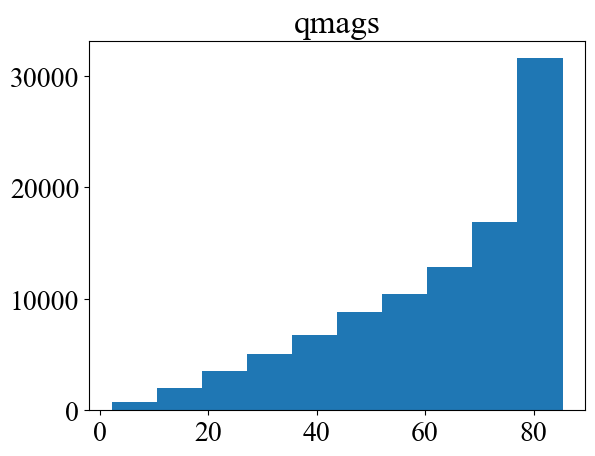

In [20]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

In [19]:
a = 2
f01 = 8
nu1 = 2.5e-7
hnu1 = 0.70710678

print(a*f01,a**(1-2*2)*nu1,a**(1/2)*hnu1)

16 3.125e-08 0.9999999983219685


In [18]:
a = 2
f01 = 4
nu1 = 2e-6
hnu1 = 0.5

print(a*f01,a**(1-2*2)*nu1,a**(1/2)*hnu1)

8 2.5e-07 0.7071067811865476


Create a unique list of triads 
Because many are likely duplicated

In [21]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(98599, 4)


In [22]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(97517, 4)


In [23]:
triads_unique

array([[  0.,   1., -84.,   7.],
       [  0.,   1., -82.,  21.],
       [  0.,   1., -78.,  31.],
       ...,
       [ 42.,   6.,  29., -47.],
       [ 42.,   6.,  30., -40.],
       [ 42.,   6.,  40., -22.]])

In [24]:
k_vecs_unique = np.unique(k_vecs,axis=0)
print(k_vecs_unique.shape)
p_vecs_unique = np.unique(p_vecs,axis=0)
print(p_vecs_unique.shape)
q_vecs_unique = np.unique(q_vecs,axis=0)
print(q_vecs_unique.shape)

(1470, 2)
(17390, 2)
(15006, 2)


In [11]:
# plt.figure()
# plt.title('k_vecs')
# for triad in k_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:orange')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('p_vecs')
# for triad in p_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:blue')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('q_vecs')
# for triad in q_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:green')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

Now we apply scaling and creat a new list

In [25]:
triads_full = []
as_full = []
nums_l = []
count = 1
for triad in triads_unique[:,:]:
    # The limiting factor will be q, so we first define this
    [qx,qy]=[-triad[0]-triad[2],-triad[1]-triad[3]]
    qmax = np.max([np.abs(qx),np.abs(qy)])
    nums = int(np.floor(np.log2(n/qmax/3)))+1
    nums_l.append(nums)
    for ii in range(nums):
        triad_tmp = triad*2**(ii)
        kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
        pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
        qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
        if (kmag>=n/3) or (pmag>=n/3) or (qmag>=n/3):
            print("TRIAD IS LARGER THAN KMAX. SKIPPING.")
            print(triad_tmp, 2**(ii))
        else:
            triads_full.append(triad*2**(ii))
            as_full.append(2**(ii))
    # print('-------------')
    # print(qmax)
    # print(nums)
    # print('kx',[kx*2**(ii) for ii in range(nums)])
    # print('ky',[ky*2**(ii) for ii in range(nums)])
    # print('px',[px*2**(ii) for ii in range(nums)])
    # print('py',[py*2**(ii) for ii in range(nums)])
    # print('qx',[qx*2**(ii) for ii in range(nums)])
    # print('qy',[qy*2**(ii) for ii in range(nums)])

triads_full = np.array(triads_full)
as_full = np.array(as_full)


TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -84.  22.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -82.  30.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -82.  58.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -80.  76.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -78.  48.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -78.  60.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -78.  68.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -76.  52.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -76.  64.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -74.  56.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -74.  62.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -72.  44.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -72.  60.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -70.  56.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -70.  60.] 2
TRIAD IS LARGER THAN KMAX. SKIPPING.
[  0.   2. -66.  68.] 2
TRIAD IS LARGER THAN KMA

In [26]:
print(triads_full.shape)
print(np.max(as_full),np.argmax(as_full))

(118194, 4)
32 587


In [27]:
print(triads_full.shape)
print(np.max(as_full),np.argmax(as_full))

(118194, 4)
32 587


In [28]:
triads_full[593-5:593+1]

array([[  0.,   1.,  -2.,   1.],
       [  0.,   2.,  -4.,   2.],
       [  0.,   4.,  -8.,   4.],
       [  0.,   8., -16.,   8.],
       [  0.,  16., -32.,  16.],
       [  0.,   1.,  -2.,   2.]])

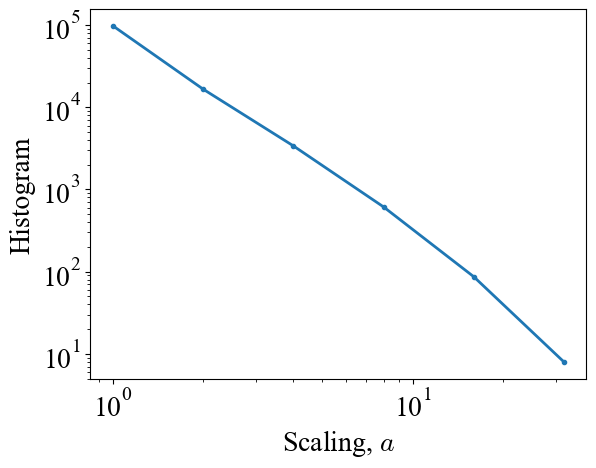

In [29]:
# Histogram
# q = k_vecs[:,0]
q = as_full
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
bins_c = (np.diff(bins)/2+bins[:-1])
# nn[nn==0]=np.nan
plt.loglog(bins_c[nn!=0],nn[nn!=0],'.-',lw=2,)
# plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,10)
plt.ylabel('Histogram')
plt.xlabel('Scaling, $a$')
plt.show()

In [30]:
# np.savetxt('triads_full_%i_phase.txt' % n, triads_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

In [31]:
# np.savetxt('as_full_%i_phase.txt' % n, as_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

### Picking 12 for time-series sampling

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 1495.56it/s]
/tmp/ipykernel_2015428/217898951.py:162: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_2015428/217898951.py:163: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


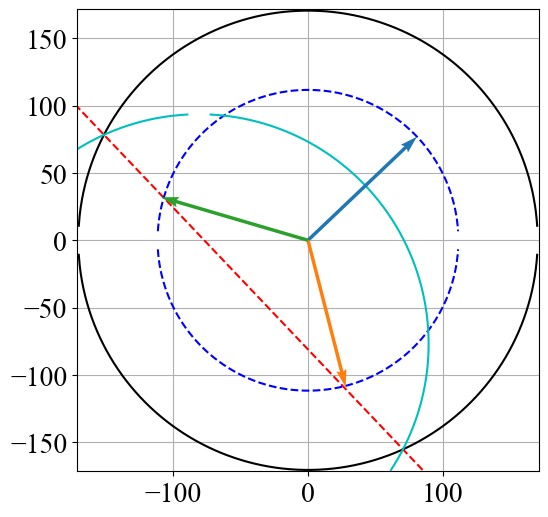

In [18]:
n = 512
N_shells = 6 # Based on the number of shells we're interested in sampling (will look at 2 random triads per shell)
kmax = n/3
Kbins = np.logspace(np.log10(6),np.log10(kmax),N_shells)
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for shell in tqdm.tqdm(range(N_shells)):
    ntriad = 0
    while ntriad<2:
        count+=1
        ##################
        ## Choose k vector
        # Random theta
        theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
        # Random magnitude
        # Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
        K_lim = np.min([kmax,Kbins[shell]])
        if shell>0:
            # K_min = np.max([0.5,Kbins[shell-1]]) # for phase
            K_min = np.max([5,Kbins[shell-1]])
        else:
            K_min = 5
        # mag_k = np.random.randint(K_min,K_lim)
        mag_k = np.random.uniform(K_min,K_lim) # So at least one shell is represented for the last K
        kx = np.round(mag_k*np.cos(theta_k))  # kx
        ky = np.round(mag_k*np.sin(theta_k)) # ky
        kmag = np.sqrt(kx**2 + ky**2)
        
        ##################
        ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
        ########
        rad_lim = np.min([kmax,P_lim])
        # Choose a random radius between kmag and rad_lim
        mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
        # Intersection of P < Q line and mag_p circle
        theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
        theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
        if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
            # Intersection of Q < kmax curve and mag_p circle
            theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            pos = np.random.randint(0,high = 2) # Choose a branch
            if pos==0: # neg
                low = theta_PQ_neg
                high = theta_kmax_neg
            else: # pos
                low=theta_kmax_pos
                high=theta_PQ_pos
        else:
            low=theta_PQ_neg
            high=theta_PQ_pos
        # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
        theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
        px = np.round(mag_p*np.cos(theta_p))  # px
        py = np.round(mag_p*np.sin(theta_p)) # py
        
        ####### Check and correct for discreteness effects
        # count_e = 1
        # good = False
        # while not good:
        #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
        #     count_e += 1
        pmag = np.sqrt(px**2+py**2)
        # Finally, find qx,qy
        qx = -kx -px
        qy = -ky -py
        qmag = np.sqrt(qx**2 + qy**2)
    
        cross = (kx*py)-(ky*px)
        if cross==0:
            count_wrong_1 += 1
            # print('------cross = 0')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
    
        if qmag>=(n/3):
            count_wrong_2 += 1
            print('---- (qx,qy) is outside the dealiased grid! ----')
            continue
    
        if pmag>=(n/3):
            count_wrong_3 += 1
            # print('---- (px,py) is outside the dealiased grid! ----')
            continue
        
        if qmag<pmag:
            count_wrong_4+=1
            # print('------qmag<pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
        
        if kmag>=pmag:
            count_wrong_5 += 1
            # print('------ kmag = pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue

        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ntriad += 1
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [19]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [20]:
Ks

[np.float64(5.830951894845301),
 np.float64(6.082762530298219),
 np.float64(7.211102550927978),
 np.float64(7.615773105863909),
 np.float64(13.892443989449804),
 np.float64(17.26267650163207),
 np.float64(38.3275357934736),
 np.float64(25.80697580112788),
 np.float64(79.92496481075234),
 np.float64(63.51377803280167),
 np.float64(154.8418548067673),
 np.float64(111.75866856758807)]

In [21]:
k_vecs.shape

(12, 2)

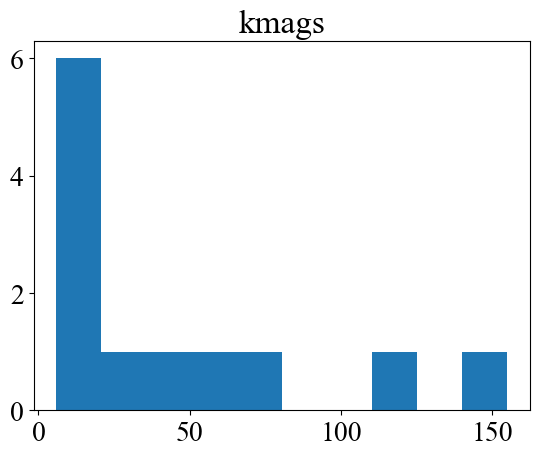

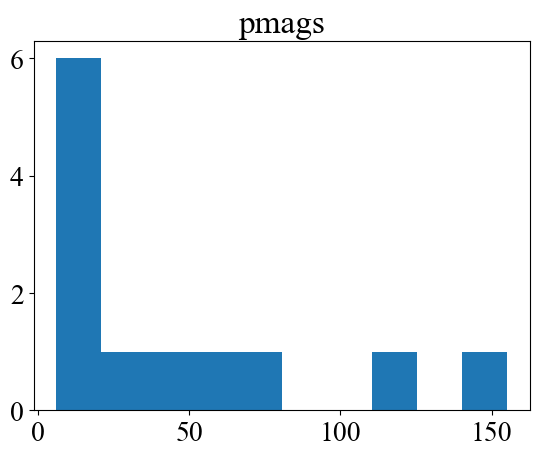

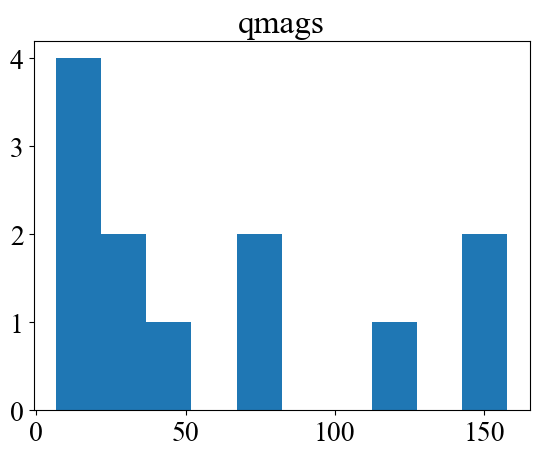

In [22]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

Create a unique list of triads 
Because many are likely duplicated

In [23]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(12, 4)


In [24]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(12, 4)


In [25]:
triads_unique

array([[   3.,    5.,   -6.,    1.],
       [   4.,    6.,   -2.,    7.],
       [   6.,    1.,   -3.,    6.],
       [   7.,    3.,    5.,   -6.],
       [  10.,   37.,   37.,   11.],
       [  12.,    7.,   14.,    3.],
       [  17.,    3.,   17.,    6.],
       [  21.,   15.,   24.,  -11.],
       [  35.,   53.,  -63.,   11.],
       [  42.,   68.,  -26.,   76.],
       [  81.,   77.,   28., -109.],
       [  90.,  126., -154.,   18.]])

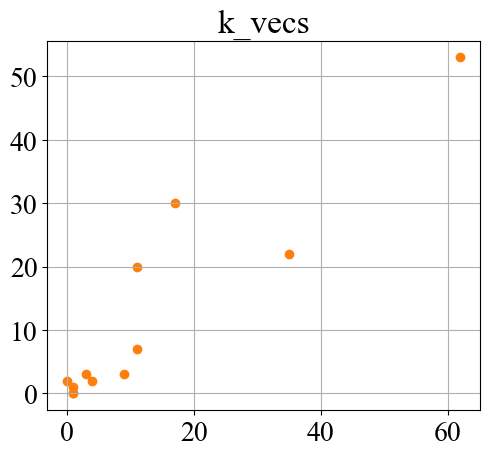

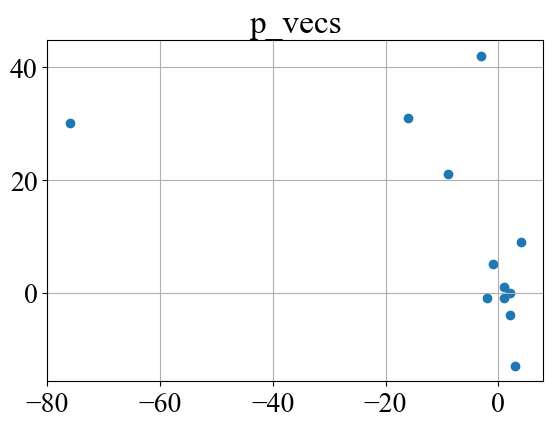

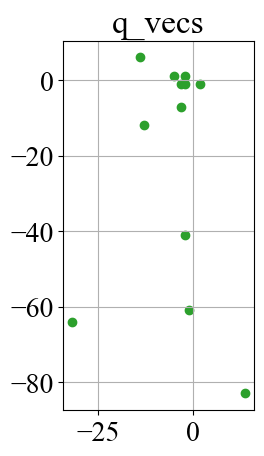

In [43]:
plt.figure()
plt.title('k_vecs')
for triad in triads_unique:
    plt.scatter(triad[0],triad[1],color='tab:orange')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('p_vecs')
for triad in triads_unique:
    plt.scatter(triad[2],triad[3],color='tab:blue')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('q_vecs')
for triad in triads_unique:
    plt.scatter(-triad[0]-triad[2],-triad[1]-triad[3],color='tab:green')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [32]:
# np.savetxt('triads_ts_%i_phase.txt' % n, triads_unique, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

# Fixed triads (full model only) OLD
Generation of triad list

In [5]:
mult = 1
n = 256*mult
Ntriads = 100000
kf = 9*mult
kup = kf+1
kdn = kf-1

#############################
kmax = kf #n/3
kmax_int = np.int32(np.floor(kmax))
# Choose K_min. K_min = 1 if to be used for phase_only, and K_min = 5 for full models (avoiding hypodissipation range)
K_min = 5
# Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
K_lim = kmax_int #int(np.round(kmax/2)) # using /8 for phase only, /4 in full model?
P_lim = kmax_int #int(np.round(kmax/2))

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for Ntr in tqdm.tqdm(range(1,Ntriads+1)):
    count+=1
    ##################
    ## Choose k vector
    # Random theta
    theta_k = np.random.uniform(low=-1,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
    # Random magnitude
    mag_k = np.random.randint(K_min,K_lim)
    kx = np.round(mag_k*np.cos(theta_k))  # kx
    ky = np.round(mag_k*np.sin(theta_k)) # ky
    kmag = np.sqrt(kx**2 + ky**2)
    
    ##################
    ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
    ########
    rad_lim = np.min([kmax,P_lim])
    # Choose a random radius between kmag and rad_lim
    mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
    # Intersection of P < Q line and mag_p circle
    theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
    theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
        # Intersection of Q < kmax curve and mag_p circle
        theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
        pos = np.random.randint(0,high = 2) # Choose a branch
        if pos==0: # neg
            low = theta_PQ_neg
            high = theta_kmax_neg
        else: # pos
            low=theta_kmax_pos
            high=theta_PQ_pos
    else:
        low=theta_PQ_neg
        high=theta_PQ_pos
    # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
    theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
    px = np.round(mag_p*np.cos(theta_p))  # px
    py = np.round(mag_p*np.sin(theta_p)) # py
    
    ####### Check and correct for discreteness effects
    # count_e = 1
    # good = False
    # while not good:
    #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
    #     count_e += 1
    pmag = np.sqrt(px**2+py**2)
    # Finally, find qx,qy
    qx = -kx -px
    qy = -ky -py
    qmag = np.sqrt(qx**2 + qy**2)

    cross = (kx*py)-(ky*px)
    if cross==0:
        count_wrong_1 += 1
        # print('------cross = 0')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if qmag>=kmax:
        count_wrong_2 += 1
        # print('---- (qx,qy) is outside the dealiased grid! ----')
        continue

    if pmag>=kmax:
        count_wrong_3 += 1
        # print('---- (px,py) is outside the dealiased grid! ----')
        continue
    
    if qmag<pmag:
        count_wrong_4+=1
        # print('------qmag<pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue
    
    if kmag>=pmag:
        count_wrong_5 += 1
        # print('------ kmag = pmag')
        # print('kx',kx,'ky',ky,'px',px,'py',py)
        continue

    if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: 
        ratio1.append(qmag/pmag)
    else:
        ratio2.append(qmag/pmag)
    # term_tmp = (((qmag**2-pmag**2)/(kmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(pmag)-1)])/(rho[int(np.round(kmag)-1)])) + ((pmag**2-kmag**2)/(qmag**2))*((rho[int(np.round(pmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(qmag)-1)])) + ((kmag**2-qmag**2)/(pmag**2))*((rho[int(np.round(qmag)-1)]*rho[int(np.round(kmag)-1)])/(rho[int(np.round(pmag)-1)])))
    # term.append(term_tmp)
    Ks.append(kmag)
    Ps.append(pmag) 
    k_vecs.append([kx,ky])
    p_vecs.append([px,py])
    q_vecs.append([qx,qy])
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

NameError: name 'np' is not defined

In [31]:
n

1024

In [32]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [33]:
np.where(k_vecs[:,1]<0)

(array([    1,     5,     6, ..., 87026, 87028, 87030]),)

Create a unique list of triads 
Because many are likely duplicated

In [34]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(87032, 4)


In [35]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(73292, 4)


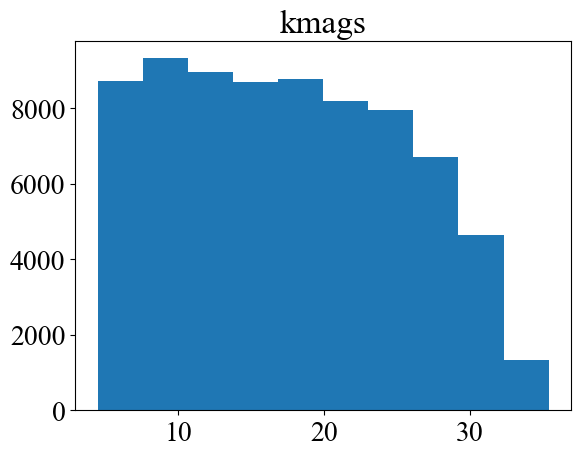

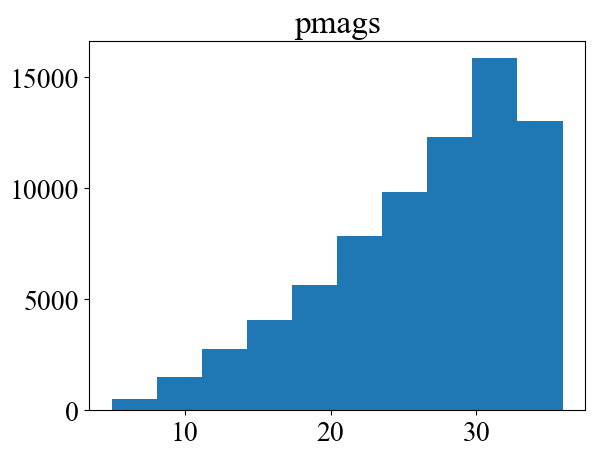

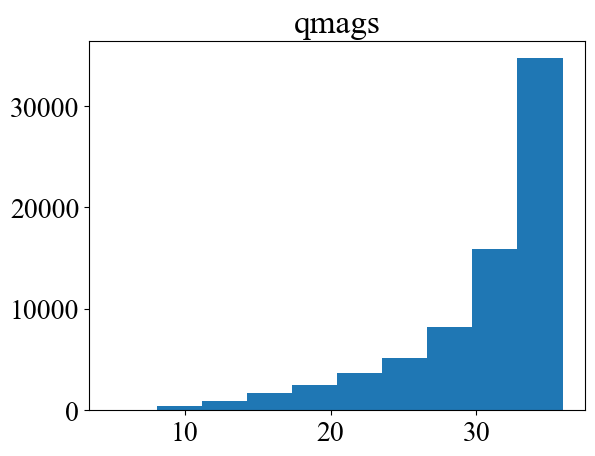

In [36]:
# Check sizes
Ks = []
Ps = []
Qs = []
for triad_tmp in triads_unique:
    kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
    pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
    qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
    Ks.append(kmag)
    Ps.append(pmag)
    Qs.append(qmag)


plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

plt.title('qmags')
plt.hist(Qs)
plt.show()


In [37]:
k_vecs_unique = np.unique(k_vecs,axis=0)
p_vecs_unique = np.unique(p_vecs,axis=0)
q_vecs_unique = np.unique(q_vecs,axis=0)

In [39]:
# plt.figure()
# plt.title('k_vecs')
# for triad in k_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:orange')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('p_vecs')
# for triad in p_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:blue')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

# plt.figure()
# plt.title('q_vecs')
# for triad in q_vecs_unique:
#     plt.scatter(triad[0],triad[1],color='tab:green')
# plt.grid()
# plt.gca().set_aspect(1)
# plt.show()

Now we apply scaling and creat a new list

In [40]:
mult = 4#16
n = 256*mult
Ntriads = 100000
kf = 9*mult
kup = kf+1
kdn = kf-1

#############################
kmax = kf #n/3
kmax_int = np.int32(np.floor(kmax))

triads_full = []
as_full = []
count = 1
for triad in triads_unique[:,:]:
    # The limiting factor will be q, so we first define this
    [qx,qy]=[-triad[0]-triad[2],-triad[1]-triad[3]]
    qmax = np.max([np.abs(qx),np.abs(qy)])
    nums = int(np.floor(kmax/qmax))
    for ii in range(1,nums+1):
        triad_tmp = triad*(ii)
        kmag = np.sqrt(triad_tmp[0]**2 + triad_tmp[1]**2)
        pmag = np.sqrt(triad_tmp[2]**2 + triad_tmp[3]**2)
        qmag = np.sqrt((triad_tmp[0]+triad_tmp[2])**2 + (triad_tmp[1]+triad_tmp[3])**2)
        if (kmag>kmax) or (pmag>kmax) or (qmag>kmax):
            # print("TRIAD IS LARGER THAN KMAX. SKIPPING.")
            # print(triad_tmp, 2**(ii))
            continue
        else:
            triads_full.append(triad*(ii))
            as_full.append(ii)
    # print('-------------')
    # print(qmax)
    # print(nums)
    # print('kx',[kx*2**(ii) for ii in range(nums)])
    # print('ky',[ky*2**(ii) for ii in range(nums)])
    # print('px',[px*2**(ii) for ii in range(nums)])
    # print('py',[py*2**(ii) for ii in range(nums)])
    # print('qx',[qx*2**(ii) for ii in range(nums)])
    # print('qy',[qy*2**(ii) for ii in range(nums)])

triads_full = np.array(triads_full)
as_full = np.array(as_full)


In [41]:
print(triads_unique.shape)

(73292, 4)


In [42]:
print(triads_full.shape)
print(np.max(as_full),np.argmax(as_full))

(77516, 4)
7 7821


[1. 2. 3. 4. 5. 6. 7.] [73292  3506   592   105    18     2     1]


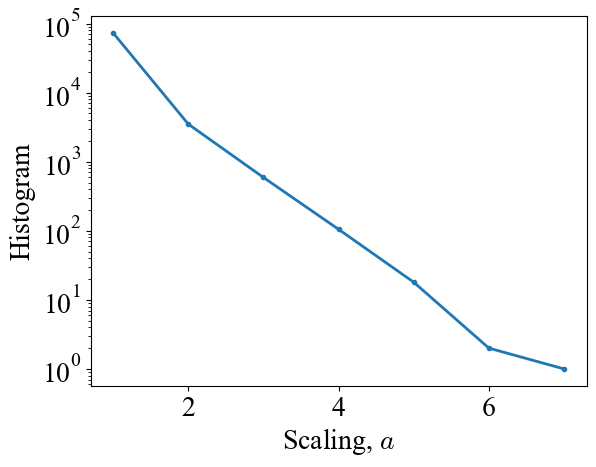

In [43]:
# Histogram
# q = k_vecs[:,0]
q = as_full
d = np.diff(np.unique(q)).min()
left_of_first_bin = q.min() - float(d)/2
right_of_last_bin = q.max() + float(d)/2
# n, bins, patches = axs[jj,1].hist(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),histtype='step',log=True,density=True,lw=2,
#         color=cm.copper(cscale_qins(q_in/Ny,q_ins_Ny[2:5])))
nn, bins = np.histogram(q, bins=np.arange(left_of_first_bin, right_of_last_bin + d, d),density=False)
bins_c = (np.diff(bins)/2+bins[:-1])
# nn[nn==0]=np.nan
print(bins_c[nn!=0],nn[nn!=0])
plt.semilogy(bins_c[nn!=0],nn[nn!=0],'.-',lw=2,)
# plt.ylim(0,np.max(nn)*1.1)
# plt.xlim(0,10)
plt.ylabel('Histogram')
plt.xlabel('Scaling, $a$')
plt.show()

In [62]:
np.savetxt('triads_full_%i_full.txt' % n, triads_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

In [63]:
np.savetxt('as_full_%i_full.txt' % n, as_full, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

### Picking 12 for time-series sampling

100%|██████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 3081.78it/s]
/tmp/ipykernel_1207748/3206224998.py:162: RuntimeWarning: invalid value encountered in sqrt
  solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
/tmp/ipykernel_1207748/3206224998.py:163: RuntimeWarning: invalid value encountered in sqrt
  soln = (-b - np.sqrt(b**2 -4*a*c))/2/a


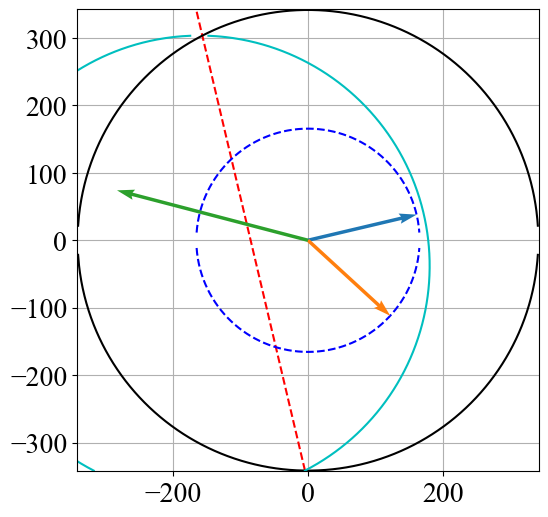

In [159]:
n = 1024
N_shells = 6 # Based on the number of shells we're interested in sampling (will look at 2 random triads per shell)
kmax = n/3
Kbins = np.logspace(np.log10(6),np.log10(kmax),N_shells)
kmax_int = np.int32(np.floor(kmax))
P_lim = kmax

k_vecs = []
p_vecs = []
q_vecs = []
Ks = []
Ps = []
ratio1 = []
ratio2 = []
term = []

count = 0
count_wrong_1 = 0
count_wrong_2 = 0
count_wrong_3 = 0
count_wrong_4 = 0
count_wrong_5 = 0
for shell in tqdm.tqdm(range(N_shells)):
    ntriad = 0
    while ntriad<2:
        count+=1
        ##################
        ## Choose k vector
        # Random theta
        theta_k = np.random.uniform(low=0,high=1)*np.pi/2  # theta_k = np.arctan(kx/ky), theta between -pi/2 and pi/2. Choosing this range so that kx > 0, which is the case for us.
        # Random magnitude
        # Choose bounds so that we can find various scalings. We want to _at least_ have factors of 8 for all triads. This means K_lim = P_lim = int(round(kmax/8)).
        K_lim = np.min([kmax,Kbins[shell]])
        if shell>0:
            # K_min = np.max([0.5,Kbins[shell-1]]) # for phase
            K_min = np.max([5,Kbins[shell-1]])
        else:
            K_min = 5
        # mag_k = np.random.randint(K_min,K_lim)
        mag_k = np.random.uniform(K_min,K_lim) # So at least one shell is represented for the last K
        kx = np.round(mag_k*np.cos(theta_k))  # kx
        ky = np.round(mag_k*np.sin(theta_k)) # ky
        kmag = np.sqrt(kx**2 + ky**2)
        
        ##################
        ## Choose a random vector p, such that: (1) K<P, (2) P<Q, (3) P < min(K + P_max,kmax), and (4) Q < kmax
        ########
        rad_lim = np.min([kmax,P_lim])
        # Choose a random radius between kmag and rad_lim
        mag_p = np.random.uniform(low=kmag+0.5,high=rad_lim)
        # Intersection of P < Q line and mag_p circle
        theta_PQ_pos = + (np.pi - np.arccos(kmag/(2*mag_p)))
        theta_PQ_neg = - (np.pi - np.arccos(kmag/(2*mag_p)))
        if (kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2))<=1: # Possible thetas will be separated
            # Intersection of Q < kmax curve and mag_p circle
            theta_kmax_pos = np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            theta_kmax_neg = -np.arccos((kmax**2-mag_p**2-(kx**2+ky**2))/(2*mag_p*np.sqrt(kx**2+ky**2)))
            pos = np.random.randint(0,high = 2) # Choose a branch
            if pos==0: # neg
                low = theta_PQ_neg
                high = theta_kmax_neg
            else: # pos
                low=theta_kmax_pos
                high=theta_PQ_pos
        else:
            low=theta_PQ_neg
            high=theta_PQ_pos
        # theta_p = np.random.uniform(low=low+angle_res,high=high-angle_res) + np.angle(kx+1j*ky)
        theta_p = np.random.uniform(low=low,high=high) + np.angle(kx+1j*ky)
        px = np.round(mag_p*np.cos(theta_p))  # px
        py = np.round(mag_p*np.sin(theta_p)) # py
        
        ####### Check and correct for discreteness effects
        # count_e = 1
        # good = False
        # while not good:
        #     px,py,good = fix_vec(px,py,kmag,rad_lim,low,high,count=count_e,test=False)
        #     count_e += 1
        pmag = np.sqrt(px**2+py**2)
        # Finally, find qx,qy
        qx = -kx -px
        qy = -ky -py
        qmag = np.sqrt(qx**2 + qy**2)
    
        cross = (kx*py)-(ky*px)
        if cross==0:
            count_wrong_1 += 1
            # print('------cross = 0')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
    
        if qmag>=(n/3):
            count_wrong_2 += 1
            print('---- (qx,qy) is outside the dealiased grid! ----')
            continue
    
        if pmag>=(n/3):
            count_wrong_3 += 1
            # print('---- (px,py) is outside the dealiased grid! ----')
            continue
        
        if qmag<pmag:
            count_wrong_4+=1
            # print('------qmag<pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue
        
        if kmag>=pmag:
            count_wrong_5 += 1
            # print('------ kmag = pmag')
            # print('kx',kx,'ky',ky,'px',px,'py',py)
            continue

        Ks.append(kmag)
        Ps.append(pmag) 
        k_vecs.append([kx,ky])
        p_vecs.append([px,py])
        q_vecs.append([qx,qy])
        ntriad += 1
    
# if count_wrong>0:
# if (Ntr%(Ntriads/25)==0) or (Ntr<4):
if 1:
    kt = np.arange(-kmax_int,kmax_int)
    kt_edges = np.concatenate([[kt[0]-0.5],kt+0.5])
    # kt = np.linspace(-kmax,kmax,200)
    KTX,KTY = np.meshgrid(kt,kt,indexing='ij')
    KTX_edges,KTY_edges = np.meshgrid(kt_edges,kt_edges,indexing='ij')
    cond1 = ((KTX**2 + KTY**2) > kmag**2)
    if kx==0:
        if ky>0:
            cond2 = (KTY > -ky/2)
        else:
            cond2 = (KTY < -ky/2)
    else:
        cond2 = (KTX>(-(ky/kx)*KTY - kx/2 - ky**2/(2*kx)))
    cond3 = ((KTX**2 + KTY**2) < (rad_lim)**2)
    QX = -kx - KTX
    QY = -ky - KTY
    # cond4 = (np.abs(QX)<kmax)&(np.abs(QY)<kmax)
    cond4 = ((QX**2 + QY**2) < kmax**2)
    plt.figure(figsize=(8,6))
    plt.pcolor(KTX_edges,KTY_edges,(cond1&cond2&cond3&cond4),vmin=0,vmax=1,cmap='binary')
    xplt = np.linspace(-kmax,kmax,1000)
    if kx == 0:
            plt.axhline(y = -ky/2)
    else:
        plt.plot(-(ky/kx)*xplt - kx/2 - ky**2/(2*kx),xplt,'--r')
    plt.plot(xplt[np.abs(xplt)<kmag], np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmag], -np.sqrt(kmag**2-xplt[np.abs(xplt)<kmag]**2),'--b')
    plt.plot(xplt[np.abs(xplt)<kmax], np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    plt.plot(xplt[np.abs(xplt)<kmax], -np.sqrt(kmax**2-xplt[np.abs(xplt)<kmax]**2),'-k')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.plot(xplt[np.abs(xplt)<(rad_lim)], -np.sqrt((kmag+P_max)**2-xplt[np.abs(xplt)<(rad_lim)]**2),'--g')
    # plt.axvline(x = -kmax-kx,ls='-',c='c')
    # plt.axvline(x = kmax-kx,ls='-',c='c')
    # plt.axhline(y = kmax-ky,ls='-',c='c')
    # plt.axhline(y = -kmax-ky,ls='-',c='c')
    a = 1
    b = 2*kx
    c = kx**2 + xplt**2 + 2*xplt*ky + ky**2 - kmax**2
    solp = (-b + np.sqrt(b**2 -4*a*c))/2/a
    soln = (-b - np.sqrt(b**2 -4*a*c))/2/a
    plt.plot(solp,xplt,'-c')
    plt.plot(soln,xplt,'-c')
    # plt.axhline(y = minp+1,ls='--',c='y')
    # plt.axhline(y = maxp-1,ls='--',c='y')
    # plt.axvline(x = minp2+1,ls='--',c='orange')
    # plt.axvline(x = maxp2,ls='--',c='orange')
    # plt.axhline(y=kmag*np.sin(np.arccos(kmax**2/(2*kmag**2) -1) + np.angle(kx+1j*ky)),c='r')
    V = np.array([[kx,ky],[px,py],[qx,qy]])
    origin = np.array([[0,0,0],[0,0,0]]) # origin point
    plt.quiver(*origin, V[:,0], V[:,1], color=['tab:blue','tab:orange','tab:green'], angles='xy', scale_units='xy', scale=1,zorder=10)
    plt.grid()
    plt.gca().set_aspect(1)
    plt.xlim(-kmax-1,kmax+1)
    plt.ylim(-kmax-1,kmax+1)
    # plt.xlim(px-5,px+5)
    # plt.ylim(py-5,py+5)
    plt.show()    

In [160]:
k_vecs = np.array(k_vecs)
p_vecs = np.array(p_vecs)

In [161]:
Ks

[np.float64(6.324555320336759),
 np.float64(5.0990195135927845),
 np.float64(8.06225774829855),
 np.float64(10.770329614269007),
 np.float64(27.586228448267445),
 np.float64(28.231188426986208),
 np.float64(50.60632371551998),
 np.float64(31.622776601683793),
 np.float64(72.71863585079137),
 np.float64(82.34682750416071),
 np.float64(199.06029237394384),
 np.float64(165.42369842317032)]

In [162]:
k_vecs.shape

(12, 2)

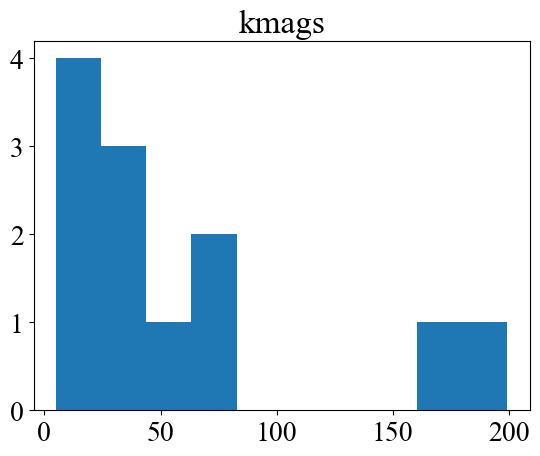

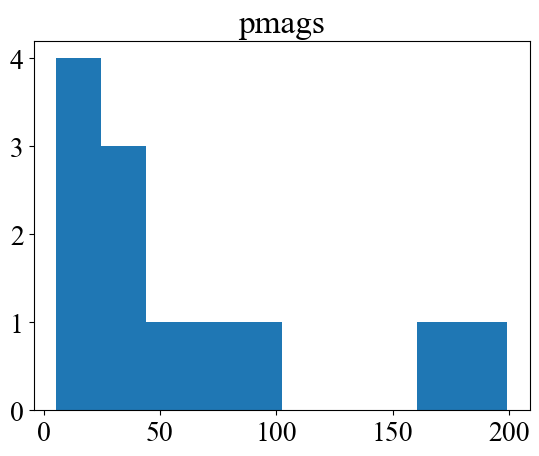

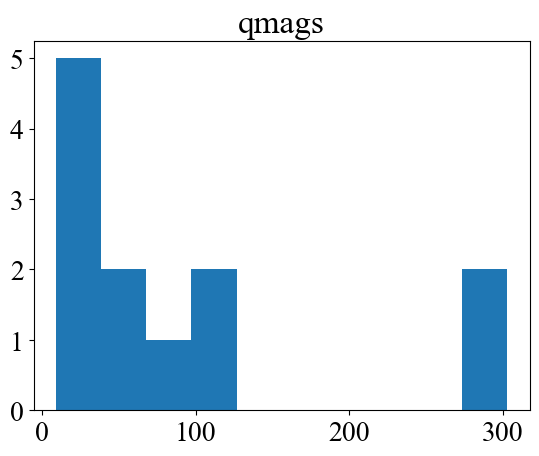

In [163]:
# Check sizes
plt.title('kmags')
plt.hist(Ks)
plt.show()

plt.title('pmags')
plt.hist(Ps)
plt.show()

Qs = []
cross = []
for ii in range(len(Ps)):
    [qx,qy] = [-k_vecs[ii,0]-p_vecs[ii,0],-k_vecs[ii,1]-p_vecs[ii,1]]
    qmag = np.sqrt(qx**2+qy**2)
    cross.append(qx*p_vecs[ii,1] - qy*p_vecs[ii,0])
    Qs.append(qmag)

plt.title('qmags')
plt.hist(Qs)
plt.show()

Create a unique list of triads 
Because many are likely duplicated

In [164]:
triads_combined = np.hstack([k_vecs,p_vecs])
print(triads_combined.shape)

(12, 4)


In [165]:
triads_unique = np.unique(triads_combined,axis=0)
print(triads_unique.shape)

(12, 4)


In [166]:
triads_unique

array([[   1.,    5.,    5.,    2.],
       [   1.,    8.,    3.,    8.],
       [   4.,   10.,   10.,    5.],
       [   6.,    2.,    0.,    7.],
       [  11.,   26.,   29.,   -1.],
       [  19.,   20.,  -25.,   12.],
       [  26.,   18.,   26.,   19.],
       [  38.,   62.,   66.,  -32.],
       [  40.,   31.,  -34.,   38.],
       [  75.,   34.,   13.,  -82.],
       [ 161.,   38.,  122., -112.],
       [ 195.,   40.,   -9.,  199.]])

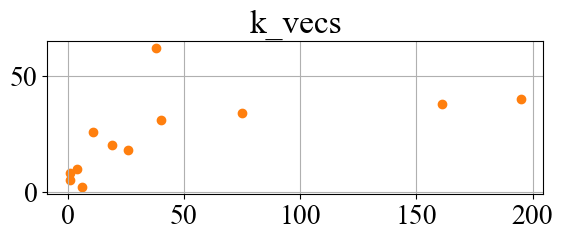

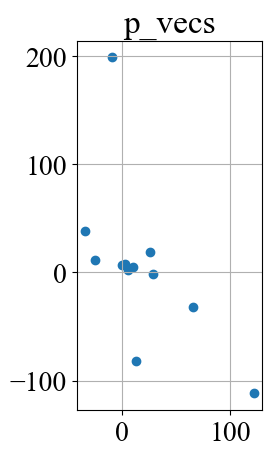

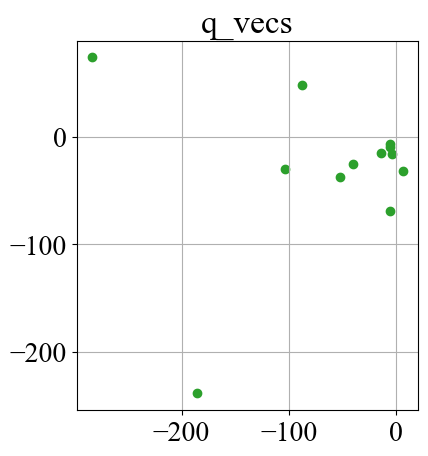

In [167]:
plt.figure()
plt.title('k_vecs')
for triad in triads_unique:
    plt.scatter(triad[0],triad[1],color='tab:orange')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('p_vecs')
for triad in triads_unique:
    plt.scatter(triad[2],triad[3],color='tab:blue')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

plt.figure()
plt.title('q_vecs')
for triad in triads_unique:
    plt.scatter(-triad[0]-triad[2],-triad[1]-triad[3],color='tab:green')
plt.grid()
plt.gca().set_aspect(1)
plt.show()

In [168]:
# np.savetxt('triads_ts_%i_phase.txt' % n, triads_unique, fmt='%5i', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)